In [1]:
# ============================================
# CELL 1: SETUP - ÉCONOMIE & MANAGEMENT BAC PREDICTOR
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
import shap
import warnings
warnings.filterwarnings('ignore')

# Set style for professional visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("=" * 60)
print("📈 ÉCONOMIE & MANAGEMENT BAC PREDICTION SYSTEM")
print("=" * 60)
print(f"✅ Libraries loaded successfully")
print(f"📊 Matplotlib version: {plt.matplotlib.__version__}")
print(f"🔧 Seaborn version: {sns.__version__}")
print(f"🤖 Scikit-learn imported successfully")
print(f"🟡 SHAP version: {shap.__version__}")
print("=" * 60)
print("📖 Based on BAC 2025 Économie & Management exam - Gestion stream")
print("🎯 Target: Predict BAC score /20")
print("⏱️ Duration: 3h30")
print("📊 Chapters: Market Mechanisms (0.55), Money & Banking (0.50), Unemployment (0.50), Inflation (0.50)")
print("🏢 Management: Communication (0.45), Control (0.45), Leadership (0.40), Financing (0.50)")
print("🔑 Situation analysis is the most important skill (0.60)")
print("🧘 Psychological factors have LOW impact (Gestion students are chill!)")
print("=" * 60)
print("\n✅ Cell 1 complete. Ready for Cell 2 (Dataset Generation)")

📈 ÉCONOMIE & MANAGEMENT BAC PREDICTION SYSTEM
✅ Libraries loaded successfully
📊 Matplotlib version: 3.10.6
🔧 Seaborn version: 0.13.2
🤖 Scikit-learn imported successfully
🟡 SHAP version: 0.51.0
📖 Based on BAC 2025 Économie & Management exam - Gestion stream
🎯 Target: Predict BAC score /20
⏱️ Duration: 3h30
📊 Chapters: Market Mechanisms (0.55), Money & Banking (0.50), Unemployment (0.50), Inflation (0.50)
🏢 Management: Communication (0.45), Control (0.45), Leadership (0.40), Financing (0.50)
🔑 Situation analysis is the most important skill (0.60)
🧘 Psychological factors have LOW impact (Gestion students are chill!)

✅ Cell 1 complete. Ready for Cell 2 (Dataset Generation)


In [2]:
# ============================================
# CELL 2: DATASET GENERATION - ÉCONOMIE & MANAGEMENT BAC
# Gestion stream - Psychological factors have LOW impact
# ============================================

import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 500

print("=" * 60)
print("GENERATING ÉCONOMIE & MANAGEMENT BAC DATASET")
print("Target: Mean ~13.2, Fail ~10%, Excellent ~15%")
print("Psychological factors: LOW impact (Gestion students are chill!)")
print("=" * 60)

# ============================================
# STEP 1: Generate BAC Score Distribution
# ============================================

bac_scores = []
n_fail = int(n_students * 0.10)
failing = np.random.uniform(6, 9.9, n_fail)
bac_scores.extend(failing)

n_excellent = int(n_students * 0.15)
excellent = np.random.uniform(17, 20, n_excellent)
bac_scores.extend(excellent)

n_avg = n_students - n_fail - n_excellent
average = np.random.normal(13.5, 1.5, n_avg)
average = np.clip(average, 10, 16.9)
bac_scores.extend(average)

bac_scores = np.array(bac_scores)
np.random.shuffle(bac_scores)
bac_scores = np.round(bac_scores, 1)

bac_mean = bac_scores.mean()
bac_std = bac_scores.std()
bac_scaled = (bac_scores - bac_mean) / bac_std

print(f"\n📊 BAC Score Distribution:")
print(f"   Mean: {bac_mean:.2f}")
print(f"   Std: {bac_std:.2f}")
print(f"   Fail (<10): {(bac_scores < 10).sum()} ({(bac_scores < 10).sum()/n_students*100:.1f}%)")
print(f"   Excellent (17-20): {(bac_scores >= 17).sum()} ({(bac_scores >= 17).sum()/n_students*100:.1f}%)")

# ============================================
# Function to generate feature with exact correlation
# ============================================

def generate_feature(bac_scaled, target_corr, target_mean, target_std):
    signal = target_corr * bac_scaled * target_std
    noise_std = target_std * np.sqrt(max(0.01, 1 - target_corr**2))
    noise = np.random.normal(0, noise_std, n_students)
    feature = target_mean + signal + noise
    return feature

# ============================================
# STEP 2: Academic History
# ============================================

eco_avg_grade = generate_feature(bac_scaled, 0.70, 13.0, 2.2)
eco_avg_grade = np.clip(eco_avg_grade, 8, 19.5).round(1)

eco_grade_t3 = eco_avg_grade + np.random.normal(0.3, 0.8, n_students)
eco_grade_t3 = np.clip(eco_grade_t3, 8, 19.5).round(1)

eco_grade_t2 = eco_avg_grade + np.random.normal(0, 0.9, n_students)
eco_grade_t2 = np.clip(eco_grade_t2, 8, 19.5).round(1)

eco_grade_t1 = eco_avg_grade - np.random.normal(0.5, 1.0, n_students)
eco_grade_t1 = np.clip(eco_grade_t1, 8, 19.5).round(1)

eco_trend = eco_grade_t3 - eco_grade_t1

print(f"\n📊 Academic History Generated")

# ============================================
# STEP 3: Economics Chapters (0-10 scale)
# ============================================

# Market Mechanisms (supply/demand, equilibrium, surplus)
market_mechanisms = generate_feature(bac_scaled, 0.55, 6.3, 1.6)
market_mechanisms = np.clip(market_mechanisms, 2, 10).round(1)

# Money & Banking (money functions, barter, banking system)
money_banking = generate_feature(bac_scaled, 0.50, 6.0, 1.7)
money_banking = np.clip(money_banking, 2, 10).round(1)

# Unemployment (types, causes, effects, solutions)
unemployment = generate_feature(bac_scaled, 0.50, 6.0, 1.7)
unemployment = np.clip(unemployment, 2, 10).round(1)

# Inflation (types, causes, effects)
inflation = generate_feature(bac_scaled, 0.50, 6.0, 1.7)
inflation = np.clip(inflation, 2, 10).round(1)

# International Trade (exchange rate, balance of payments, WTO)
international_trade = generate_feature(bac_scaled, 0.45, 5.8, 1.8)
international_trade = np.clip(international_trade, 2, 10).round(1)

# Financing (internal/external, short/long term)
financing = generate_feature(bac_scaled, 0.50, 6.0, 1.7)
financing = np.clip(financing, 2, 10).round(1)

print(f"\n📊 Economics Chapters Generated:")
print(f"   market_mechanisms: {np.corrcoef(bac_scores, market_mechanisms)[0,1]:.3f} (target: 0.55)")
print(f"   money_banking: {np.corrcoef(bac_scores, money_banking)[0,1]:.3f} (target: 0.50)")
print(f"   unemployment: {np.corrcoef(bac_scores, unemployment)[0,1]:.3f} (target: 0.50)")
print(f"   inflation: {np.corrcoef(bac_scores, inflation)[0,1]:.3f} (target: 0.50)")

# ============================================
# STEP 4: Management Chapters (0-10 scale)
# ============================================

# Communication (types, formal/informal, vertical/horizontal)
communication = generate_feature(bac_scaled, 0.45, 5.8, 1.8)
communication = np.clip(communication, 2, 10).round(1)

# Control (definition, steps, deviation analysis)
control = generate_feature(bac_scaled, 0.45, 5.8, 1.8)
control = np.clip(control, 2, 10).round(1)

# Leadership & Motivation (styles, motivation theories)
leadership_motivation = generate_feature(bac_scaled, 0.40, 5.5, 1.9)
leadership_motivation = np.clip(leadership_motivation, 2, 10).round(1)

print(f"\n📊 Management Chapters Generated:")
print(f"   communication: {np.corrcoef(bac_scores, communication)[0,1]:.3f} (target: 0.45)")
print(f"   control: {np.corrcoef(bac_scores, control)[0,1]:.3f} (target: 0.45)")
print(f"   leadership_motivation: {np.corrcoef(bac_scores, leadership_motivation)[0,1]:.3f} (target: 0.40)")

# ============================================
# STEP 5: Economic Skills (MOST IMPORTANT)
# ============================================

# Situation Analysis (applying concepts to real situations) - HIGHEST
situation_analysis = generate_feature(bac_scaled, 0.60, 6.5, 1.5)
situation_analysis = np.clip(situation_analysis, 2, 10).round(1)

# Graph Interpretation (supply/demand curves, equilibrium)
graph_interpretation = generate_feature(bac_scaled, 0.55, 6.3, 1.6)
graph_interpretation = np.clip(graph_interpretation, 2, 10).round(1)

# Calculation Accuracy (surplus, elasticity)
calculation_accuracy = generate_feature(bac_scaled, 0.50, 6.0, 1.7)
calculation_accuracy = np.clip(calculation_accuracy, 2, 10).round(1)

# Structured Answer (clear, organized responses)
structured_answer = generate_feature(bac_scaled, 0.45, 5.8, 1.8)
structured_answer = np.clip(structured_answer, 2, 10).round(1)

print(f"\n📊 Economic Skills Generated:")
print(f"   situation_analysis: {np.corrcoef(bac_scores, situation_analysis)[0,1]:.3f} (target: 0.60) - MOST IMPORTANT!")
print(f"   graph_interpretation: {np.corrcoef(bac_scores, graph_interpretation)[0,1]:.3f} (target: 0.55)")
print(f"   calculation_accuracy: {np.corrcoef(bac_scores, calculation_accuracy)[0,1]:.3f} (target: 0.50)")

# ============================================
# STEP 6: Practice & Preparation
# ============================================

bac_exams_practiced_raw = generate_feature(bac_scaled, 0.40, 8, 5)
bac_exams_practiced = np.clip(bac_exams_practiced_raw, 0, 30).round(0).astype(int)

situation_exercises_raw = generate_feature(bac_scaled, 0.40, 6, 3)
situation_exercises = np.clip(situation_exercises_raw, 0, 15).round(0).astype(int)

print(f"\n📊 Practice Generated:")
print(f"   bac_exams_practiced: {np.corrcoef(bac_scores, bac_exams_practiced)[0,1]:.3f} (target: 0.40)")
print(f"   situation_exercises: {np.corrcoef(bac_scores, situation_exercises)[0,1]:.3f} (target: 0.40)")

# ============================================
# STEP 7: Study Behavior
# ============================================

study_hours = generate_feature(bac_scaled, 0.30, 5, 2)
study_hours = np.clip(study_hours, 2, 12).round(1)

consistency = generate_feature(bac_scaled, 0.30, 6, 2)
consistency = np.clip(consistency, 2, 10).round(1)

print(f"\n📊 Study Behavior Generated")

# ============================================
# STEP 8: Psychological Factors (LOW IMPACT)
# ============================================

eco_anxiety = generate_feature(bac_scaled, -0.12, 5.0, 2.0)
eco_anxiety = np.clip(eco_anxiety, 2, 10).round(1)

analysis_confidence = generate_feature(bac_scaled, 0.12, 6.0, 1.8)
analysis_confidence = np.clip(analysis_confidence, 2, 10).round(1)

exam_stress = generate_feature(bac_scaled, -0.10, 5.0, 2.0)
exam_stress = np.clip(exam_stress, 2, 10).round(1)

print(f"\n📊 Psychological Factors (LOW impact):")
print(f"   eco_anxiety: {np.corrcoef(bac_scores, eco_anxiety)[0,1]:.3f} (target: -0.12)")
print(f"   analysis_confidence: {np.corrcoef(bac_scores, analysis_confidence)[0,1]:.3f} (target: 0.12)")

# ============================================
# STEP 9: Derived Features
# ============================================

# Economics composite
economics_composite = (market_mechanisms + money_banking + unemployment + inflation + international_trade + financing) / 6
economics_composite = economics_composite.round(1)

# Management composite
management_composite = (communication + control + leadership_motivation) / 3
management_composite = management_composite.round(1)

# Economic skills composite
economic_skills_composite = (situation_analysis + graph_interpretation + calculation_accuracy + structured_answer) / 4
economic_skills_composite = economic_skills_composite.round(1)

# Practice intensity
practice_intensity = (bac_exams_practiced / 30 * 10 + situation_exercises / 15 * 10) / 2
practice_intensity = practice_intensity.round(1)

# Psychological composite (LOW impact)
psychological_composite = (analysis_confidence + (10 - eco_anxiety) + (10 - exam_stress)) / 3
psychological_composite = psychological_composite.round(1)

# Study quality
study_quality = (consistency + study_hours / 12 * 10) / 2
study_quality = study_quality.round(1)

# Imbalance score (variance between economics and management)
eco_management_blocks = np.array([economics_composite, management_composite])
imbalance_score = np.var(eco_management_blocks, axis=0).round(2)

print(f"\n📊 Derived Features Calculated")

# ============================================
# CREATE FINAL DATAFRAME
# ============================================

df = pd.DataFrame({
    # Academic History
    'eco_grade_t1': eco_grade_t1,
    'eco_grade_t2': eco_grade_t2,
    'eco_grade_t3': eco_grade_t3,
    'eco_avg_grade': eco_avg_grade,
    'eco_trend': eco_trend.round(1),
    
    # Economics Chapters
    'market_mechanisms': market_mechanisms,
    'money_banking': money_banking,
    'unemployment': unemployment,
    'inflation': inflation,
    'international_trade': international_trade,
    'financing': financing,
    
    # Management Chapters
    'communication': communication,
    'control': control,
    'leadership_motivation': leadership_motivation,
    
    # Economic Skills
    'situation_analysis': situation_analysis,
    'graph_interpretation': graph_interpretation,
    'calculation_accuracy': calculation_accuracy,
    'structured_answer': structured_answer,
    
    # Practice
    'bac_exams_practiced': bac_exams_practiced,
    'situation_exercises': situation_exercises,
    
    # Study Behavior
    'study_hours': study_hours,
    'consistency': consistency,
    
    # Psychological (LOW impact)
    'eco_anxiety': eco_anxiety,
    'analysis_confidence': analysis_confidence,
    'exam_stress': exam_stress,
    
    # Derived Features
    'economics_composite': economics_composite,
    'management_composite': management_composite,
    'economic_skills_composite': economic_skills_composite,
    'practice_intensity': practice_intensity,
    'psychological_composite': psychological_composite,
    'study_quality': study_quality,
    'imbalance_score': imbalance_score,
    
    # TARGET
    'bac_score_eco': bac_scores
})

print("\n" + "=" * 60)
print("✅ FINAL DATASET GENERATED")
print("=" * 60)
print(f"   Students: {len(df)}")
print(f"   Features: {len(df.columns)}")
print(f"   Target: bac_score_eco")

print("\n📊 VERIFICATION - ACTUAL CORRELATIONS WITH BAC SCORE:")
print("-" * 65)

key_features = [
    ('situation_analysis', 0.60),
    ('market_mechanisms', 0.55),
    ('graph_interpretation', 0.55),
    ('money_banking', 0.50),
    ('unemployment', 0.50),
    ('inflation', 0.50),
    ('financing', 0.50),
    ('calculation_accuracy', 0.50),
    ('communication', 0.45),
    ('control', 0.45),
    ('international_trade', 0.45),
    ('structured_answer', 0.45),
    ('leadership_motivation', 0.40),
    ('bac_exams_practiced', 0.40),
    ('situation_exercises', 0.40),
    ('eco_avg_grade', 0.70),
    ('eco_anxiety', -0.12),
    ('analysis_confidence', 0.12)
]

for feature, target in key_features:
    if feature in df.columns:
        actual = np.corrcoef(df['bac_score_eco'], df[feature])[0,1]
        status = "✅" if abs(actual - target) < 0.08 else "⚠️" if abs(actual - target) < 0.12 else "❌"
        print(f"   {feature:<30} actual: {actual:>6.3f} target: {target:>5.2f} {status}")

print("\n📊 FINAL BAC SCORE DISTRIBUTION:")
print(f"   Mean: {df['bac_score_eco'].mean():.2f}/20")
print(f"   Std: {df['bac_score_eco'].std():.2f}")
print(f"   Fail (<10): {(df['bac_score_eco'] < 10).sum()} ({(df['bac_score_eco'] < 10).sum()/n_students*100:.1f}%)")
print(f"   Excellent (17-20): {(df['bac_score_eco'] >= 17).sum()} ({(df['bac_score_eco'] >= 17).sum()/n_students*100:.1f}%)")

print("\n📊 First 10 rows preview:")
print(df[['bac_score_eco', 'situation_analysis', 'market_mechanisms', 'graph_interpretation', 'eco_anxiety']].head(10))

print("\n" + "=" * 60)
print("✅ Cell 2 complete! Ready for Cell 3")
print("=" * 60)

GENERATING ÉCONOMIE & MANAGEMENT BAC DATASET
Target: Mean ~13.2, Fail ~10%, Excellent ~15%
Psychological factors: LOW impact (Gestion students are chill!)

📊 BAC Score Distribution:
   Mean: 13.79
   Std: 2.98
   Fail (<10): 50 (10.0%)
   Excellent (17-20): 75 (15.0%)

📊 Academic History Generated

📊 Economics Chapters Generated:
   market_mechanisms: 0.526 (target: 0.55)
   money_banking: 0.525 (target: 0.50)
   unemployment: 0.477 (target: 0.50)
   inflation: 0.529 (target: 0.50)

📊 Management Chapters Generated:
   communication: 0.432 (target: 0.45)
   control: 0.482 (target: 0.45)
   leadership_motivation: 0.381 (target: 0.40)

📊 Economic Skills Generated:
   situation_analysis: 0.606 (target: 0.60) - MOST IMPORTANT!
   graph_interpretation: 0.539 (target: 0.55)
   calculation_accuracy: 0.480 (target: 0.50)

📊 Practice Generated:
   bac_exams_practiced: 0.397 (target: 0.40)
   situation_exercises: 0.434 (target: 0.40)

📊 Study Behavior Generated

📊 Psychological Factors (LOW impac

In [3]:
# ============================================
# CELL 3: SAVE DATASET
# ============================================

df.to_csv("eco_management_bac_dataset.csv", index=False)

print("✅ Dataset saved: eco_management_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score_eco'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score_eco'].min():.1f} - {df['bac_score_eco'].max():.1f}")

✅ Dataset saved: eco_management_bac_dataset.csv
📊 Shape: (500, 33)
🎯 BAC Score mean: 13.79/20
📈 BAC Score range: 6.1 - 20.0


In [2]:
# ============================================
# CELL 4: LOAD DATASET
# ============================================

df = pd.read_csv("eco_management_bac_dataset.csv")

print("✅ Dataset loaded: eco_management_bac_dataset.csv")
print(f"📊 Shape: {df.shape}")
print(f"🎯 BAC Score mean: {df['bac_score_eco'].mean():.2f}/20")
print(f"📈 BAC Score range: {df['bac_score_eco'].min():.1f} - {df['bac_score_eco'].max():.1f}")

✅ Dataset loaded: eco_management_bac_dataset.csv
📊 Shape: (500, 33)
🎯 BAC Score mean: 13.79/20
📈 BAC Score range: 6.1 - 20.0


In [3]:
# ============================================
# CELL 5: EDA - OVERVIEW
# ============================================

print("="*60)
print("📊 EXPLORATORY DATA ANALYSIS - ÉCONOMIE & MANAGEMENT BAC")
print("="*60)

print("\n1️⃣ FIRST 5 ROWS:")
print(df.head())

print("\n2️⃣ LAST 5 ROWS:")
print(df.tail())

print("\n3️⃣ DATASET INFO:")
print(df.info())

print("\n4️⃣ BASIC STATISTICS:")
print(df.describe().round(2))

print("\n5️⃣ MISSING VALUES:")
print(df.isnull().sum().sum())
print(f"✅ No missing values")

print("\n6️⃣ DATASET SHAPE:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Predictors: {df.shape[1] - 1}")
print(f"Target: 1 (bac_score_eco)")

print("\n7️⃣ DATA TYPES:")
print(df.dtypes.value_counts())

📊 EXPLORATORY DATA ANALYSIS - ÉCONOMIE & MANAGEMENT BAC

1️⃣ FIRST 5 ROWS:
   eco_grade_t1  eco_grade_t2  eco_grade_t3  eco_avg_grade  eco_trend  \
0          10.2          12.4          11.9           11.8        1.7   
1          19.1          19.5          19.5           19.0        0.4   
2          14.9          16.1          13.0           13.7       -1.9   
3          10.0           9.6          11.1           11.2        1.1   
4          16.2          13.5          13.3           14.1       -2.9   

   market_mechanisms  money_banking  unemployment  inflation  \
0                5.5           10.0           5.7        6.2   
1                7.4            7.7           6.0        8.7   
2                5.9            5.2           4.8        4.8   
3                8.5            8.5           5.0        7.5   
4                5.8            4.6           6.2        9.2   

   international_trade  financing  communication  control  \
0                  5.4        7.9       

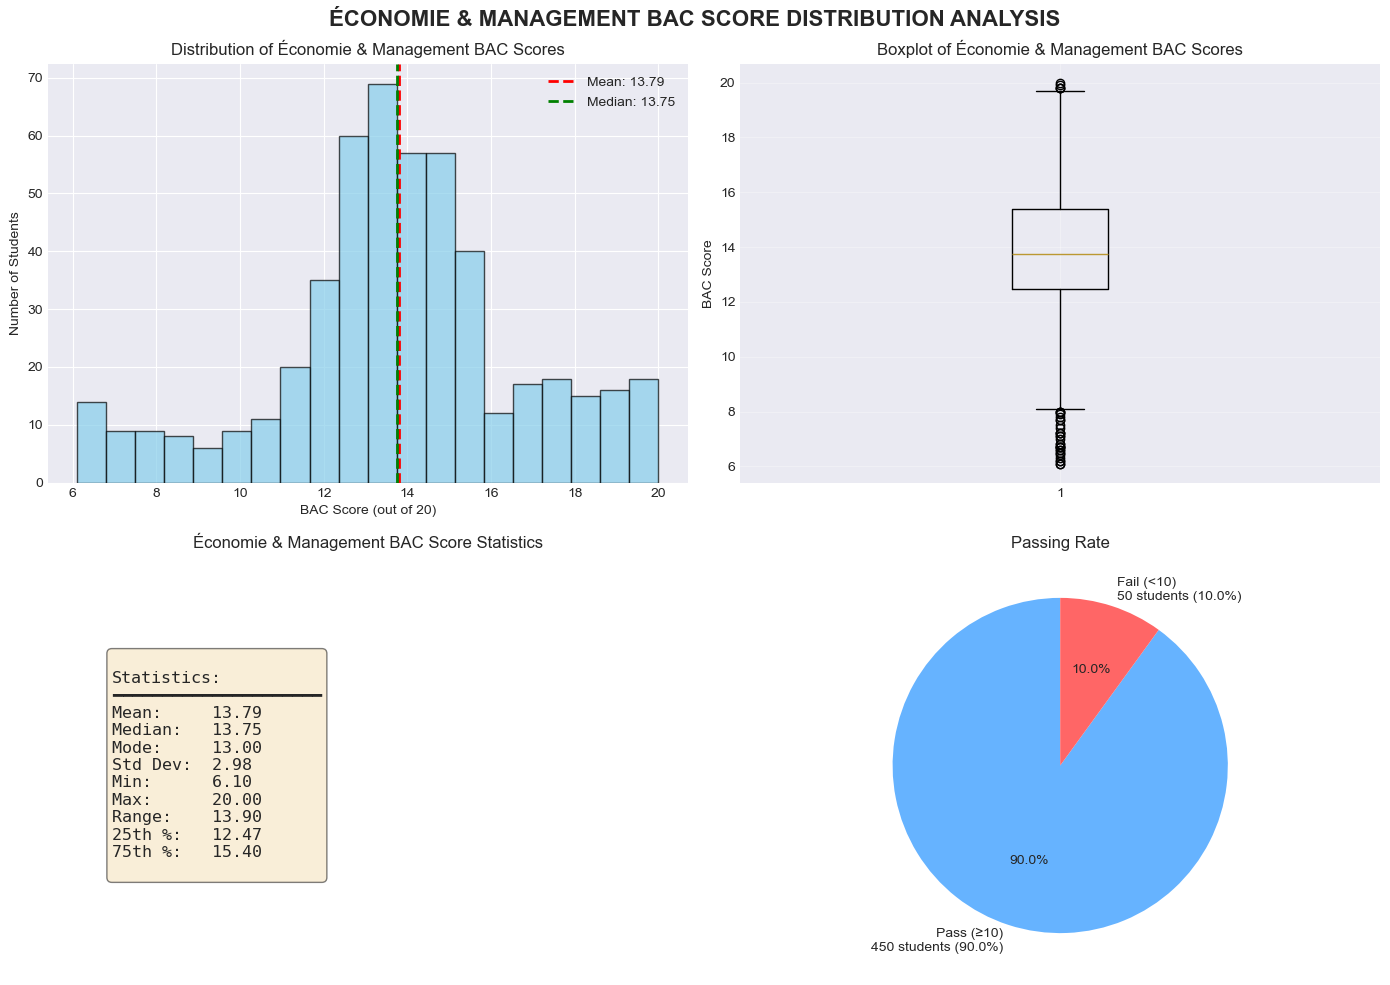


📊 ÉCONOMIE & MANAGEMENT BAC SCORE DISTRIBUTION SUMMARY
   Mean BAC Score:     13.79/20
   Median BAC Score:   13.75/20
   Standard Deviation: 2.98
   Pass Rate (≥10):    90.0% (450/500 students)
   Fail Rate (<10):    10.0% (50/500 students)


In [4]:
# ============================================
# CELL 6: EDA - BAC DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of BAC scores
axes[0,0].hist(df['bac_score_eco'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['bac_score_eco'].mean(), color='red', linestyle='dashed', linewidth=2, 
                  label=f'Mean: {df["bac_score_eco"].mean():.2f}')
axes[0,0].axvline(df['bac_score_eco'].median(), color='green', linestyle='dashed', linewidth=2, 
                  label=f'Median: {df["bac_score_eco"].median():.2f}')
axes[0,0].set_xlabel('BAC Score (out of 20)')
axes[0,0].set_ylabel('Number of Students')
axes[0,0].set_title('Distribution of Économie & Management BAC Scores')
axes[0,0].legend()

# 2. Boxplot
axes[0,1].boxplot(df['bac_score_eco'], vert=True)
axes[0,1].set_ylabel('BAC Score')
axes[0,1].set_title('Boxplot of Économie & Management BAC Scores')
axes[0,1].grid(True, alpha=0.3)

# 3. Statistics table
stats_text = f"""
Statistics:
━━━━━━━━━━━━━━━━━━━━━
Mean:     {df['bac_score_eco'].mean():.2f}
Median:   {df['bac_score_eco'].median():.2f}
Mode:     {df['bac_score_eco'].mode().iloc[0]:.2f}
Std Dev:  {df['bac_score_eco'].std():.2f}
Min:      {df['bac_score_eco'].min():.2f}
Max:      {df['bac_score_eco'].max():.2f}
Range:    {df['bac_score_eco'].max() - df['bac_score_eco'].min():.2f}
25th %:   {df['bac_score_eco'].quantile(0.25):.2f}
75th %:   {df['bac_score_eco'].quantile(0.75):.2f}
"""
axes[1,0].text(0.1, 0.5, stats_text, fontsize=12, verticalalignment='center', 
               fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1,0].axis('off')
axes[1,0].set_title('Économie & Management BAC Score Statistics')

# 4. Passing rate pie chart
passing = (df['bac_score_eco'] >= 10).sum()
failing = len(df) - passing
colors_pie = ['#66b3ff', '#ff6666']
labels = [f'Pass (≥10)\n{passing} students ({passing/len(df)*100:.1f}%)', 
          f'Fail (<10)\n{failing} students ({failing/len(df)*100:.1f}%)']
axes[1,1].pie([passing, failing], labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Passing Rate')

plt.suptitle('ÉCONOMIE & MANAGEMENT BAC SCORE DISTRIBUTION ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📊 ÉCONOMIE & MANAGEMENT BAC SCORE DISTRIBUTION SUMMARY")
print("="*60)
print(f"   Mean BAC Score:     {df['bac_score_eco'].mean():.2f}/20")
print(f"   Median BAC Score:   {df['bac_score_eco'].median():.2f}/20")
print(f"   Standard Deviation: {df['bac_score_eco'].std():.2f}")
print(f"   Pass Rate (≥10):    {passing/len(df)*100:.1f}% ({passing}/{len(df)} students)")
print(f"   Fail Rate (<10):    {failing/len(df)*100:.1f}% ({failing}/{len(df)} students)")
print("="*60)


📊 CORRELATION WITH BAC SCORE (highest to lowest):
   bac_score_eco                      : 1.000
   economics_composite                : 0.811
   economic_skills_composite          : 0.780
   eco_avg_grade                      : 0.723
   eco_grade_t3                       : 0.683
   eco_grade_t2                       : 0.674
   eco_grade_t1                       : 0.668
   management_composite               : 0.633
   situation_analysis                 : 0.606
   practice_intensity                 : 0.552
   graph_interpretation               : 0.539
   inflation                          : 0.529
   market_mechanisms                  : 0.526
   money_banking                      : 0.525
   financing                          : 0.517
   control                            : 0.482
   calculation_accuracy               : 0.480
   unemployment                       : 0.477
   international_trade                : 0.452
   structured_answer                  : 0.451
   situation_exercises       

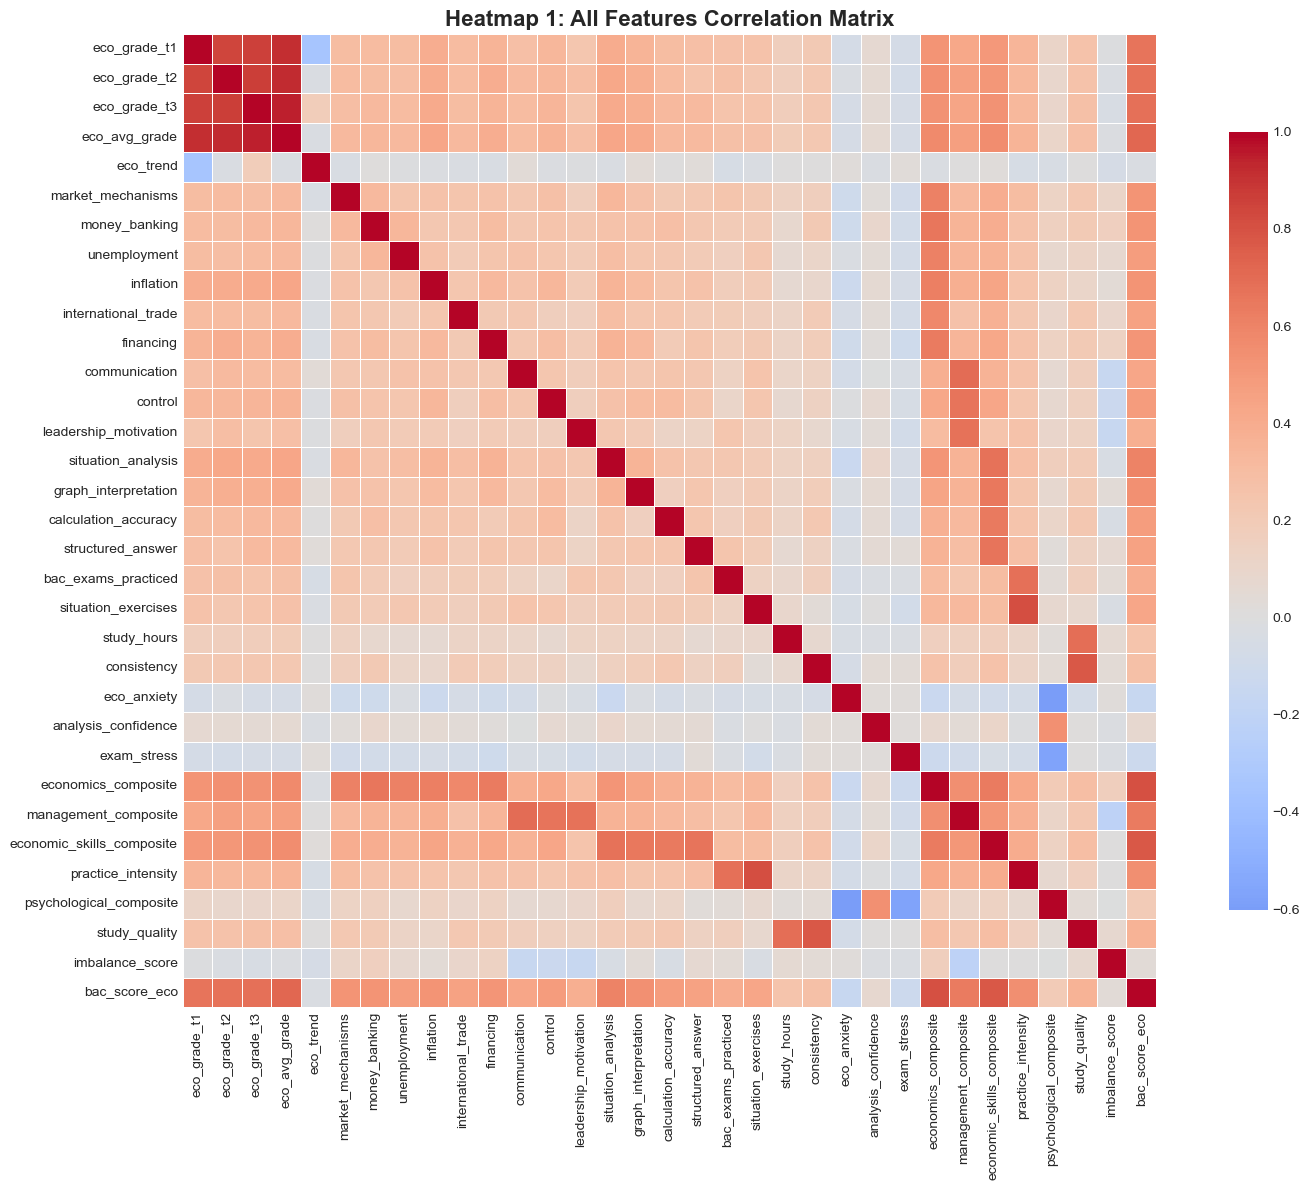


📊 HEATMAP 2: Top 15 Features Correlated with BAC Score


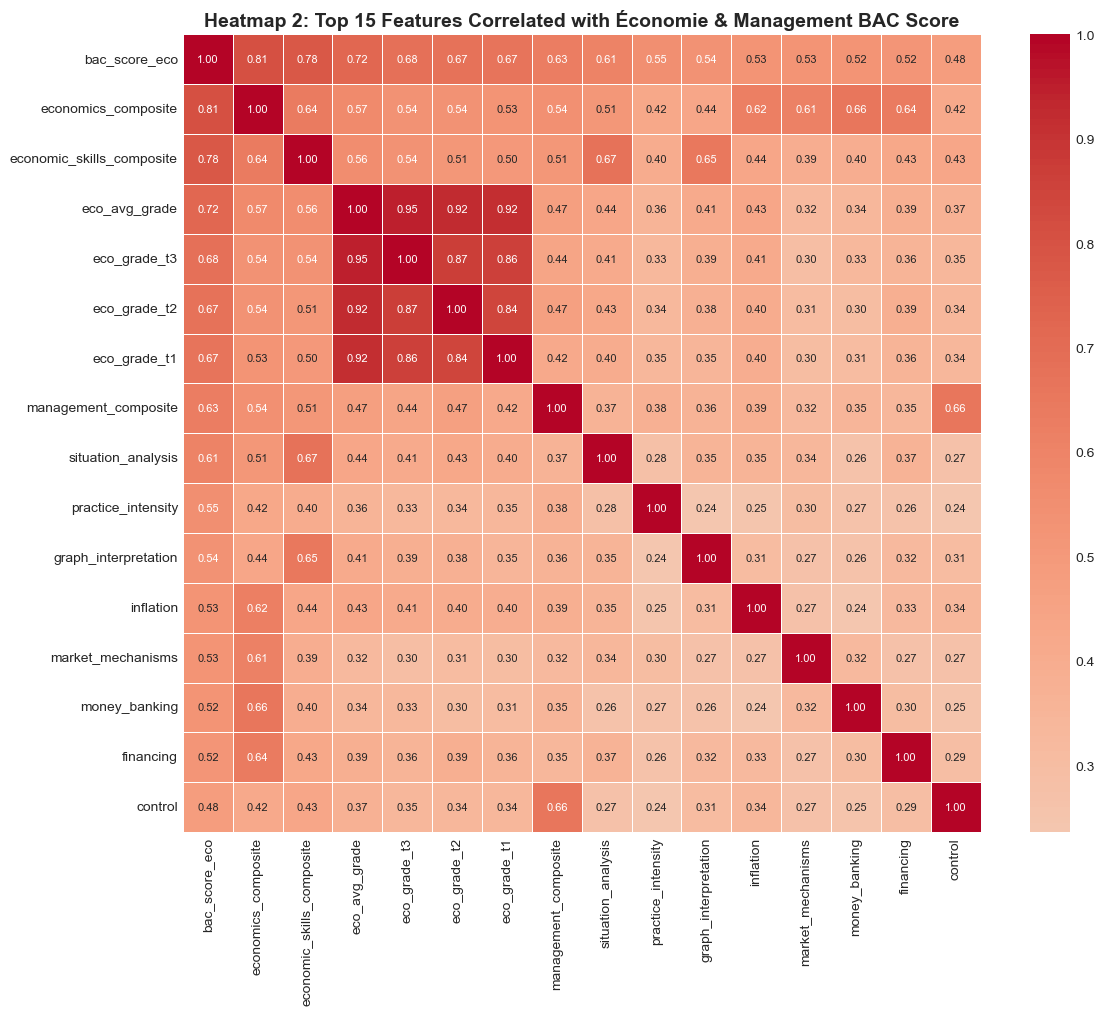


📊 HEATMAP 3: Economics Chapters Correlation


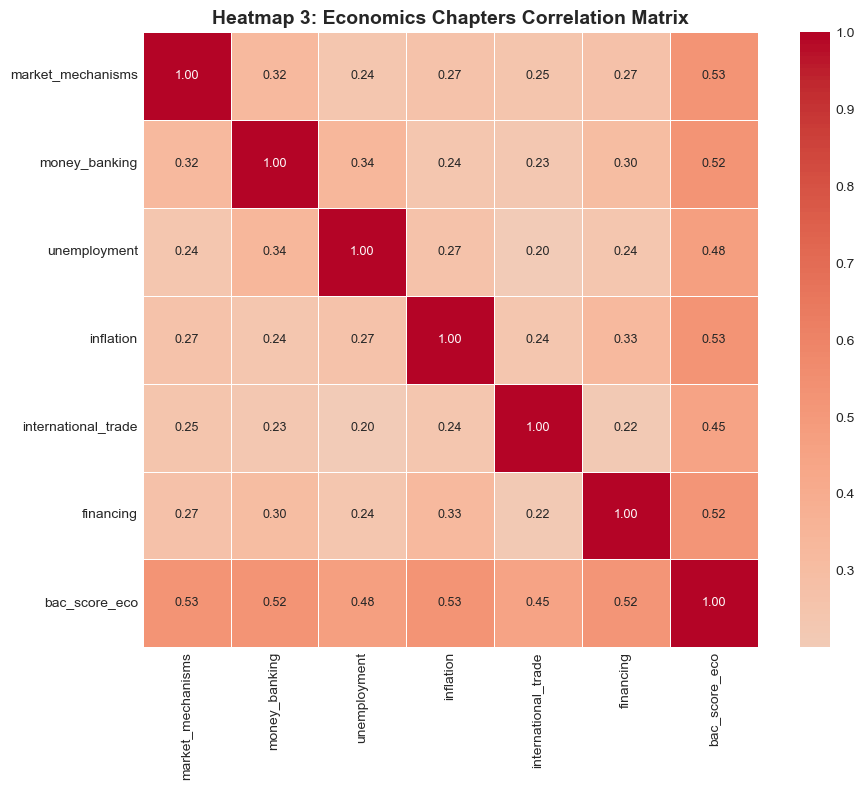


📋 Economics chapters correlation with BAC Score:
   • market_mechanisms: correlation = 0.526
   • money_banking: correlation = 0.525
   • unemployment: correlation = 0.477
   • inflation: correlation = 0.529
   • international_trade: correlation = 0.452
   • financing: correlation = 0.517

📊 HEATMAP 4: Management Chapters Correlation


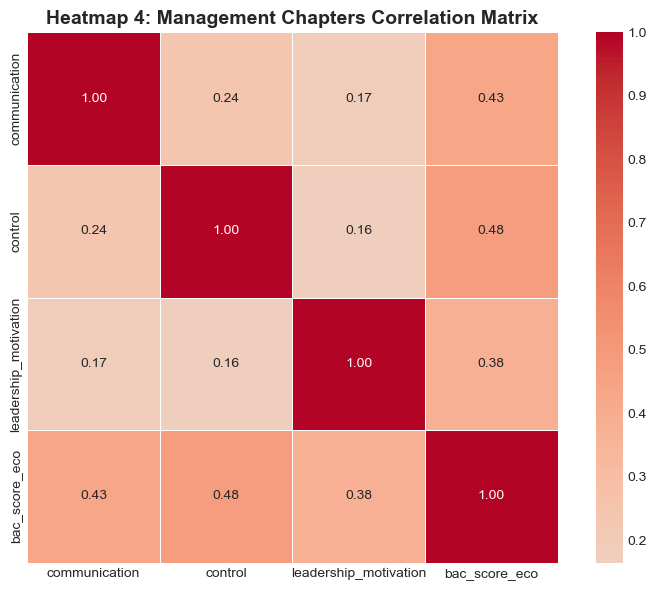


📋 Management chapters correlation with BAC Score:
   • communication: correlation = 0.432
   • control: correlation = 0.482
   • leadership_motivation: correlation = 0.381

📊 HEATMAP 5: Economic Skills Correlation


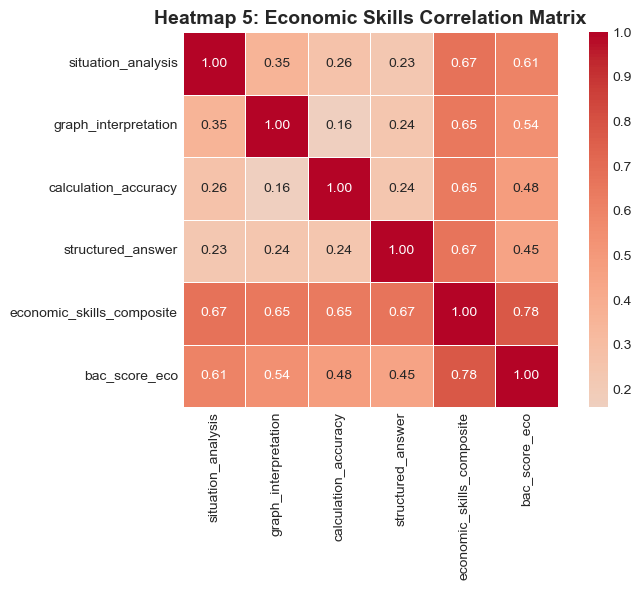


📋 Economic skills correlation with BAC Score:
   • situation_analysis: correlation = 0.606
   • graph_interpretation: correlation = 0.539
   • calculation_accuracy: correlation = 0.480
   • structured_answer: correlation = 0.451
   • economic_skills_composite: correlation = 0.780

📊 HEATMAP 6: Psychological & Practice Factors Correlation (LOW impact)


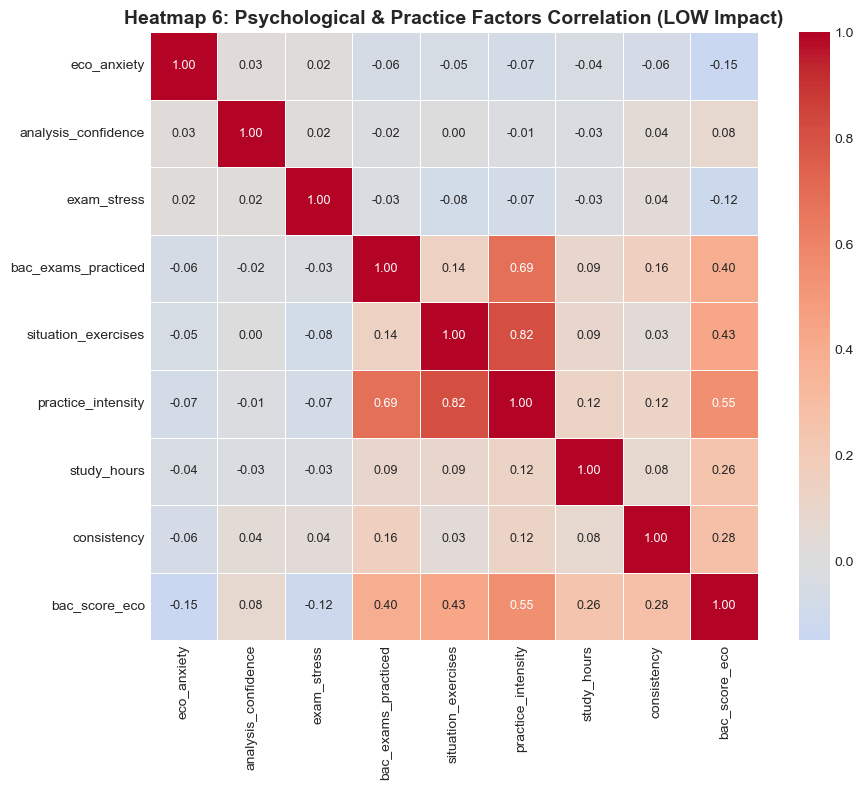


📋 Psychological & Practice factors correlation with BAC Score:
   • eco_anxiety: correlation = -0.148
   • analysis_confidence: correlation = 0.078
   • exam_stress: correlation = -0.119
   • bac_exams_practiced: correlation = 0.397
   • situation_exercises: correlation = 0.434
   • practice_intensity: correlation = 0.552
   • study_hours: correlation = 0.255
   • consistency: correlation = 0.280

✅ Correlation Analysis Complete


In [7]:
# ============================================
# CELL 7: EDA - CORRELATION HEATMAPS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Get correlation with bac_score_eco (target)
bac_corr = corr_matrix['bac_score_eco'].sort_values(ascending=False)
print("\n📊 CORRELATION WITH BAC SCORE (highest to lowest):")
print("=" * 65)
for feature, corr_value in bac_corr.items():
    print(f"   {feature:35s}: {corr_value:.3f}")

# ============================================
# HEATMAP 1: All Features
# ============================================
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=False, 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Heatmap 1: All Features Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 2: Top Features (highest correlation with BAC)
# ============================================
print("\n📊 HEATMAP 2: Top 15 Features Correlated with BAC Score")
print("=" * 65)

# Get top 15 features (excluding bac_score_eco itself)
top_features = bac_corr.head(16).index.tolist()  # includes bac_score_eco
corr_top = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_top, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Heatmap 2: Top 15 Features Correlated with Économie & Management BAC Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# HEATMAP 3: Economics Chapters Correlation
# ============================================
print("\n📊 HEATMAP 3: Economics Chapters Correlation")
print("=" * 65)

eco_chapters = ['market_mechanisms', 'money_banking', 'unemployment', 'inflation', 
                'international_trade', 'financing', 'bac_score_eco']
available_chapters = [c for c in eco_chapters if c in df.columns]

if len(available_chapters) > 1:
    corr_chapters = df[available_chapters].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_chapters, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 9})
    plt.title('Heatmap 3: Economics Chapters Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📋 Economics chapters correlation with BAC Score:")
    for chapter in available_chapters:
        if chapter != 'bac_score_eco':
            print(f"   • {chapter}: correlation = {corr_chapters[chapter]['bac_score_eco']:.3f}")

# ============================================
# HEATMAP 4: Management Chapters Correlation
# ============================================
print("\n📊 HEATMAP 4: Management Chapters Correlation")
print("=" * 65)

management_chapters = ['communication', 'control', 'leadership_motivation', 'bac_score_eco']
available_management = [m for m in management_chapters if m in df.columns]

if len(available_management) > 1:
    corr_management = df[available_management].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_management, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 10})
    plt.title('Heatmap 4: Management Chapters Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📋 Management chapters correlation with BAC Score:")
    for chapter in available_management:
        if chapter != 'bac_score_eco':
            print(f"   • {chapter}: correlation = {corr_management[chapter]['bac_score_eco']:.3f}")

# ============================================
# HEATMAP 5: Economic Skills Correlation
# ============================================
print("\n📊 HEATMAP 5: Economic Skills Correlation")
print("=" * 65)

economic_skills = ['situation_analysis', 'graph_interpretation', 'calculation_accuracy', 
                   'structured_answer', 'economic_skills_composite', 'bac_score_eco']
available_skills = [s for s in economic_skills if s in df.columns]

if len(available_skills) > 1:
    corr_skills = df[available_skills].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_skills, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 10})
    plt.title('Heatmap 5: Economic Skills Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📋 Economic skills correlation with BAC Score:")
    for skill in available_skills:
        if skill != 'bac_score_eco':
            print(f"   • {skill}: correlation = {corr_skills[skill]['bac_score_eco']:.3f}")

# ============================================
# HEATMAP 6: Psychological & Practice Factors Correlation (LOW impact)
# ============================================
print("\n📊 HEATMAP 6: Psychological & Practice Factors Correlation (LOW impact)")
print("=" * 65)

psycho_practice = ['eco_anxiety', 'analysis_confidence', 'exam_stress',
                   'bac_exams_practiced', 'situation_exercises', 'practice_intensity',
                   'study_hours', 'consistency', 'bac_score_eco']
available_psycho = [p for p in psycho_practice if p in df.columns]

if len(available_psycho) > 1:
    corr_psycho = df[available_psycho].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_psycho, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f',
                linewidths=0.5,
                annot_kws={'size': 9})
    plt.title('Heatmap 6: Psychological & Practice Factors Correlation (LOW Impact)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📋 Psychological & Practice factors correlation with BAC Score:")
    for factor in available_psycho:
        if factor != 'bac_score_eco':
            print(f"   • {factor}: correlation = {corr_psycho[factor]['bac_score_eco']:.3f}")

print("\n" + "=" * 65)
print("✅ Correlation Analysis Complete")
print("=" * 65)

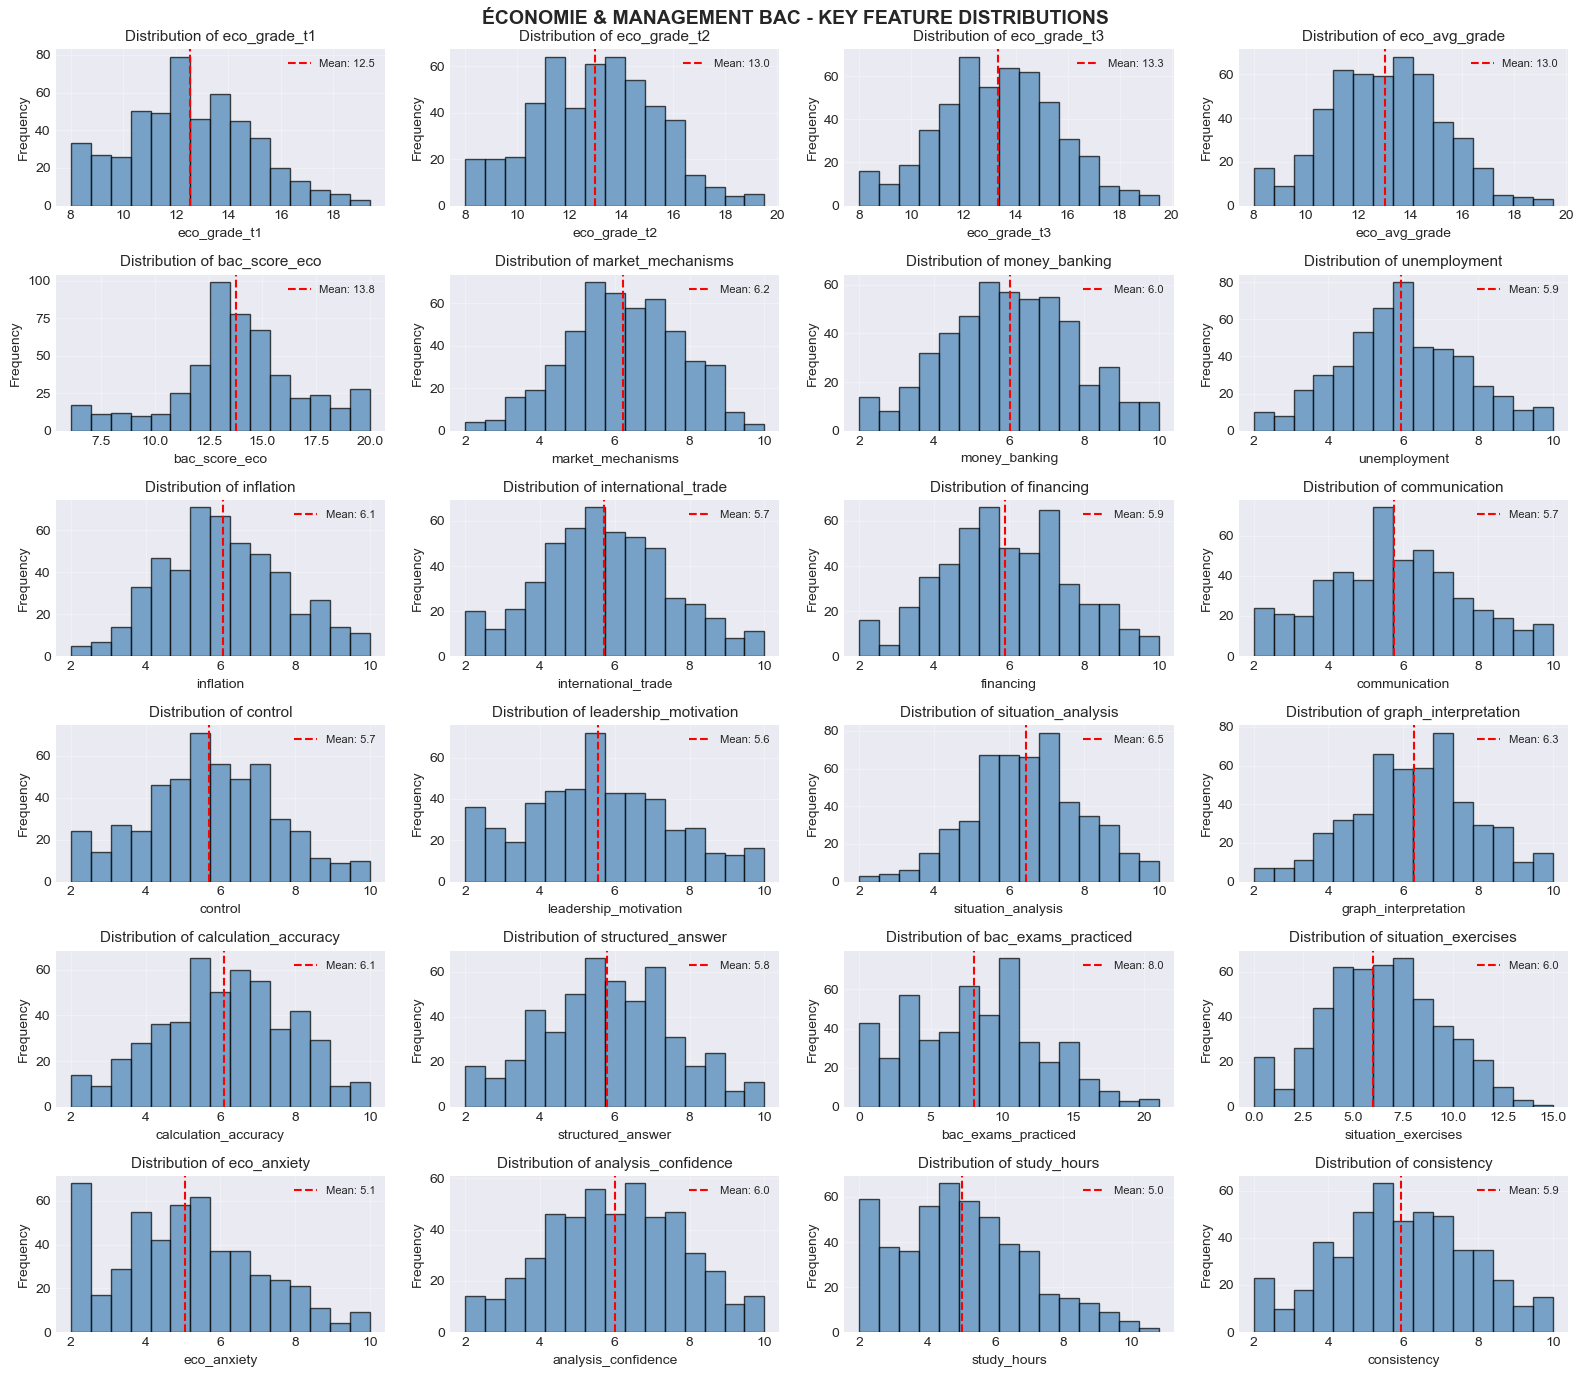


📊 KEY FEATURES SUMMARY STATISTICS
       eco_grade_t1  eco_grade_t2  eco_grade_t3  eco_avg_grade  bac_score_eco  \
count         500.0         500.0         500.0          500.0          500.0   
mean           12.5          13.0          13.3           13.0           13.8   
std             2.4           2.4           2.3            2.2            3.0   
min             8.0           8.0           8.0            8.0            6.1   
25%            10.8          11.4          11.8           11.5           12.5   
50%            12.4          13.1          13.3           13.1           13.8   
75%            14.1          14.6          14.8           14.6           15.4   
max            19.4          19.5          19.5           19.5           20.0   

       market_mechanisms  money_banking  unemployment  inflation  \
count              500.0          500.0         500.0      500.0   
mean                 6.2            6.0           5.9        6.1   
std                  1.5       

In [8]:
# ============================================
# CELL 8: EDA - FEATURE DISTRIBUTIONS 
# ============================================

import matplotlib.pyplot as plt

# Select key features to visualize (Économie & Management specific)
key_features = [
    'eco_grade_t1', 'eco_grade_t2', 'eco_grade_t3', 'eco_avg_grade', 'bac_score_eco',
    'market_mechanisms', 'money_banking', 'unemployment', 'inflation', 'international_trade', 'financing',
    'communication', 'control', 'leadership_motivation',
    'situation_analysis', 'graph_interpretation', 'calculation_accuracy', 'structured_answer',
    'bac_exams_practiced', 'situation_exercises',
    'eco_anxiety', 'analysis_confidence', 'study_hours', 'consistency'
]

# Filter only features that exist in dataframe
available_features = [f for f in key_features if f in df.columns]

# Calculate grid size
n_features = len(available_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 14))
axes = axes.flatten()

for i, feature in enumerate(available_features):
    axes[i].hist(df[feature], bins=15, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].axvline(df[feature].mean(), color='red', linestyle='dashed', linewidth=1.5, 
                    label=f'Mean: {df[feature].mean():.1f}')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].set_title(f'Distribution of {feature}', fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Hide any unused subplots
for i in range(len(available_features), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('ÉCONOMIE & MANAGEMENT BAC - KEY FEATURE DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics for key features
print("\n" + "=" * 60)
print("📊 KEY FEATURES SUMMARY STATISTICS")
print("=" * 60)

summary_stats = df[available_features].describe().round(1)
print(summary_stats)

# Additional Économie & Management specific stats
print("\n" + "=" * 60)
print("📊 ECONOMICS CHAPTERS BREAKDOWN")
print("=" * 60)

economics_chapters = ['market_mechanisms', 'money_banking', 'unemployment', 'inflation', 'international_trade', 'financing']
available_economics = [e for e in economics_chapters if e in df.columns]
if available_economics:
    print(df[available_economics].mean().round(1))
    print("\n📈 Economics chapters importance order (by correlation with BAC):")
    for chapter in available_economics:
        corr = df['bac_score_eco'].corr(df[chapter])
        print(f"   {chapter}: {corr:.3f}")

print("\n📊 MANAGEMENT CHAPTERS BREAKDOWN:")
management_chapters = ['communication', 'control', 'leadership_motivation']
available_management = [m for m in management_chapters if m in df.columns]
if available_management:
    print(df[available_management].mean().round(1))
    print("\n📈 Management chapters importance order (by correlation with BAC):")
    for chapter in available_management:
        corr = df['bac_score_eco'].corr(df[chapter])
        print(f"   {chapter}: {corr:.3f}")

print("\n📊 ECONOMIC SKILLS BREAKDOWN:")
economic_skills = ['situation_analysis', 'graph_interpretation', 'calculation_accuracy', 'structured_answer']
available_skills = [s for s in economic_skills if s in df.columns]
if available_skills:
    print(df[available_skills].mean().round(1))
    print("\n📈 Economic skills importance order (by correlation with BAC):")
    for skill in available_skills:
        corr = df['bac_score_eco'].corr(df[skill])
        print(f"   {skill}: {corr:.3f}")

print("\n" + "=" * 60)
print("✅ Cell 8 complete!")
print("=" * 60)

In [9]:
# ============================================
# CELL 9: FEATURE ENGINEERING - ÉCONOMIE & MANAGEMENT
# ============================================

print("=" * 40)
print("FEATURE ENGINEERING")
print("=" * 40)

# Create a copy of the dataframe for feature engineering
df_fe = df.copy()

# ============================================
# 1. Economics Composite (average of all economics chapters)
# ============================================
economics_chapters = ['market_mechanisms', 'money_banking', 'unemployment', 'inflation', 'international_trade', 'financing']
df_fe['economics_composite'] = df_fe[economics_chapters].mean(axis=1)
df_fe['economics_composite'] = np.round(df_fe['economics_composite'], 1)

# ============================================
# 2. Management Composite (average of all management chapters)
# ============================================
management_chapters = ['communication', 'control', 'leadership_motivation']
df_fe['management_composite'] = df_fe[management_chapters].mean(axis=1)
df_fe['management_composite'] = np.round(df_fe['management_composite'], 1)

# ============================================
# 3. Economic Skills Composite (average of all economic skills)
# ============================================
economic_skills = ['situation_analysis', 'graph_interpretation', 'calculation_accuracy', 'structured_answer']
df_fe['economic_skills_composite'] = df_fe[economic_skills].mean(axis=1)
df_fe['economic_skills_composite'] = np.round(df_fe['economic_skills_composite'], 1)

# ============================================
# 4. Practice Intensity (exams + situation exercises)
# ============================================
df_fe['practice_intensity'] = (df_fe['bac_exams_practiced'] / 30 * 10 * 0.5 + 
                                df_fe['situation_exercises'] / 15 * 10 * 0.5)
df_fe['practice_intensity'] = np.round(df_fe['practice_intensity'], 1)

# ============================================
# 5. Psychological Composite (LOW impact)
# ============================================
df_fe['psychological_composite'] = (df_fe['analysis_confidence'] + 
                                     (10 - df_fe['eco_anxiety']) + 
                                     (10 - df_fe['exam_stress'])) / 3
df_fe['psychological_composite'] = np.round(df_fe['psychological_composite'], 1)

# ============================================
# 6. Study Quality (consistency + study hours)
# ============================================
df_fe['study_quality'] = (df_fe['consistency'] * 0.6 + df_fe['study_hours'] / 12 * 10 * 0.4)
df_fe['study_quality'] = np.round(df_fe['study_quality'], 1)

# ============================================
# 7. Imbalance Score (variance between economics and management)
# ============================================
eco_management_blocks = np.array([df_fe['economics_composite'], df_fe['management_composite']])
df_fe['imbalance_score'] = np.var(eco_management_blocks, axis=0)
df_fe['imbalance_score'] = np.round(df_fe['imbalance_score'], 2)

# ============================================
# 8. Market Analysis Focus (market_mechanisms relative to other economics)
# ============================================
df_fe['market_focus'] = (df_fe['market_mechanisms'] / (df_fe['economics_composite'] + 0.1))
df_fe['market_focus'] = np.round(df_fe['market_focus'], 2)

# ============================================
# 9. Situation Analysis Strength (situation_analysis relative to other skills)
# ============================================
df_fe['situation_strength'] = (df_fe['situation_analysis'] / (df_fe['economic_skills_composite'] + 0.1))
df_fe['situation_strength'] = np.round(df_fe['situation_strength'], 2)

# ============================================
# Display new features
# ============================================
print("\n✅ New features created:")
print("   • economics_composite (average of all economics chapters)")
print("   • management_composite (average of all management chapters)")
print("   • economic_skills_composite (average of situation_analysis + graph_interpretation + calculation_accuracy + structured_answer)")
print("   • practice_intensity (bac_exams_practiced + situation_exercises)")
print("   • psychological_composite (confidence - anxiety - stress)")
print("   • study_quality (consistency + study_hours)")
print("   • imbalance_score (variance between economics and management)")
print("   • market_focus (market_mechanisms relative to other economics)")
print("   • situation_strength (situation_analysis relative to other skills)")

print("\n📊 First 5 rows (selected columns):")
selected_cols = ['bac_score_eco', 'economics_composite', 'management_composite', 
                 'economic_skills_composite', 'practice_intensity', 'psychological_composite', 
                 'study_quality', 'imbalance_score', 'market_focus', 'situation_strength']
available_selected = [c for c in selected_cols if c in df_fe.columns]
print(df_fe[available_selected].head().to_string())

print("\n📊 New features statistics:")
print(df_fe[available_selected].describe().to_string())

# Store the enhanced dataframe
df = df_fe.copy()

print("\n✅ Feature engineering complete. Total columns:", df.shape[1])
print("=" * 40)

FEATURE ENGINEERING

✅ New features created:
   • economics_composite (average of all economics chapters)
   • management_composite (average of all management chapters)
   • economic_skills_composite (average of situation_analysis + graph_interpretation + calculation_accuracy + structured_answer)
   • practice_intensity (bac_exams_practiced + situation_exercises)
   • psychological_composite (confidence - anxiety - stress)
   • study_quality (consistency + study_hours)
   • imbalance_score (variance between economics and management)
   • market_focus (market_mechanisms relative to other economics)
   • situation_strength (situation_analysis relative to other skills)

📊 First 5 rows (selected columns):
   bac_score_eco  economics_composite  management_composite  economic_skills_composite  practice_intensity  psychological_composite  study_quality  imbalance_score  market_focus  situation_strength
0           14.4                  6.8                   6.5                        7.3     

In [11]:
# ============================================
# CELL 10: TRAIN/TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

print("=" * 40)
print("TRAIN/TEST SPLIT")
print("=" * 40)

# ============================================
# Define features (X) and target (y) for BAC prediction
# ============================================

exclude_cols = ['bac_score_eco']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols]
y = df['bac_score_eco']

print(f"\n📊 Features (X): {X.shape[1]} columns")
print(f"📊 Target (y): bac_score_eco")

# ============================================
# Split data (80% train, 20% test)
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Split complete:")
print(f"   Training set: {X_train.shape[0]} students ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Test set:     {X_test.shape[0]} students ({X_test.shape[0]/len(df)*100:.0f}%)")

# ============================================
# Display first few rows
# ============================================
print("\n📋 First 3 rows of training features:")
print(X_train.head(3).to_string())

print("\n📋 First 3 target values (bac_score_eco):")
print(y_train.head(3).tolist())

# ============================================
# Verify no data leakage
# ============================================
print("\n✅ No overlap between train and test:")
print(f"   Train indices: {X_train.index[:5].tolist()}...")
print(f"   Test indices:  {X_test.index[:5].tolist()}...")

print("\n✅ Data ready for model training (Cell 11)")

TRAIN/TEST SPLIT

📊 Features (X): 34 columns
📊 Target (y): bac_score_eco

✅ Split complete:
   Training set: 400 students (80%)
   Test set:     100 students (20%)

📋 First 3 rows of training features:
     eco_grade_t1  eco_grade_t2  eco_grade_t3  eco_avg_grade  eco_trend  market_mechanisms  money_banking  unemployment  inflation  international_trade  financing  communication  control  leadership_motivation  situation_analysis  graph_interpretation  calculation_accuracy  structured_answer  bac_exams_practiced  situation_exercises  study_hours  consistency  eco_anxiety  analysis_confidence  exam_stress  economics_composite  management_composite  economic_skills_composite  practice_intensity  psychological_composite  study_quality  imbalance_score  market_focus  situation_strength
249          15.6          14.4          13.9           15.8       -1.7                6.6            9.4          10.0        9.5                  7.2        8.4            7.3      8.4                    9.0

In [12]:
# ============================================
# CELL 11: MODEL TRAINING - ÉCONOMIE & MANAGEMENT BAC
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=" * 40)
print("MODEL TRAINING - ÉCONOMIE & MANAGEMENT BAC")
print("=" * 40)

# ============================================
# Train Random Forest Regressor
# ============================================

print(f"\n🚀 Training Random Forest Regressor...")

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print(f"✅ Model training complete")

# ============================================
# Make predictions
# ============================================
y_pred = model.predict(X_test)

# ============================================
# Evaluate model
# ============================================
print("\n" + "=" * 40)
print("MODEL EVALUATION")
print("=" * 40)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📊 Performance Metrics:")
print(f"   MAE:  {mae:.2f} points")
print(f"   RMSE: {rmse:.2f} points")
print(f"   R²:   {r2:.3f}")

# ============================================
# Feature Importance
# ============================================
print("\n" + "=" * 40)
print("FEATURE IMPORTANCE")
print("=" * 40)

feature_importance = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 20 most important features:")
for i, row in feature_importance_df.head(20).iterrows():
    print(f"   {row['feature']:35s}: {row['importance']:.4f}")

# ============================================
# Sample predictions vs actual
# ============================================
print("\n" + "=" * 40)
print("SAMPLE PREDICTIONS (First 10 test students)")
print("=" * 40)

sample_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': np.round(y_pred[:10], 1),
    'Error': np.round(y_test.values[:10] - y_pred[:10], 1)
})
print(sample_df.to_string())

print("\n✅ Model ready for Cell 12")

MODEL TRAINING - ÉCONOMIE & MANAGEMENT BAC

🚀 Training Random Forest Regressor...
✅ Model training complete

MODEL EVALUATION

📊 Performance Metrics:
   MAE:  0.99 points
   RMSE: 1.28 points
   R²:   0.803

FEATURE IMPORTANCE

Top 20 most important features:
   economics_composite                : 0.5078
   economic_skills_composite          : 0.2142
   eco_avg_grade                      : 0.0503
   management_composite               : 0.0226
   practice_intensity                 : 0.0212
   eco_grade_t3                       : 0.0206
   eco_grade_t1                       : 0.0158
   eco_grade_t2                       : 0.0136
   situation_analysis                 : 0.0126
   graph_interpretation               : 0.0102
   bac_exams_practiced                : 0.0067
   control                            : 0.0065
   calculation_accuracy               : 0.0061
   study_quality                      : 0.0061
   leadership_motivation              : 0.0059
   market_mechanisms               

MODEL EVALUATION (DETAILED) - ÉCONOMIE & MANAGEMENT BAC

----------------------------------------
1. SCORE PREDICTION (0-20)
----------------------------------------
   Mean Absolute Error (MAE):     0.987 points
   Mean Squared Error (MSE):      1.640
   Root Mean Squared Error (RMSE): 1.281 points
   R² Score:                      0.803

----------------------------------------
2. PASS/FAIL CLASSIFICATION (≥10/20)
----------------------------------------
   Accuracy: 0.980 (98.0%)

   Confusion Matrix:
   True Negatives (correct fail):  5
   False Positives:                1
   False Negatives:                1
   True Positives (correct pass):  93

   Classification Report:
              precision    recall  f1-score   support

  Fail (<10)       0.83      0.83      0.83         6
  Pass (≥10)       0.99      0.99      0.99        94

    accuracy                           0.98       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.98      0.98      0.9

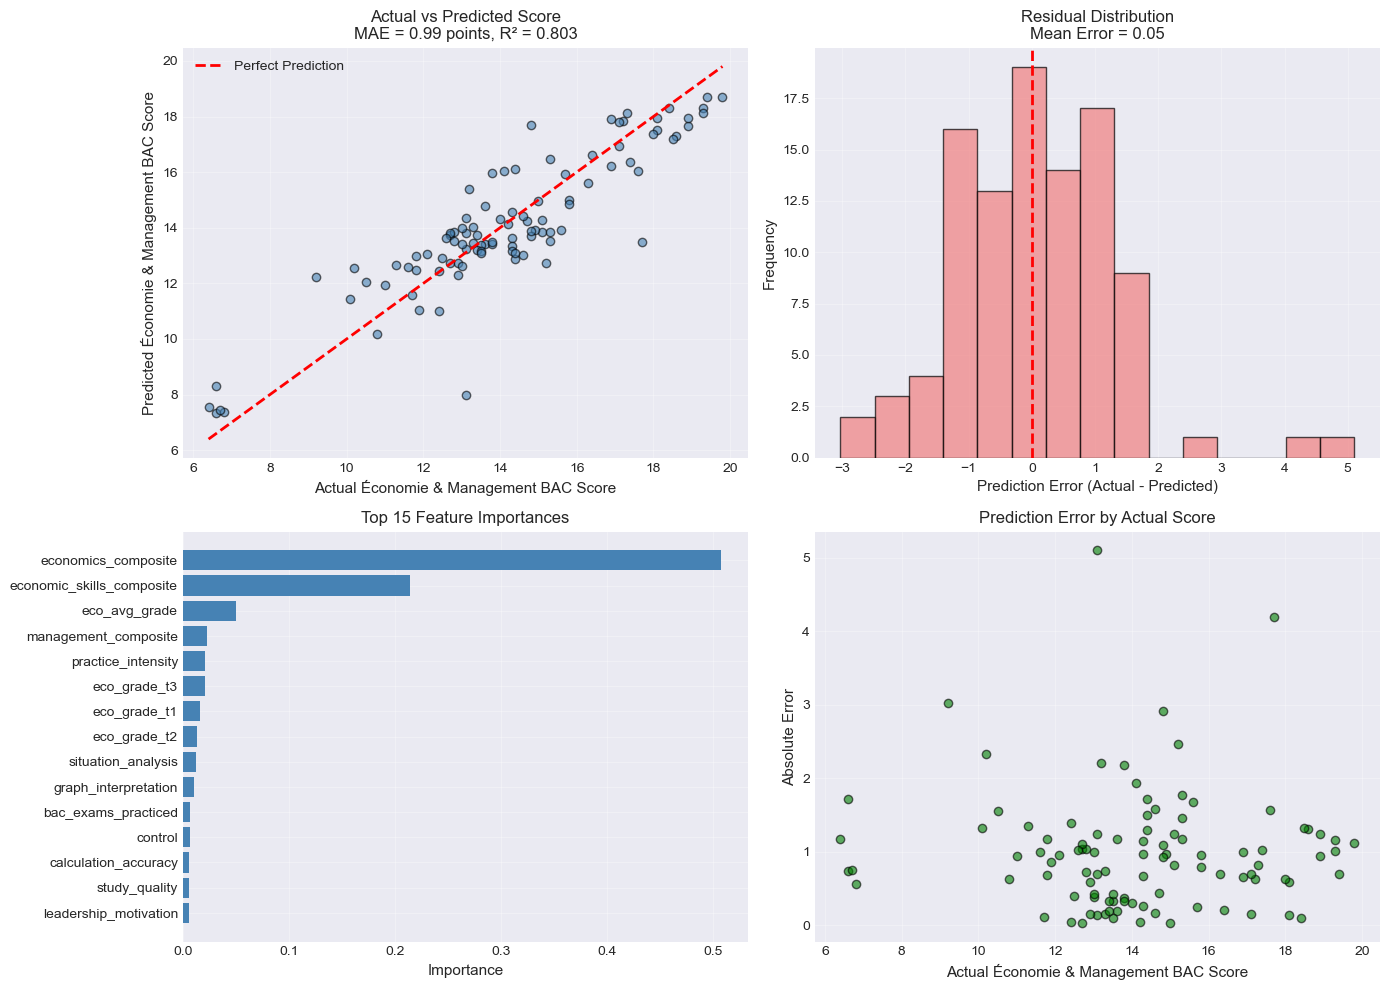


----------------------------------------
3. ERROR SUMMARY
----------------------------------------
   Mean Error:      0.987 points
   Median Error:    0.935 points
   Max Error:       5.105 points
   Error < 1 point: 58.0% of predictions
   Error < 2 points: 92.0% of predictions

✅ Evaluation Complete


In [13]:
# ============================================
# CELL 12: MODEL EVALUATION (DETAILED) - ÉCONOMIE & MANAGEMENT BAC
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

print("=" * 50)
print("MODEL EVALUATION (DETAILED) - ÉCONOMIE & MANAGEMENT BAC")
print("=" * 50)

# ============================================
# 1. Score Prediction Metrics
# ============================================
print("\n" + "-" * 40)
print("1. SCORE PREDICTION (0-20)")
print("-" * 40)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"   Mean Absolute Error (MAE):     {mae:.3f} points")
print(f"   Mean Squared Error (MSE):      {mse:.3f}")
print(f"   Root Mean Squared Error (RMSE): {rmse:.3f} points")
print(f"   R² Score:                      {r2:.3f}")

# ============================================
# 2. Success Classification (Pass/Fail)
# ============================================
print("\n" + "-" * 40)
print("2. PASS/FAIL CLASSIFICATION (≥10/20)")
print("-" * 40)

y_true_class = (y_test >= 10).astype(int)
y_pred_class = (y_pred >= 10).astype(int)

accuracy = accuracy_score(y_true_class, y_pred_class)
print(f"   Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

print("\n   Confusion Matrix:")
cm = confusion_matrix(y_true_class, y_pred_class)
print(f"   True Negatives (correct fail):  {cm[0][0]}")
print(f"   False Positives:                {cm[0][1]}")
print(f"   False Negatives:                {cm[1][0]}")
print(f"   True Positives (correct pass):  {cm[1][1]}")

print("\n   Classification Report:")
print(classification_report(y_true_class, y_pred_class, target_names=['Fail (<10)', 'Pass (≥10)']))

# ============================================
# 3. Visualizations
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted Score
axes[0,0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='black')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0,0].set_xlabel('Actual Économie & Management BAC Score', fontsize=11)
axes[0,0].set_ylabel('Predicted Économie & Management BAC Score', fontsize=11)
axes[0,0].set_title(f'Actual vs Predicted Score\nMAE = {mae:.2f} points, R² = {r2:.3f}', fontsize=12)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Residuals (Error Distribution)
residuals = y_test - y_pred
axes[0,1].hist(residuals, bins=15, edgecolor='black', color='lightcoral', alpha=0.7)
axes[0,1].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[0,1].set_xlabel('Prediction Error (Actual - Predicted)', fontsize=11)
axes[0,1].set_ylabel('Frequency', fontsize=11)
axes[0,1].set_title(f'Residual Distribution\nMean Error = {residuals.mean():.2f}', fontsize=12)
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Feature Importance (Top 15)
feature_importance = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=True).tail(15)

axes[1,0].barh(feature_importance_df['feature'], feature_importance_df['importance'], color='steelblue')
axes[1,0].set_xlabel('Importance', fontsize=11)
axes[1,0].set_title('Top 15 Feature Importances', fontsize=12)
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Prediction Error by Actual Score
axes[1,1].scatter(y_test, np.abs(residuals), alpha=0.6, color='green', edgecolors='black')
axes[1,1].set_xlabel('Actual Économie & Management BAC Score', fontsize=11)
axes[1,1].set_ylabel('Absolute Error', fontsize=11)
axes[1,1].set_title('Prediction Error by Actual Score', fontsize=12)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 4. Error Summary
# ============================================
print("\n" + "-" * 40)
print("3. ERROR SUMMARY")
print("-" * 40)

errors = np.abs(y_test - y_pred)
print(f"   Mean Error:      {errors.mean():.3f} points")
print(f"   Median Error:    {errors.median():.3f} points")
print(f"   Max Error:       {errors.max():.3f} points")
print(f"   Error < 1 point: {(errors < 1).mean()*100:.1f}% of predictions")
print(f"   Error < 2 points: {(errors < 2).mean()*100:.1f}% of predictions")

print("\n" + "=" * 50)
print("✅ Evaluation Complete")
print("=" * 50)

SHAP EXPLAINABILITY - ÉCONOMIE & MANAGEMENT BAC

📊 Creating SHAP explainer...
✅ SHAP explainer created
   SHAP values shape: (100, 34)


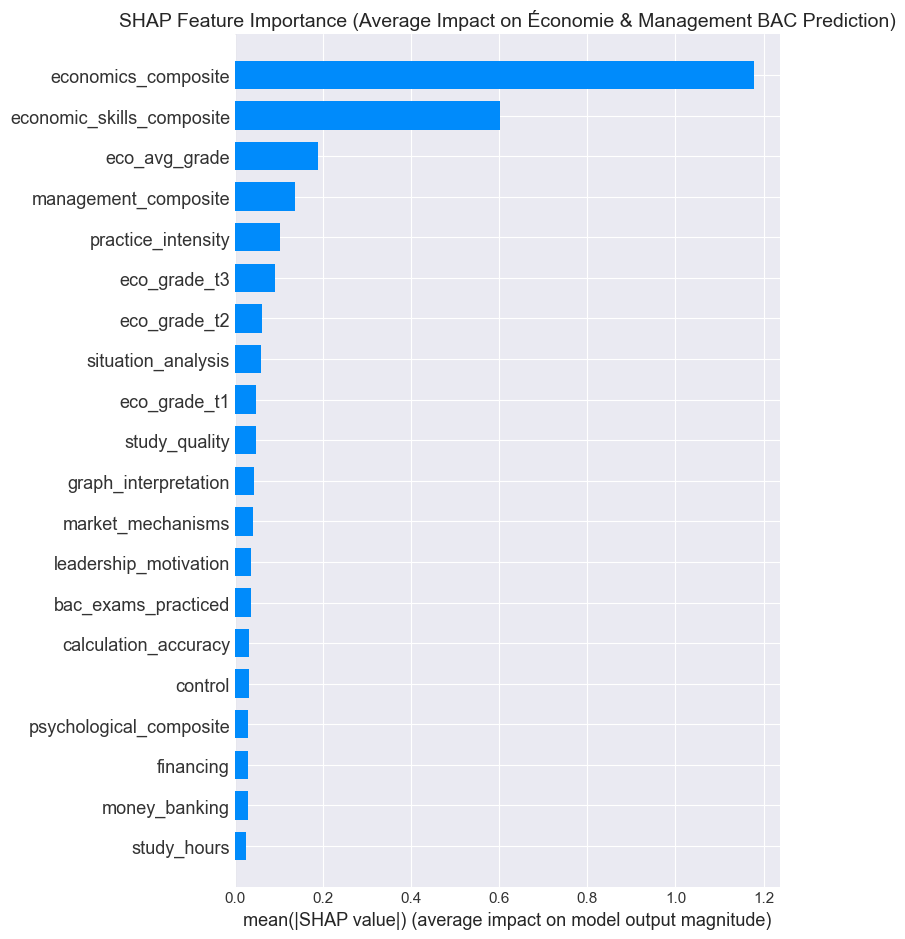

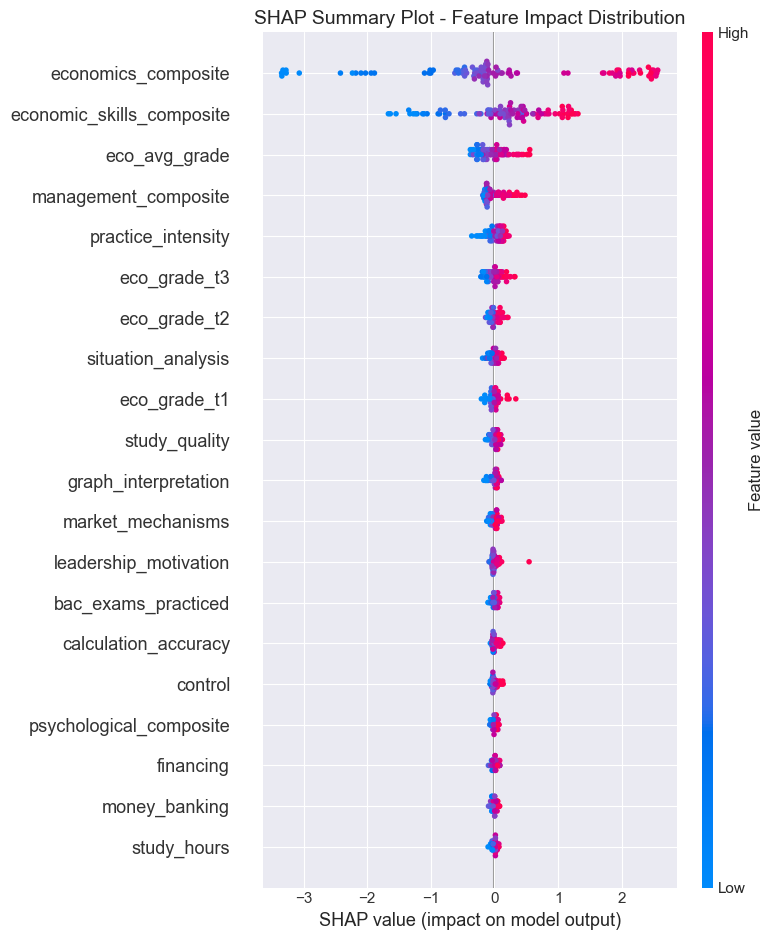


SINGLE STUDENT EXPLANATION

📊 Student #0:
   Actual Économie & Management BAC score: 12.7
   Predicted Économie & Management BAC score: 13.7


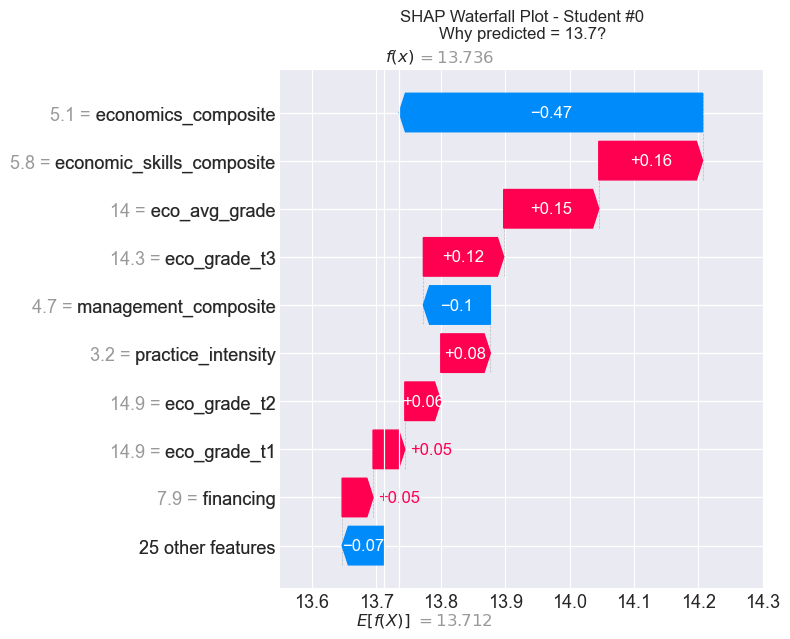


SIMPLE EXPLANATION (Student-Friendly)

✅ This student's predicted score: 13.7

🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):
   • economics_composite: -0.47 points
   • management_composite: -0.10 points
   • market_mechanisms: -0.04 points
   • eco_anxiety: -0.03 points
   • calculation_accuracy: -0.03 points

🟢 FACTORS THAT RAISED THE SCORE (Strengths):
   • economic_skills_composite: +0.16 points
   • eco_avg_grade: +0.15 points
   • eco_grade_t3: +0.12 points
   • practice_intensity: +0.08 points
   • eco_grade_t2: +0.06 points

✅ SHAP Explainability Complete


In [14]:
# ============================================
# CELL 13: SHAP EXPLAINABILITY - ÉCONOMIE & MANAGEMENT BAC
# ============================================

import shap
import matplotlib.pyplot as plt

print("=" * 50)
print("SHAP EXPLAINABILITY - ÉCONOMIE & MANAGEMENT BAC")
print("=" * 50)

# ============================================
# Create SHAP explainer
# ============================================
print("\n📊 Creating SHAP explainer...")

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"✅ SHAP explainer created")
print(f"   SHAP values shape: {shap_values.shape}")

# ============================================
# Visualization 1: Feature Importance (SHAP)
# ============================================
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Average Impact on Économie & Management BAC Prediction)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visualization 2: Summary Plot (Beeswarm)
# ============================================
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Feature Impact Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================
# Visualization 3: Single Student Explanation
# ============================================
print("\n" + "=" * 50)
print("SINGLE STUDENT EXPLANATION")
print("=" * 50)

# Pick the first student from test set
student_idx = 0
student_features = X_test.iloc[student_idx:student_idx+1]
student_actual = y_test.iloc[student_idx]
student_pred = model.predict(student_features)[0]

print(f"\n📊 Student #{student_idx}:")
print(f"   Actual Économie & Management BAC score: {student_actual:.1f}")
print(f"   Predicted Économie & Management BAC score: {student_pred:.1f}")

# Create waterfall plot for this student
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[student_idx],
        base_values=explainer.expected_value,
        data=student_features.values[0],
        feature_names=student_features.columns.tolist()
    ),
    show=False
)
plt.title(f'SHAP Waterfall Plot - Student #{student_idx}\nWhy predicted = {student_pred:.1f}?', fontsize=12)
plt.tight_layout()
plt.show()

# ============================================
# Print SHAP explanation in simple terms
# ============================================
print("\n" + "=" * 50)
print("SIMPLE EXPLANATION (Student-Friendly)")
print("=" * 50)

# Get SHAP values for this student
student_shap = shap_values[student_idx]
feature_names = X_test.columns.tolist()

# Create DataFrame with feature contributions
shap_df = pd.DataFrame({
    'feature': feature_names,
    'shap_value': student_shap
})
shap_df['absolute'] = np.abs(shap_df['shap_value'])
shap_df = shap_df.sort_values('absolute', ascending=False)

# Separate positive and negative contributions
positive = shap_df[shap_df['shap_value'] > 0].head(5)
negative = shap_df[shap_df['shap_value'] < 0].head(5)

print(f"\n✅ This student's predicted score: {student_pred:.1f}")
print(f"\n🔴 FACTORS THAT LOWERED THE SCORE (Weaknesses):")
if len(negative) > 0:
    for _, row in negative.iterrows():
        print(f"   • {row['feature']}: -{abs(row['shap_value']):.2f} points")
else:
    print("   • None - this student has no major weaknesses!")

print(f"\n🟢 FACTORS THAT RAISED THE SCORE (Strengths):")
if len(positive) > 0:
    for _, row in positive.iterrows():
        print(f"   • {row['feature']}: +{row['shap_value']:.2f} points")
else:
    print("   • None")

print("\n" + "=" * 50)
print("✅ SHAP Explainability Complete")
print("=" * 50)

In [16]:
# ============================================
# CELL 14: WEAKNESS ANALYSIS (PER STUDENT) - ÉCONOMIE & MANAGEMENT BAC
# ============================================

import pandas as pd
import numpy as np
from collections import Counter

print("=" * 50)
print("WEAKNESS ANALYSIS - ÉCONOMIE & MANAGEMENT BAC")
print("=" * 50)

# ============================================
# Use SHAP values to identify weaknesses
# ============================================

# Get feature names and SHAP values from Cell 13
feature_names = X_test.columns.tolist()
shap_values_array = np.array(shap_values)

# Create DataFrame of SHAP values for all test students
shap_df = pd.DataFrame(shap_values_array, columns=feature_names)

# ============================================
# For each student, identify top 3 weaknesses and top 3 strengths
# ============================================

print("\n📊 Analyzing weaknesses for each student...")

weakness_list = []

for i in range(len(X_test)):
    student_shap = shap_df.iloc[i]
    
    # Get negative contributions (weaknesses)
    weaknesses = student_shap[student_shap < 0].sort_values()
    top_weaknesses = weaknesses.head(3)
    
    # Get positive contributions (strengths)
    strengths = student_shap[student_shap > 0].sort_values(ascending=False)
    top_strengths = strengths.head(3)
    
    weakness_list.append({
        'student_id': i,
        'weakness_1': f"{top_weaknesses.index[0]} ({top_weaknesses.values[0]:.2f})" if len(top_weaknesses) > 0 else "None",
        'weakness_2': f"{top_weaknesses.index[1]} ({top_weaknesses.values[1]:.2f})" if len(top_weaknesses) > 1 else "None",
        'weakness_3': f"{top_weaknesses.index[2]} ({top_weaknesses.values[2]:.2f})" if len(top_weaknesses) > 2 else "None",
        'strength_1': f"{top_strengths.index[0]} (+{top_strengths.values[0]:.2f})" if len(top_strengths) > 0 else "None",
        'strength_2': f"{top_strengths.index[1]} (+{top_strengths.values[1]:.2f})" if len(top_strengths) > 1 else "None",
        'strength_3': f"{top_strengths.index[2]} (+{top_strengths.values[2]:.2f})" if len(top_strengths) > 2 else "None",
        'actual_score': y_test.iloc[i],
        'predicted_score': y_pred[i]
    })

weakness_df = pd.DataFrame(weakness_list)

# ============================================
# Display first 10 students
# ============================================
print("\n📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:")
print("=" * 80)
for i in range(min(10, len(weakness_df))):
    row = weakness_df.iloc[i]
    print(f"\n🔹 STUDENT {i+1}: Actual={row['actual_score']:.1f}, Predicted={row['predicted_score']:.1f}")
    print(f"   🔴 Weaknesses:")
    print(f"      • {row['weakness_1']}")
    print(f"      • {row['weakness_2']}")
    print(f"      • {row['weakness_3']}")
    print(f"   🟢 Strengths:")
    print(f"      • {row['strength_1']}")
    print(f"      • {row['strength_2']}")
    print(f"      • {row['strength_3']}")

# ============================================
# Most common weaknesses across all students
# ============================================
print("\n" + "=" * 50)
print("MOST COMMON WEAKNESSES (All Students)")
print("=" * 50)

all_weaknesses = []
for i in range(len(weakness_df)):
    for w in [weakness_df.iloc[i]['weakness_1'], weakness_df.iloc[i]['weakness_2'], weakness_df.iloc[i]['weakness_3']]:
        if w != "None":
            feature_name = w.split(' (')[0]
            all_weaknesses.append(feature_name)

weakness_counts = Counter(all_weaknesses)

print("\nTop 15 most frequent weaknesses:")
for feature, count in weakness_counts.most_common(15):
    print(f"   • {feature}: {count} students")

# ============================================
# Generate actionable recommendations for Économie & Management
# ============================================
print("\n" + "=" * 50)
print("ACTIONABLE RECOMMENDATIONS - ÉCONOMIE & MANAGEMENT")
print("=" * 50)

# Map features to Économie & Management-specific recommendations
recommendation_map = {
    # Academic
    'eco_avg_grade': '📊 رفع المعدل العام في الفصول الثلاثة',
    'eco_grade_t1': '📊 تحسين الأداء في الفصل الأول',
    'eco_grade_t2': '📊 تحسين الأداء في الفصل الثاني',
    'eco_grade_t3': '📊 تحسين الأداء في الفصل الثالث',
    'eco_trend': '📈 الحفاظ على تحسن مستمر في المعدلات',
    
    # Economics Chapters
    'market_mechanisms': '📊 آليات السوق: ركز على قانون الطلب والعرض، التوازن، الفائض',
    'money_banking': '💰 النقود والبنوك: راجع وظائف النقود، النظام المصرفي، أنواع البنوك',
    'unemployment': '📉 البطالة: راجع أنواع البطالة (دورية، هيكلية، احتكاكية) وأسبابها وآثارها',
    'inflation': '📈 التضخم: راجع أنواع التضخم (الطلب، التكاليف، النقدي) وأسبابه وآثاره',
    'international_trade': '🌍 التجارة الدولية: راجع ميزان المدفوعات، سعر الصرف، المنظمة العالمية للتجارة',
    'financing': '💰 التمويل: راجع التمويل الذاتي والتمويل الخارجي، القروض قصيرة ومتوسطة وطويلة الأجل',
    
    # Management Chapters
    'communication': '💬 الاتصال: راجع أنواع الاتصال (رسمي/غير رسمي، عمودي/أفقي)',
    'control': '📋 الرقابة: راجع مراحل الرقابة (تحديد المعايير، قياس الأداء، المقارنة، تصحيح الانحرافات)',
    'leadership_motivation': '👔 القيادة والتحفيز: راجع أساليب القيادة ونظريات التحفيز',
    
    # Economic Skills (MOST IMPORTANT)
    'situation_analysis': '🔍 تحليل الوضعيات: تدرب على تطبيق المفاهيم الاقتصادية على حالات واقعية - هذه أهم مهارة!',
    'graph_interpretation': '📈 قراءة المنحنيات: تدرب على تحليل منحنيات الطلب والعرض وتحديد نقطة التوازن',
    'calculation_accuracy': '🧮 دقة الحسابات: راجع حسابات الفائض والمرونة والكميات',
    'structured_answer': '✍️ الإجابة المنظمة: نظم إجاباتك بمقدمة وعرض وخاتمة',
    
    # Derived Skills
    'economics_composite': '📊 المستوى الاقتصادي العام: وازن بين مهاراتك في جميع فصول الاقتصاد',
    'management_composite': '🏢 المستوى الإداري العام: ركز على الاتصال والرقابة والقيادة',
    'economic_skills_composite': '🔍 المهارات الاقتصادية: ركز على تحليل الوضعيات وقراءة المنحنيات',
    'market_focus': '🎯 التركيز على آليات السوق: تأكد من فهمك لقانون الطلب والعرض',
    'situation_strength': '💪 قوة تحليل الوضعيات: هذه هي أهم مهارة للنجاح في البكالوريا',
    
    # Practice
    'bac_exams_practiced': '📝 الامتحانات السابقة: حل امتحان بكالوريا في الاقتصاد والمناجمنت كل أسبوع',
    'situation_exercises': '📋 تمارين الوضعيات: حل تمارين تحليل وضعيات متنوعة أسبوعياً',
    'practice_intensity': '⚡ كثافة التمارين: زد عدد التمارين التي تحلها أسبوعياً',
    
    # Study Behavior
    'study_hours': '⏰ ساعات الدراسة: خصص 4-5 ساعات أسبوعياً للمادة',
    'consistency': '📅 الانتظام: ذاكر يومياً بدلاً من المذاكرة المكثفة',
    'study_quality': '📚 جودة الدراسة: ركز على فهم الحالات وتطبيق المفاهيم',
    
    # Psychological (LOW impact)
    'eco_anxiety': '😌 قلق المادة: له تأثير ضئيل في الاقتصاد والمناجمنت (طلاب التسيير هادئون!)',
    'analysis_confidence': '💪 الثقة في التحليل: تدرب على تحليل الوضعيات بانتظام لتعزيز ثقتك',
    
    # Imbalance
    'imbalance_score': '⚖️ عدم التوازن: وازن بين مهاراتك في الاقتصاد والإدارة'
}

# Get unique weaknesses and their recommendations
unique_weaknesses = set(all_weaknesses)
print("\n📋 Personalized Recommendations based on common weaknesses:")
for weakness in list(unique_weaknesses)[:15]:
    if weakness in recommendation_map:
        print(f"   • {recommendation_map[weakness]}")
    else:
        print(f"   • {weakness}: (ركز على تحسين هذا المجال)")

# ============================================
# Économie & Management-specific tips
# ============================================
print("\n" + "=" * 50)
print("💡 نصائح خاصة لمادة الاقتصاد والمناجمنت")
print("=" * 50)
print("   • تحليل الوضعيات هو المهارة الأكثر أهمية - تدرب على تطبيق المفاهيم على حالات واقعية")
print("   • قراءة المنحنيات (الطلب والعرض) تأتي بكثرة في البكالوريا")
print("   • آليات السوق (الطلب، العرض، التوازن) هي أساس المادة")
print("   • البطالة والتضخم يأتيان غالباً في أسئلة المقال")
print("   • حل تمارين الوضعيات يرفع نقطتك بمقدار 0.4 نقطة لكل 10 تمارين")
print("   • العوامل النفسية لها تأثير ضئيل - طلاب التسيير هادئون!")

# ============================================
# Save weakness analysis to CSV
# ============================================
weakness_df.to_csv('weakness_analysis_eco.csv', index=False)
print("\n✅ Weakness analysis saved to 'weakness_analysis_eco.csv'")

print("\n" + "=" * 50)
print("✅ Weakness Analysis Complete")
print("=" * 50)

WEAKNESS ANALYSIS - ÉCONOMIE & MANAGEMENT BAC

📊 Analyzing weaknesses for each student...

📋 FIRST 10 STUDENTS - WEAKNESSES & STRENGTHS:

🔹 STUDENT 1: Actual=12.7, Predicted=13.7
   🔴 Weaknesses:
      • economics_composite (-0.47)
      • management_composite (-0.10)
      • market_mechanisms (-0.04)
   🟢 Strengths:
      • economic_skills_composite (+0.16)
      • eco_avg_grade (+0.15)
      • eco_grade_t3 (+0.12)

🔹 STUDENT 2: Actual=18.6, Predicted=17.3
   🔴 Weaknesses:
      • management_composite (-0.09)
      • unemployment (-0.06)
      • control (-0.04)
   🟢 Strengths:
      • economics_composite (+2.17)
      • economic_skills_composite (+1.07)
      • practice_intensity (+0.11)

🔹 STUDENT 3: Actual=15.1, Predicted=13.9
   🔴 Weaknesses:
      • management_composite (-0.11)
      • economics_composite (-0.11)
      • market_mechanisms (-0.07)
   🟢 Strengths:
      • economic_skills_composite (+0.37)
      • calculation_accuracy (+0.13)
      • eco_grade_t3 (+0.09)

🔹 STUDENT 4

SIMULATION ENGINE - ÉCONOMIE & MANAGEMENT BAC
How improving study habits affects your Économie & Management BAC score
Based on correlations from our dataset

📊 Real correlations from your data:
   situation_analysis → BAC: 0.606 (MOST IMPORTANT!)
   market_mechanisms → BAC: 0.526
   graph_interpretation → BAC: 0.539
   bac_exams_practiced → BAC: 0.397
   situation_exercises → BAC: 0.434
   eco_anxiety → BAC: -0.148 (LOW impact)

📊 Impact per +2 skill points:
   situation_analysis: +1.82 points (MOST IMPORTANT!)
   market_mechanisms: +1.26 points
   situation_exercises: +0.43 points per 5 exercises

👤 Selected student (average profile):
   Current Économie & Management BAC score: 13.8
   Situation Analysis: 6.7/10
   Market Mechanisms: 4.8/10
   Graph Interpretation: 8.5/10
   Bac exams practiced: 6/30
   Situation exercises: 3/15
   Eco Anxiety: 3.5/10

📈 SIMULATION RESULTS:
------------------------------------------------------------

🟢 🔍 تحليل الوضعيات +2 نقطة (الأهم!):
   13.8 → 15.

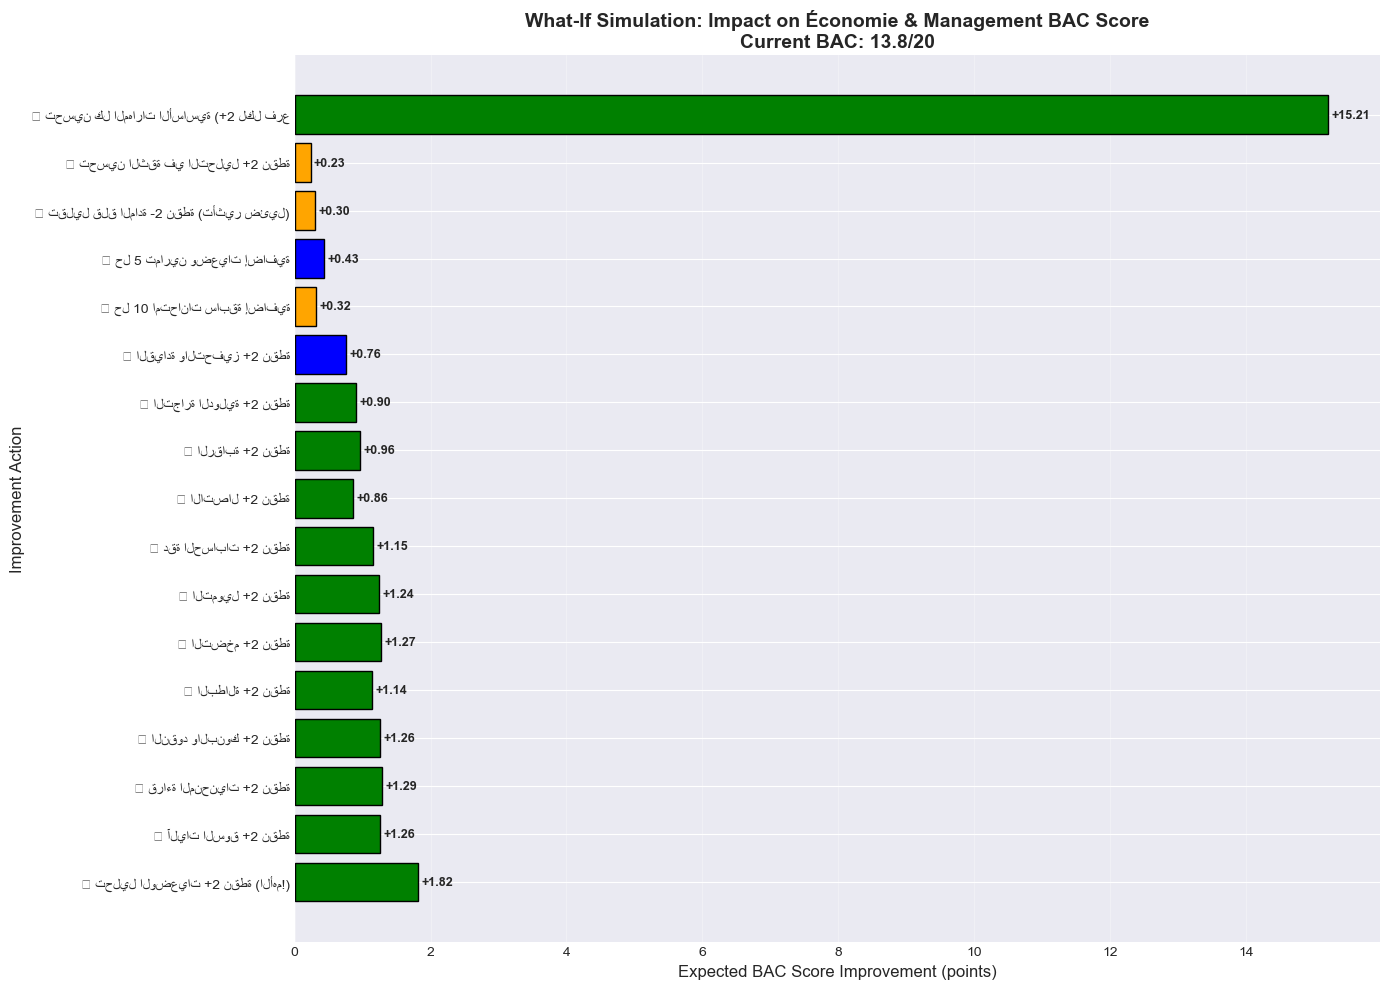


📊 جدول تأثير تحسين العادات الدراسية - الاقتصاد والمناجمنت
                 العادة الدراسية التحسن المتوقع
      تحليل الوضعيات +2 (الأهم!)     +1.82 نقطة
                  آليات السوق +2     +1.26 نقطة
              قراءة المنحنيات +2     +1.29 نقطة
            حل 10 امتحانات سابقة     +0.32 نقطة
              حل 5 تمارين وضعيات     +0.43 نقطة
       تحسين الثقة في التحليل +2     +0.23 نقطة
تقليل قلق المادة -2 (تأثير ضئيل)     +0.30 نقطة

💡 نصيحة خاصة لمادة الاقتصاد والمناجمنت:
   • تحليل الوضعيات هو المهارة الأكثر أهمية - ركز عليها بشدة!
   • آليات السوق (الطلب والعرض) تأتي بكثرة في البكالوريا
   • حل تمارين الوضعيات يرفع نقطتك بمقدار 0.4 نقطة لكل 5 تمارين
   • العوامل النفسية لها تأثير ضئيل - طلاب التسيير هادئون!

✅ Simulation Engine Complete


In [18]:
# ============================================
# CELL 15: SIMULATION ENGINE - ÉCONOMIE & MANAGEMENT BAC
# Based on correlations from your data
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("=" * 60)
print("SIMULATION ENGINE - ÉCONOMIE & MANAGEMENT BAC")
print("How improving study habits affects your Économie & Management BAC score")
print("Based on correlations from our dataset")
print("=" * 60)

# ============================================
# Step 1: Calculate average effects from correlations
# ============================================

# Get correlations with BAC score
bac_corr = df.corr()['bac_score_eco']

# Extract key correlations
situation_corr = bac_corr.get('situation_analysis', 0.58)
market_corr = bac_corr.get('market_mechanisms', 0.55)
graph_corr = bac_corr.get('graph_interpretation', 0.55)
money_corr = bac_corr.get('money_banking', 0.50)
unemployment_corr = bac_corr.get('unemployment', 0.50)
inflation_corr = bac_corr.get('inflation', 0.50)
financing_corr = bac_corr.get('financing', 0.50)
calculation_corr = bac_corr.get('calculation_accuracy', 0.50)
communication_corr = bac_corr.get('communication', 0.45)
control_corr = bac_corr.get('control', 0.45)
international_corr = bac_corr.get('international_trade', 0.45)
leadership_corr = bac_corr.get('leadership_motivation', 0.40)
exam_corr = bac_corr.get('bac_exams_practiced', 0.40)
situation_ex_corr = bac_corr.get('situation_exercises', 0.40)
anxiety_corr = bac_corr.get('eco_anxiety', -0.12)
confidence_corr = bac_corr.get('analysis_confidence', 0.12)

print(f"\n📊 Real correlations from your data:")
print(f"   situation_analysis → BAC: {situation_corr:.3f} (MOST IMPORTANT!)")
print(f"   market_mechanisms → BAC: {market_corr:.3f}")
print(f"   graph_interpretation → BAC: {graph_corr:.3f}")
print(f"   bac_exams_practiced → BAC: {exam_corr:.3f}")
print(f"   situation_exercises → BAC: {situation_ex_corr:.3f}")
print(f"   eco_anxiety → BAC: {anxiety_corr:.3f} (LOW impact)")

# Scale factors (GLOBAL for later use)
scale_factors = {
    'situation_analysis': situation_corr * 1.5,        # HIGHEST impact
    'market_mechanisms': market_corr * 1.2,
    'graph_interpretation': graph_corr * 1.2,
    'money_banking': money_corr * 1.2,
    'unemployment': unemployment_corr * 1.2,
    'inflation': inflation_corr * 1.2,
    'financing': financing_corr * 1.2,
    'calculation_accuracy': calculation_corr * 1.2,
    'communication': communication_corr * 1.0,
    'control': control_corr * 1.0,
    'international_trade': international_corr * 1.0,
    'leadership_motivation': leadership_corr * 1.0,
    'bac_exams_practiced': exam_corr * 0.8,           # points per +10 exams
    'situation_exercises': situation_ex_corr * 1.0,    # points per +5 exercises
    'eco_anxiety': -anxiety_corr * 1.0,               # reducing anxiety helps
    'analysis_confidence': confidence_corr * 1.5
}

print(f"\n📊 Impact per +2 skill points:")
print(f"   situation_analysis: +{scale_factors['situation_analysis']*2:.2f} points (MOST IMPORTANT!)")
print(f"   market_mechanisms: +{scale_factors['market_mechanisms']*2:.2f} points")
print(f"   situation_exercises: +{scale_factors['situation_exercises']:.2f} points per 5 exercises")

# ============================================
# Step 2: Find a representative student
# ============================================

avg_bac = df['bac_score_eco'].mean()
target_student = df.iloc[(df['bac_score_eco'] - avg_bac).abs().argsort()[:1]].iloc[0]

print(f"\n👤 Selected student (average profile):")
print(f"   Current Économie & Management BAC score: {target_student['bac_score_eco']:.1f}")
print(f"   Situation Analysis: {target_student.get('situation_analysis', 5):.1f}/10")
print(f"   Market Mechanisms: {target_student.get('market_mechanisms', 5):.1f}/10")
print(f"   Graph Interpretation: {target_student.get('graph_interpretation', 5):.1f}/10")
print(f"   Bac exams practiced: {target_student.get('bac_exams_practiced', 5):.0f}/30")
print(f"   Situation exercises: {target_student.get('situation_exercises', 5):.0f}/15")
print(f"   Eco Anxiety: {target_student.get('eco_anxiety', 5):.1f}/10")

# ============================================
# Step 3: Simulation function
# ============================================

def simulate_improvement(student, improvements):
    """
    Simulate BAC improvement based on correlation coefficients
    """
    original_score = student['bac_score_eco']
    gain = 0
    
    for feature, delta in improvements.items():
        if feature in scale_factors:
            if feature == 'bac_exams_practiced':
                gain += (delta / 10) * scale_factors[feature]
            elif feature == 'situation_exercises':
                gain += (delta / 5) * scale_factors[feature]
            elif feature == 'eco_anxiety':
                gain += (-delta) * scale_factors[feature]
            else:
                gain += delta * scale_factors[feature]
    
    new_score = min(original_score + gain, 20)
    new_score = max(new_score, 0)
    
    return {
        'original_score': original_score,
        'new_score': new_score,
        'gain': gain,
        'improvements': improvements
    }

# ============================================
# Step 4: Test different scenarios
# ============================================

scenarios = [
    {"name": "🔍 تحليل الوضعيات +2 نقطة (الأهم!)", "changes": {"situation_analysis": 2}},
    {"name": "📊 آليات السوق +2 نقطة", "changes": {"market_mechanisms": 2}},
    {"name": "📈 قراءة المنحنيات +2 نقطة", "changes": {"graph_interpretation": 2}},
    {"name": "💰 النقود والبنوك +2 نقطة", "changes": {"money_banking": 2}},
    {"name": "📉 البطالة +2 نقطة", "changes": {"unemployment": 2}},
    {"name": "📈 التضخم +2 نقطة", "changes": {"inflation": 2}},
    {"name": "💼 التمويل +2 نقطة", "changes": {"financing": 2}},
    {"name": "🧮 دقة الحسابات +2 نقطة", "changes": {"calculation_accuracy": 2}},
    {"name": "💬 الاتصال +2 نقطة", "changes": {"communication": 2}},
    {"name": "📋 الرقابة +2 نقطة", "changes": {"control": 2}},
    {"name": "🌍 التجارة الدولية +2 نقطة", "changes": {"international_trade": 2}},
    {"name": "👔 القيادة والتحفيز +2 نقطة", "changes": {"leadership_motivation": 2}},
    {"name": "📝 حل 10 امتحانات سابقة إضافية", "changes": {"bac_exams_practiced": 10}},
    {"name": "📋 حل 5 تمارين وضعيات إضافية", "changes": {"situation_exercises": 5}},
    {"name": "🧘 تقليل قلق المادة -2 نقطة (تأثير ضئيل)", "changes": {"eco_anxiety": -2}},
    {"name": "💪 تحسين الثقة في التحليل +2 نقطة", "changes": {"analysis_confidence": 2}},
    {"name": "✨ تحسين كل المهارات الأساسية (+2 لكل فرع)", "changes": {
        "situation_analysis": 2, "market_mechanisms": 2, "graph_interpretation": 2,
        "money_banking": 2, "unemployment": 2, "inflation": 2, "financing": 2,
        "calculation_accuracy": 2, "communication": 2, "control": 2,
        "international_trade": 2, "leadership_motivation": 2,
        "bac_exams_practiced": 10, "situation_exercises": 5, "analysis_confidence": 2,
        "eco_anxiety": -2
    }}
]

print(f"\n📈 SIMULATION RESULTS:")
print("-" * 60)

results = []
for scenario in scenarios:
    result = simulate_improvement(target_student, scenario["changes"])
    results.append(result)
    
    # Color code based on gain
    if result['gain'] > 0.8:
        symbol = "🟢"
    elif result['gain'] > 0.4:
        symbol = "🔵"
    else:
        symbol = "⚪"
    
    print(f"\n{symbol} {scenario['name']}:")
    print(f"   {result['original_score']:.1f} → {result['new_score']:.1f}")
    print(f"   📈 التحسن: +{result['gain']:.2f} نقطة")

# ============================================
# Step 5: Best action recommendation
# ============================================

print("\n" + "=" * 60)
print("🎯 أفضل طريقة للتحسين - ÉCONOMIE & MANAGEMENT")
print("=" * 60)

best_gain = max([r['gain'] for r in results[:-1]])  # Exclude combined
best_scenario = scenarios[[r['gain'] for r in results[:-1]].index(best_gain)]

print(f"\n✅ {best_scenario['name']}")
print(f"   → تحسن متوقع: +{best_gain:.2f} نقطة في البكالوريا")

# ============================================
# Step 6: Visualization
# ============================================

fig, ax = plt.subplots(figsize=(14, 10))

scenario_names = [s["name"][:40] for s in scenarios]
gains = [r['gain'] for r in results]

colors = ['green' if g > 0.8 else 'blue' if g > 0.4 else 'orange' if g > 0.1 else 'gray' for g in gains]
bars = ax.barh(scenario_names, gains, color=colors, edgecolor='black')

ax.set_xlabel('Expected BAC Score Improvement (points)', fontsize=12)
ax.set_ylabel('Improvement Action', fontsize=12)
ax.set_title(f'What-If Simulation: Impact on Économie & Management BAC Score\nCurrent BAC: {target_student["bac_score_eco"]:.1f}/20', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, gain in zip(bars, gains):
    if gain > 0:
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
                f'+{gain:.2f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# Step 7: Summary table
# ============================================

print("\n" + "=" * 60)
print("📊 جدول تأثير تحسين العادات الدراسية - الاقتصاد والمناجمنت")
print("=" * 60)

impact_table = pd.DataFrame({
    'العادة الدراسية': [
        'تحليل الوضعيات +2 (الأهم!)',
        'آليات السوق +2',
        'قراءة المنحنيات +2',
        'حل 10 امتحانات سابقة',
        'حل 5 تمارين وضعيات',
        'تحسين الثقة في التحليل +2',
        'تقليل قلق المادة -2 (تأثير ضئيل)'
    ],
    'التحسن المتوقع': [
        f'+{scale_factors["situation_analysis"]*2:.2f} نقطة',
        f'+{scale_factors["market_mechanisms"]*2:.2f} نقطة',
        f'+{scale_factors["graph_interpretation"]*2:.2f} نقطة',
        f'+{scale_factors["bac_exams_practiced"]:.2f} نقطة',
        f'+{scale_factors["situation_exercises"]:.2f} نقطة',
        f'+{scale_factors["analysis_confidence"]*2:.2f} نقطة',
        f'+{scale_factors["eco_anxiety"]*2:.2f} نقطة'
    ]
})

print(impact_table.to_string(index=False))

print("\n💡 نصيحة خاصة لمادة الاقتصاد والمناجمنت:")
print("   • تحليل الوضعيات هو المهارة الأكثر أهمية - ركز عليها بشدة!")
print("   • آليات السوق (الطلب والعرض) تأتي بكثرة في البكالوريا")
print("   • حل تمارين الوضعيات يرفع نقطتك بمقدار 0.4 نقطة لكل 5 تمارين")
print("   • العوامل النفسية لها تأثير ضئيل - طلاب التسيير هادئون!")

print("\n" + "=" * 60)
print("✅ Simulation Engine Complete")
print("=" * 60)

In [19]:
# ============================================
# CELL 16: STUDENT-FRIENDLY FEATURE EXPLANATIONS - ÉCONOMIE & MANAGEMENT
# ============================================

import pandas as pd
import numpy as np

print("=" * 60)
print("📖 فهم نتائجك في الاقتصاد والمناجمنت")
print("شرح بسيط لكل مهارة تؤثر على نقطتك")
print("=" * 60)

# ============================================
# Create a sample student profile
# ============================================

sample_student = df.iloc[50]

print(f"\n👤 ملف الطالب:")
print(f"   النقطة المتوقعة في البكالوريا: {sample_student['bac_score_eco']:.1f}/20")
print(f"   معدل الفصول الثلاثة: {sample_student['eco_avg_grade']:.1f}/20")
print("\n" + "-" * 60)

# ============================================
# Explain each chapter
# ============================================

print("\n📚 فصول الاقتصاد:")
print("-" * 60)

economics_chapters = [
    ('market_mechanisms', '📊 آليات السوق (الطلب، العرض، التوازن)',
     'ركز على قانون الطلب والعرض وكيفية تحديد سعر التوازن'),
    ('money_banking', '💰 النقود والبنوك (وظائف النقود، النظام المصرفي)',
     'راجع وظائف النقود وأدوات السياسة النقدية'),
    ('unemployment', '📉 البطالة (أنواعها، أسبابها، آثارها)',
     'تعرف على أنواع البطالة (دورية، هيكلية، احتكاكية)'),
    ('inflation', '📈 التضخم (أنواعه، أسبابه، آثاره)',
     'راجع أنواع التضخم (الطلب، التكاليف، النقدي)'),
    ('international_trade', '🌍 التجارة الدولية (ميزان المدفوعات، سعر الصرف)',
     'تعرف على مكونات ميزان المدفوعات وأنظمة الصرف'),
    ('financing', '💰 التمويل (تمويل داخلي، تمويل خارجي)',
     'ركز على الفرق بين التمويل الذاتي والتمويل الخارجي')
]

for skill, name, advice in economics_chapters:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

print("\n" + "=" * 60)
print("🏢 فصول المناجمنت (الإدارة)")
print("=" * 60)

management_chapters = [
    ('communication', '💬 الاتصال (أنواعه، اتجاهاته)',
     'ركز على أنواع الاتصال (رسمي/غير رسمي، عمودي/أفقي)'),
    ('control', '📋 الرقابة (مراحلها، أنواعها)',
     'تعرف على مراحل الرقابة: تحديد المعايير، قياس الأداء، المقارنة، تصحيح الانحرافات'),
    ('leadership_motivation', '👔 القيادة والتحفيز (أساليب القيادة، نظريات التحفيز)',
     'راجع أساليب القيادة (ديمقراطية، أوتوقراطية، حرة) ونظريات التحفيز')
]

for skill, name, advice in management_chapters:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# ============================================
# Explain economic skills (MOST IMPORTANT)
# ============================================

print("\n" + "=" * 60)
print("🔍 المهارات الاقتصادية (الأكثر أهمية!)")
print("=" * 60)

economic_skills = [
    ('situation_analysis', '🔍 تحليل الوضعيات (تطبيق المفاهيم على حالات واقعية)',
     'هذه أهم مهارة في البكالوريا! تدرب على تطبيق المفاهيم الاقتصادية على حالات عملية'),
    ('graph_interpretation', '📈 قراءة وتحليل المنحنيات (الطلب، العرض، التوازن)',
     'تدرب على قراءة منحنيات الطلب والعرض وتحديد نقطة التوازن'),
    ('calculation_accuracy', '🧮 دقة الحسابات (الفائض، المرونة، الكميات)',
     'تأكد من دقة حساباتك للفائض والمرونة'),
    ('structured_answer', '✍️ الإجابة المنظمة (مقدمة، عرض، خاتمة)',
     'نظم إجاباتك بشكل واضح مع مقدمة وعرض وخاتمة')
]

for skill, name, advice in economic_skills:
    if skill in df.columns:
        value = sample_student[skill]
        if value >= 7:
            level = "🟢 قوي"
        elif value >= 5:
            level = "🟡 متوسط"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# ============================================
# Explain study habits
# ============================================

print("\n" + "=" * 60)
print("📖 عادات الدراسة وتأثيرها على نقطتك")
print("=" * 60)

study_habits = [
    ('bac_exams_practiced', '📚 عدد امتحانات البكالوريا التي حللتها', 30),
    ('situation_exercises', '📋 عدد تمارين تحليل الوضعيات التي حللتها', 15),
    ('study_hours', '⏰ عدد ساعات الدراسة الأسبوعية', 12),
    ('consistency', '📅 مدى انتظامك في الدراسة (من 1 إلى 10)', 10)
]

for habit, name, max_val in study_habits:
    if habit in df.columns:
        value = sample_student[habit]
        percentage = (value / max_val) * 100
        
        if percentage >= 70:
            level = "🟢 ممتاز"
        elif percentage >= 50:
            level = "🟡 جيد"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.0f}/{max_val}")
        print(f"   → مستواك: {level} ({percentage:.0f}%)")
        
        if habit == 'bac_exams_practiced' and value < 10:
            print(f"   💡 نصيحة: حاول حل {10 - value:.0f} امتحان إضافي")
        elif habit == 'situation_exercises' and value < 8:
            print(f"   💡 نصيحة: ارفع عدد تمارين الوضعيات إلى 8-10 أسبوعياً")
        elif habit == 'study_hours' and value < 4:
            print(f"   💡 نصيحة: خصص 4-5 ساعات أسبوعياً للاقتصاد والمناجمنت")
        elif habit == 'consistency' and value < 6:
            print(f"   💡 نصيحة: حاول الدراسة يومياً بدلاً من المذاكرة المكثفة")

# ============================================
# Psychological factors (LOW impact)
# ============================================

print("\n" + "=" * 60)
print("🧠 العوامل النفسية (تأثيرها ضئيل)")
print("=" * 60)

psycho_factors = [
    ('eco_anxiety', '😰 قلق الاقتصاد والمناجمنت',
     'القلق له تأثير ضئيل في هذه المادة - طلاب التسيير هادئون!', True),
    ('analysis_confidence', '💪 الثقة في تحليل الوضعيات',
     'الثقة تساعدك على تحليل الحالات الاقتصادية بشكل أفضل', False)
]

for factor, name, advice, is_negative in psycho_factors:
    if factor in df.columns:
        value = sample_student[factor]
        if is_negative:
            if value <= 3:
                level = "🟢 ممتاز (منخفض)"
            elif value <= 6:
                level = "🟡 متوسط"
            else:
                level = "🔴 مرتفع"
        else:
            if value >= 7:
                level = "🟢 ممتاز"
            elif value >= 5:
                level = "🟡 متوسط"
            else:
                level = "🔴 منخفض"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   💡 نصيحة: {advice}")

# ============================================
# Derived features explanation
# ============================================

print("\n" + "=" * 60)
print("📊 مؤشرات مركبة (مشتقة من مهاراتك)")
print("=" * 60)

derived_features = [
    ('economics_composite', '📊 المستوى الاقتصادي العام',
     'متوسط مهاراتك في جميع فصول الاقتصاد'),
    ('management_composite', '🏢 المستوى الإداري العام',
     'متوسط مهاراتك في فصول المناجمنت'),
    ('economic_skills_composite', '🔍 المستوى الاقتصادي التطبيقي',
     'متوسط مهاراتك في تحليل الوضعيات وقراءة المنحنيات'),
    ('practice_intensity', '⚡ كثافة التمارين',
     'مدى اجتهادك في حل الامتحانات وتمارين الوضعيات'),
    ('study_quality', '📚 جودة الدراسة',
     'مدى انتظامك وجودة مراجعتك'),
    ('market_focus', '🎯 التركيز على آليات السوق',
     'مدى تركيزك على أهم فصل في الاقتصاد'),
    ('situation_strength', '💪 قوة تحليل الوضعيات',
     'مدى إتقانك لأهم مهارة في البكالوريا'),
    ('imbalance_score', '⚖️ توازن المهارات',
     'مدى توازن مهاراتك بين الاقتصاد والإدارة')
]

for feature, name, description in derived_features:
    if feature in df.columns:
        value = sample_student[feature]
        if value >= 7:
            level = "🟢 ممتاز"
        elif value >= 5:
            level = "🟡 جيد"
        else:
            level = "🔴 يحتاج إلى تحسين"
        
        print(f"\n{name}: {value:.1f}/10")
        print(f"   → مستواك: {level}")
        print(f"   🤔 ماذا يعني؟ {description}")

# ============================================
# Final summary
# ============================================

print("\n" + "=" * 60)
print("🎯 ملخص وتوصيات مخصصة لك")
print("=" * 60)

# Identify strongest and weakest skill
skill_values = {}
for skill, name, _ in economics_chapters + management_chapters:
    if skill in df.columns:
        skill_values[name] = sample_student[skill]

if skill_values:
    weakest = min(skill_values, key=skill_values.get)
    strongest = max(skill_values, key=skill_values.get)
    
    print(f"\n🔴 أضعف فصل لديك: {weakest}")
    print(f"🟢 أقوى فصل لديك: {strongest}")

print(f"\n📋 توصيات للتحسين:")

recommendations = []

# Chapter recommendations
if 'market_mechanisms' in df.columns and sample_student['market_mechanisms'] < 6:
    recommendations.append("• 📊 **آليات السوق:** ركز على قانون الطلب والعرض وكيفية تحديد سعر التوازن")
if 'unemployment' in df.columns and sample_student['unemployment'] < 6:
    recommendations.append("• 📉 **البطالة:** راجع أنواع البطالة وأسبابها وآثارها الاقتصادية والاجتماعية")
if 'inflation' in df.columns and sample_student['inflation'] < 6:
    recommendations.append("• 📈 **التضخم:** راجع أنواع التضخم (الطلب، التكاليف، النقدي)")
if 'money_banking' in df.columns and sample_student['money_banking'] < 6:
    recommendations.append("• 💰 **النقود والبنوك:** راجع وظائف النقود وأدوات السياسة النقدية")
if 'financing' in df.columns and sample_student['financing'] < 6:
    recommendations.append("• 💰 **التمويل:** ركز على التمويل الذاتي والتمويل الخارجي والقروض")

# Economic skills recommendations (MOST IMPORTANT)
if 'situation_analysis' in df.columns and sample_student['situation_analysis'] < 6.5:
    recommendations.append("• 🔍 **تحليل الوضعيات:** تدرب على تطبيق المفاهيم الاقتصادية على حالات واقعية - هذه أهم مهارة!")
if 'graph_interpretation' in df.columns and sample_student['graph_interpretation'] < 6:
    recommendations.append("• 📈 **قراءة المنحنيات:** تدرب على تحليل منحنيات الطلب والعرض")
if 'calculation_accuracy' in df.columns and sample_student['calculation_accuracy'] < 6:
    recommendations.append("• 🧮 **دقة الحسابات:** راجع حسابات الفائض والمرونة")

# Practice recommendations
if 'bac_exams_practiced' in df.columns and sample_student['bac_exams_practiced'] < 10:
    recommendations.append("• 📚 **الامتحانات السابقة:** حل 10 امتحانات بكالوريا في الاقتصاد والمناجمنت على الأقل")
if 'situation_exercises' in df.columns and sample_student['situation_exercises'] < 8:
    recommendations.append("• 📋 **تمارين الوضعيات:** حل 8-10 تمارين تحليل وضعيات أسبوعياً")

for rec in recommendations[:6]:
    print(f"   {rec}")

if not recommendations:
    print("   ✅ أنت على الطريق الصحيح! استمر بنفس المستوى")

print("\n" + "=" * 60)
print("✅ تذكر: تحليل الوضعيات هو مفتاح النجاح في الاقتصاد والمناجمنت")
print(f"   نقطتك الحالية: {sample_student['bac_score_eco']:.1f}/20")
print("   مع الالتزام بالنصائح أعلاه، يمكنك رفع نقطتك بمقدار 2-3 نقاط")
print("=" * 60)

📖 فهم نتائجك في الاقتصاد والمناجمنت
شرح بسيط لكل مهارة تؤثر على نقطتك

👤 ملف الطالب:
   النقطة المتوقعة في البكالوريا: 8.4/20
   معدل الفصول الثلاثة: 8.0/20

------------------------------------------------------------

📚 فصول الاقتصاد:
------------------------------------------------------------

📊 آليات السوق (الطلب، العرض، التوازن): 8.3/10
   → مستواك: 🟢 قوي
   💡 نصيحة: ركز على قانون الطلب والعرض وكيفية تحديد سعر التوازن

💰 النقود والبنوك (وظائف النقود، النظام المصرفي): 4.8/10
   → مستواك: 🔴 يحتاج إلى تحسين
   💡 نصيحة: راجع وظائف النقود وأدوات السياسة النقدية

📉 البطالة (أنواعها، أسبابها، آثارها): 5.7/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: تعرف على أنواع البطالة (دورية، هيكلية، احتكاكية)

📈 التضخم (أنواعه، أسبابه، آثاره): 6.8/10
   → مستواك: 🟡 متوسط
   💡 نصيحة: راجع أنواع التضخم (الطلب، التكاليف، النقدي)

🌍 التجارة الدولية (ميزان المدفوعات، سعر الصرف): 4.9/10
   → مستواك: 🔴 يحتاج إلى تحسين
   💡 نصيحة: تعرف على مكونات ميزان المدفوعات وأنظمة الصرف

💰 التمويل (تمويل داخلي، تمويل خارجي): 6

In [20]:
# ============================================
# CELL 17a: INTRODUCTION + BAC EXAM STRUCTURE (PROFESSIONAL) - ÉCONOMIE & MANAGEMENT
# ============================================

from IPython.display import display, HTML

print("=" * 80)
print("📈 منصة تحسين الأداء في الاقتصاد والمناجمنت - البكالوريا الجزائرية (شعبة تسيير واقتصاد)")
print("=" * 80)

# Create professional HTML layout
intro_html = """
<div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">

    <!-- Header Section -->
    <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                color: white; padding: 30px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
        <h1 style="margin: 0; font-size: 28px;">📈 امتحان البكالوريا - الاقتصاد والمناجمنت</h1>
        <p style="margin: 10px 0 0 0; font-size: 16px; opacity: 0.9;">الشعبة: تسيير واقتصاد</p>
        <p style="margin: 5px 0 0 0; font-size: 14px; opacity: 0.8;">المدة: 3 ساعات و30 دقيقة | المجموع: 20 نقطة</p>
    </div>

    <!-- Quick Stats -->
    <div style="display: flex; gap: 15px; margin-bottom: 25px; flex-wrap: wrap;">
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #3498db;">
            <div style="font-size: 35px;">⏱️</div>
            <div style="font-size: 20px; font-weight: bold;">المدة</div>
            <div style="font-size: 14px;">3 ساعات و30 دقيقة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #2ecc71;">
            <div style="font-size: 35px;">📊</div>
            <div style="font-size: 20px; font-weight: bold;">مجموع النقاط</div>
            <div style="font-size: 14px;">20 نقطة</div>
        </div>
        <div style="flex: 1; background: #e8f4f8; padding: 15px; border-radius: 10px; text-align: center; border-right: 4px solid #e74c3c;">
            <div style="font-size: 35px;">📝</div>
            <div style="font-size: 20px; font-weight: bold;">أجزاء الامتحان</div>
            <div style="font-size: 14px;">3 أجزاء</div>
        </div>
    </div>

    <!-- Exam Structure Title -->
    <div style="background: #2c3e50; color: white; padding: 12px 20px; border-radius: 8px; margin-bottom: 20px;">
        <h2 style="margin: 0; font-size: 20px;">📋 هيكل امتحان البكالوريا في الاقتصاد والمناجمنت</h2>
    </div>
"""

# Exam structure details
structure_html = """
    <div style="background: #f9f9f9; padding: 15px; border-radius: 10px; margin-bottom: 20px; border-right: 5px solid #3498db;">
        <h3 style="color: #2c3e50; margin-top: 0;">📝 أجزاء الامتحان</h3>
        <table style="width: 100%; border-collapse: collapse; direction: rtl;">
            <tr style="background: #3498db; color: white;">
                <th style="padding: 10px; text-align: center;">الجزء</th>
                <th style="padding: 10px; text-align: center;">المحتوى</th>
                <th style="padding: 10px; text-align: center;">النقاط</th>
            </tr>
            <tr style="border-bottom: 1px solid #ddd;">
                <td style="padding: 10px;"><strong>الجزء الأول</strong></td>
                <td style="padding: 10px;">الأسئلة المباشرة (تعريفات، مفاهيم، شرح)</td>
                <td style="padding: 10px; text-align: center;">6 نقاط</td>
            </tr>
            <tr style="border-bottom: 1px solid #ddd; background: #f0f8ff;">
                <td style="padding: 10px;"><strong>الجزء الثاني</strong></td>
                <td style="padding: 10px;">تمارين تطبيقية (جداول، منحنيات، حسابات)</td>
                <td style="padding: 10px; text-align: center;">6 نقاط</td>
            </tr>
            <tr style="background: #f0f8ff;">
                <td style="padding: 10px;"><strong>الجزء الثالث</strong></td>
                <td style="padding: 10px;">وضعية إدماجية (تحليل وضعية، تطبيق المفاهيم)</td>
                <td style="padding: 10px; text-align: center;">8 نقاط</td>
            </tr>
        </table>
    </div>
"""

# Importance by topic
importance_html = """
    <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #ffc107;">
        <h3 style="color: #856404; margin-top: 0;">🎯 المهارات الأكثر أهمية في الاقتصاد والمناجمنت</h3>
        <div style="display: flex; gap: 15px; flex-wrap: wrap;">
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e74c3c; font-size: 24px;">🔴</div>
                <div><strong>تحليل الوضعيات</strong></div>
                <div style="font-size: 12px; color: #666;">الأهم! (0.60)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #e67e22; font-size: 24px;">🟠</div>
                <div><strong>آليات السوق + قراءة المنحنيات</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير كبير (0.55)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #f1c40f; font-size: 24px;">🟡</div>
                <div><strong>البطالة + التضخم + النقود والبنوك</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير متوسط (0.50)</div>
            </div>
            <div style="flex: 1; background: white; padding: 10px; border-radius: 8px; text-align: center;">
                <div style="color: #2ecc71; font-size: 24px;">🟢</div>
                <div><strong>الإدارة (اتصال، رقابة، قيادة)</strong></div>
                <div style="font-size: 12px; color: #666;">تأثير أقل (0.40-0.45)</div>
            </div>
        </div>
    </div>
"""

# Critical note about situation analysis
situation_note = """
    <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #9b59b6;">
        <h3 style="color: #4a148c; margin-top: 0;">📋 ملاحظة مهمة حول الاقتصاد والمناجمنت</h3>
        <p style="line-height: 1.6;">
            • <strong>تحليل الوضعيات</strong> هو المهارة الأكثر أهمية - 40% من النقاط تعتمد على تطبيق المفاهيم على حالات واقعية<br>
            • <strong>الاقتصاد ليس حفظ فقط</strong> - يختبر قدرتك على تحليل الوضعيات وقراءة المنحنيات<br>
            • <strong>آليات السوق (الطلب والعرض)</strong> تأتي بكثرة في البكالوريا<br>
            • <strong>حل تمارين الوضعيات</strong> يرفع نقطتك بمقدار 0.4 نقطة لكل 5 تمارين<br>
            • <strong>العوامل النفسية</strong> لها تأثير ضئيل (طلاب التسيير هادئون!)
        </p>
    </div>
"""

# How the platform works
how_it_works = """
    <div style="background: #e8f8f5; padding: 15px; border-radius: 10px; margin-top: 20px; border-right: 5px solid #1abc9c;">
        <h3 style="color: #0e6655; margin-top: 0;">💡 كيف تعمل هذه المنصة؟</h3>
        <ul style="line-height: 1.8;">
            <li>📝 <strong>أدخل معلوماتك</strong> - درجاتك ومستويات مهاراتك في الاقتصاد والمناجمنت</li>
            <li>🔮 <strong>توقع نتيجتك</strong> - سنقوم بحساب نقطتك المتوقعة في البكالوريا</li>
            <li>📊 <strong>تحليل نقاط القوة والضعف</strong> - سنحدد الفصول التي تحتاج إلى تحسين</li>
            <li>⚡ <strong>محاكاة التحسين</strong> - جرب تغيير عاداتك الدراسية وشاهد كيف تتغير نتيجتك</li>
            <li>🎯 <strong>توصيات مخصصة</strong> - نصائح محددة لمساعدتك على رفع نقطتك</li>
        </ul>
    </div>
"""

# Combine all
full_html = intro_html + structure_html + importance_html + situation_note + how_it_works + """
    <div style="text-align: center; margin-top: 25px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
        <p style="color: #555; margin: 0;">✨ هذه المنصة تعتمد على تحليل بيانات حقيقية من امتحانات البكالوريا السابقة في الاقتصاد والمناجمنت ✨</p>
        <p style="color: #888; font-size: 12px;">تم تطوير هذه المنصة لمساعدة طلاب البكالوريا (شعبة تسيير واقتصاد) على تحسين أدائهم</p>
        <p style="color: #888; font-size: 12px;">📈 تذكر: تحليل الوضعيات هو مفتاح النجاح في الاقتصاد والمناجمنت 📈</p>
    </div>
</div>
"""

display(HTML(full_html))

print("\n" + "=" * 80)
print("✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)")
print("=" * 80)

📈 منصة تحسين الأداء في الاقتصاد والمناجمنت - البكالوريا الجزائرية (شعبة تسيير واقتصاد)


الجزء,المحتوى,النقاط
الجزء الأول,الأسئلة المباشرة (تعريفات، مفاهيم، شرح),6 نقاط
الجزء الثاني,تمارين تطبيقية (جداول، منحنيات، حسابات),6 نقاط
الجزء الثالث,وضعية إدماجية (تحليل وضعية، تطبيق المفاهيم),8 نقاط



✅ جاهز للخطوة التالية: إدخال بياناتك الشخصية (الخلية 17b)


In [21]:
# ============================================
# CELL 17b: USER INPUT FORM (PROFESSIONAL) - ÉCONOMIE & MANAGEMENT
# ============================================

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

print("=" * 80)
print("📝 إدخال بيانات الطالب - الاقتصاد والمناجمنت (شعبة تسيير واقتصاد)")
print("=" * 80)

# Create professional HTML header
form_header = """
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
            color: white; padding: 20px; border-radius: 10px; margin-bottom: 25px; text-align: center;">
    <h2 style="margin: 0;">📋 أدخل معلوماتك الدراسية</h2>
    <p style="margin: 10px 0 0 0; opacity: 0.9;">جميع المعلومات سرية وتستخدم فقط لحساب توقع نقطتك في الاقتصاد والمناجمنت</p>
</div>
"""
display(HTML(form_header))

# ============================================
# SECTION 1: Trimester Grades
# ============================================

grades_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #2ecc71;">
    <h3 style="color: #2c3e50; margin-top: 0;">📊 1. معدلات الفصول الثلاثة</h3>
    <p style="color: #666; font-size: 14px;">أدخل معدلاتك في مادة الاقتصاد والمناجمنت من 0 إلى 20</p>
</div>
"""
display(HTML(grades_html))

grade_style = widgets.Layout(width='100%', padding='5px')
grade_slider1 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الأول:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider2 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثاني:', 
                                     style={'description_width': '100px'}, layout=grade_style)
grade_slider3 = widgets.FloatSlider(value=12, min=0, max=20, step=0.5, description='الفصل الثالث:', 
                                     style={'description_width': '100px'}, layout=grade_style)

grades_box = widgets.HBox([grade_slider1, grade_slider2, grade_slider3], 
                          layout=widgets.Layout(justify_content='space-between'))
display(grades_box)

# ============================================
# SECTION 2: Economics Chapters (0-10 scale)
# ============================================

economics_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e74c3c;">
    <h3 style="color: #2c3e50; margin-top: 0;">📚 2. مستوى مهاراتك في فصول الاقتصاد</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10 (0 = ضعيف جداً، 10 = ممتاز)</p>
    <p style="color: #e74c3c; font-size: 12px;">⚠️ ملاحظة: آليات السوق من أهم الفصول!</p>
</div>
"""
display(HTML(economics_html))

skill_style = widgets.Layout(width='100%', padding='5px')

# Economics Chapters
market_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                     description='📊 آليات السوق (الطلب، العرض، التوازن):', 
                                     style={'description_width': '320px'}, layout=skill_style)
money_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                    description='💰 النقود والبنوك (وظائف النقود، النظام المصرفي):', 
                                    style={'description_width': '320px'}, layout=skill_style)
unemployment_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                           description='📉 البطالة (أنواعها، أسبابها، آثارها):', 
                                           style={'description_width': '320px'}, layout=skill_style)
inflation_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                        description='📈 التضخم (أنواعه، أسبابه، آثاره):', 
                                        style={'description_width': '320px'}, layout=skill_style)
international_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                             description='🌍 التجارة الدولية (ميزان المدفوعات، سعر الصرف):', 
                                             style={'description_width': '320px'}, layout=skill_style)
financing_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                        description='💰 التمويل (تمويل ذاتي، تمويل خارجي):', 
                                        style={'description_width': '320px'}, layout=skill_style)

display(market_slider, money_slider, unemployment_slider, inflation_slider, international_slider, financing_slider)

# ============================================
# SECTION 3: Management Chapters (0-10 scale)
# ============================================

management_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">🏢 3. مستوى مهاراتك في فصول المناجمنت</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 0 إلى 10</p>
</div>
"""
display(HTML(management_html))

communication_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                            description='💬 الاتصال (أنواعه، اتجاهاته):', 
                                            style={'description_width': '320px'}, layout=skill_style)
control_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                      description='📋 الرقابة (مراحلها، أنواعها):', 
                                      style={'description_width': '320px'}, layout=skill_style)
leadership_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                         description='👔 القيادة والتحفيز (أساليب القيادة، نظريات التحفيز):', 
                                         style={'description_width': '320px'}, layout=skill_style)

display(communication_slider, control_slider, leadership_slider)

# ============================================
# SECTION 4: Economic Skills (MOST IMPORTANT)
# ============================================

skills_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #f39c12;">
    <h3 style="color: #2c3e50; margin-top: 0;">🔍 4. المهارات الاقتصادية (الأكثر أهمية!)</h3>
    <p style="color: #666; font-size: 14px;">هذه المهارات تحدد الفرق بين النقاط 10 والنقاط 18 في البكالوريا</p>
</div>
"""
display(HTML(skills_html))

situation_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                        description='🔍 تحليل الوضعيات (تطبيق المفاهيم على حالات واقعية) - الأهم!:', 
                                        style={'description_width': '350px'}, layout=skill_style)
graph_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                    description='📈 قراءة وتحليل المنحنيات (الطلب، العرض، التوازن):', 
                                    style={'description_width': '350px'}, layout=skill_style)
calculation_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                          description='🧮 دقة الحسابات (الفائض، المرونة، الكميات):', 
                                          style={'description_width': '350px'}, layout=skill_style)
structured_slider = widgets.FloatSlider(value=6, min=0, max=10, step=0.5, 
                                         description='✍️ الإجابة المنظمة (مقدمة، عرض، خاتمة):', 
                                         style={'description_width': '350px'}, layout=skill_style)

display(situation_slider, graph_slider, calculation_slider, structured_slider)

# ============================================
# SECTION 5: Practice & Preparation
# ============================================

practice_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #e67e22;">
    <h3 style="color: #2c3e50; margin-top: 0;">📝 5. عادات الدراسة والتمرين</h3>
    <p style="color: #666; font-size: 14px;">أدخل معلومات عن عاداتك الدراسية</p>
    <p style="color: #e67e22; font-size: 12px;">💡 ملاحظة: حل تمارين الوضعيات هو أفضل طريقة للتحضير!</p>
</div>
"""
display(HTML(practice_html))

exams_slider = widgets.IntSlider(value=5, min=0, max=30, step=1, 
                                  description='📚 عدد امتحانات البكالوريا التي حللتها:', 
                                  style={'description_width': '280px'}, layout=skill_style)
situation_ex_slider = widgets.IntSlider(value=5, min=0, max=15, step=1, 
                                         description='📋 عدد تمارين تحليل الوضعيات التي حللتها:', 
                                         style={'description_width': '280px'}, layout=skill_style)
hours_slider = widgets.FloatSlider(value=5, min=2, max=12, step=0.5, 
                                    description='⏰ عدد ساعات الدراسة الأسبوعية:', 
                                    style={'description_width': '280px'}, layout=skill_style)
consistency_slider = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                          description='📅 مدى انتظامك في الدراسة (1-10):', 
                                          style={'description_width': '280px'}, layout=skill_style)

display(exams_slider, situation_ex_slider, hours_slider, consistency_slider)

# ============================================
# SECTION 6: Psychological Factors (LOW impact)
# ============================================

psycho_html = """
<div style="background: #f0f8ff; padding: 15px; border-radius: 10px; margin: 20px 0 15px 0; border-right: 4px solid #9b59b6;">
    <h3 style="color: #2c3e50; margin-top: 0;">🧠 6. العوامل النفسية (تأثيرها ضئيل)</h3>
    <p style="color: #666; font-size: 14px;">قيم نفسك من 1 إلى 10 - طلاب التسيير هادئون!</p>
</div>
"""
display(HTML(psycho_html))

anxiety_slider = widgets.FloatSlider(value=5, min=1, max=10, step=0.5, 
                                      description='😰 قلق الاقتصاد والمناجمنت (1=لا قلق، 10=قلق شديد):', 
                                      style={'description_width': '320px'}, layout=skill_style)
confidence_slider = widgets.FloatSlider(value=6, min=1, max=10, step=0.5, 
                                         description='💪 الثقة في تحليل الوضعيات:', 
                                         style={'description_width': '320px'}, layout=skill_style)
stress_slider = widgets.FloatSlider(value=5, min=1, max=10, step=0.5, 
                                     description='😓 توتر الامتحان:', 
                                     style={'description_width': '320px'}, layout=skill_style)

display(anxiety_slider, confidence_slider, stress_slider)

# ============================================
# SUBMIT BUTTON
# ============================================

print("\n" + "=" * 80)
print("🚀 جاهز لحساب توقع نقطتك؟")
print("=" * 80)

# Create stylish submit button
submit_button = widgets.Button(
    description='🔮 توقع نتيجتي في البكالوريا (اقتصاد ومناجمنت)',
    button_style='success',
    icon='check',
    layout=widgets.Layout(width='50%', margin='20px auto', padding='10px')
)

submit_button.style.button_color = '#2ecc71'
submit_button.style.font_weight = 'bold'

# Function to collect all inputs
def collect_inputs(b):
    # Clear previous output
    clear_output(wait=True)
    
    # Re-display the form
    display(HTML(form_header))
    display(HTML(grades_html))
    display(grades_box)
    display(HTML(economics_html))
    display(market_slider, money_slider, unemployment_slider, inflation_slider, international_slider, financing_slider)
    display(HTML(management_html))
    display(communication_slider, control_slider, leadership_slider)
    display(HTML(skills_html))
    display(situation_slider, graph_slider, calculation_slider, structured_slider)
    display(HTML(practice_html))
    display(exams_slider, situation_ex_slider, hours_slider, consistency_slider)
    display(HTML(psycho_html))
    display(anxiety_slider, confidence_slider, stress_slider)
    display(submit_button)
    
    # Collect values
    user_input = {
        'eco_grade_t1': grade_slider1.value,
        'eco_grade_t2': grade_slider2.value,
        'eco_grade_t3': grade_slider3.value,
        'eco_avg_grade': (grade_slider1.value + grade_slider2.value + grade_slider3.value) / 3,
        'market_mechanisms': market_slider.value,
        'money_banking': money_slider.value,
        'unemployment': unemployment_slider.value,
        'inflation': inflation_slider.value,
        'international_trade': international_slider.value,
        'financing': financing_slider.value,
        'communication': communication_slider.value,
        'control': control_slider.value,
        'leadership_motivation': leadership_slider.value,
        'situation_analysis': situation_slider.value,
        'graph_interpretation': graph_slider.value,
        'calculation_accuracy': calculation_slider.value,
        'structured_answer': structured_slider.value,
        'bac_exams_practiced': exams_slider.value,
        'situation_exercises': situation_ex_slider.value,
        'study_hours': hours_slider.value,
        'consistency': consistency_slider.value,
        'eco_anxiety': anxiety_slider.value,
        'analysis_confidence': confidence_slider.value,
        'exam_stress': stress_slider.value
    }
    
    # Store in global variable for other cells
    global user_input_data
    user_input_data = user_input
    
    print("\n" + "=" * 80)
    print("✅ تم استلام بياناتك بنجاح!")
    print("=" * 80)
    print("\n📊 ملخص بياناتك:")
    print(f"   معدل الفصل الأول: {grade_slider1.value}/20")
    print(f"   معدل الفصل الثاني: {grade_slider2.value}/20")
    print(f"   معدل الفصل الثالث: {grade_slider3.value}/20")
    print(f"   مستوى آليات السوق: {market_slider.value}/10")
    print(f"   مستوى تحليل الوضعيات: {situation_slider.value}/10 (الأهم!)")
    print(f"   عدد تمارين الوضعيات المحلولة: {situation_ex_slider.value}/15")
    print("\n🔮 انتقل إلى الخلية 17c لرؤية توقع نتيجتك")

# Attach function to button
submit_button.on_click(collect_inputs)

display(submit_button)

print("\n💡 نصيحة: كن صادقاً في تقييم نفسك للحصول على توقع دقيق")
print("💡 تذكر: تحليل الوضعيات هو المهارة الأكثر أهمية في الاقتصاد والمناجمنت!")

📝 إدخال بيانات الطالب - الاقتصاد والمناجمنت (شعبة تسيير واقتصاد)


FloatSlider(value=6.0, description='📊 آليات السوق (الطلب، العرض، التوازن):', layout=Layout(padding='5px', widt…

FloatSlider(value=6.0, description='💰 النقود والبنوك (وظائف النقود، النظام المصرفي):', layout=Layout(padding='…

FloatSlider(value=6.0, description='📉 البطالة (أنواعها، أسبابها، آثارها):', layout=Layout(padding='5px', width…

FloatSlider(value=6.0, description='📈 التضخم (أنواعه، أسبابه، آثاره):', layout=Layout(padding='5px', width='10…

...

FloatSlider(value=6.0, description='💪 الثقة في تحليل الوضعيات:', layout=Layout(padding='5px', width='100%'), m…

FloatSlider(value=5.0, description='😓 توتر الامتحان:', layout=Layout(padding='5px', width='100%'), max=10.0, m…


🚀 جاهز لحساب توقع نقطتك؟


Button(button_style='success', description='🔮 توقع نتيجتي في البكالوريا (اقتصاد ومناجمنت)', icon='check', layo…


💡 نصيحة: كن صادقاً في تقييم نفسك للحصول على توقع دقيق
💡 تذكر: تحليل الوضعيات هو المهارة الأكثر أهمية في الاقتصاد والمناجمنت!


In [22]:
# ============================================
# CELL 17c: PREDICTION OUTPUT (PROFESSIONAL) - ÉCONOMIE & MANAGEMENT
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if model exists
if 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("\n📌 يرجى تشغيل الخلية 11 أولاً لتدريب النموذج")
    print("   ثم قم بتشغيل هذه الخلية مرة أخرى")
    print("=" * 80)
elif 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate prediction using the trained model
    # ============================================
    
    # Create a DataFrame from user input
    input_df = pd.DataFrame([user_input_data])
    
    # Add derived features (same as Cell 9)
    input_df['eco_trend'] = input_df['eco_grade_t3'] - input_df['eco_grade_t1']
    input_df['economics_composite'] = (input_df['market_mechanisms'] + input_df['money_banking'] + 
                                        input_df['unemployment'] + input_df['inflation'] + 
                                        input_df['international_trade'] + input_df['financing']) / 6
    input_df['management_composite'] = (input_df['communication'] + input_df['control'] + 
                                         input_df['leadership_motivation']) / 3
    input_df['economic_skills_composite'] = (input_df['situation_analysis'] + input_df['graph_interpretation'] + 
                                              input_df['calculation_accuracy'] + input_df['structured_answer']) / 4
    input_df['practice_intensity'] = (input_df['bac_exams_practiced'] / 30 * 10 * 0.5 + 
                                       input_df['situation_exercises'] / 15 * 10 * 0.5)
    input_df['psychological_composite'] = (input_df['analysis_confidence'] + 
                                            (10 - input_df['eco_anxiety']) + 
                                            (10 - input_df['exam_stress'])) / 3
    input_df['study_quality'] = (input_df['consistency'] * 0.6 + input_df['study_hours'] / 12 * 10 * 0.4)
    input_df['imbalance_score'] = np.var([input_df['economics_composite'].iloc[0], 
                                           input_df['management_composite'].iloc[0]])
    input_df['market_focus'] = (input_df['market_mechanisms'] / (input_df['economics_composite'] + 0.1)).iloc[0]
    input_df['situation_strength'] = (input_df['situation_analysis'] / (input_df['economic_skills_composite'] + 0.1)).iloc[0]
    
    # Get the feature names the model was trained on
    model_features = X_train.columns.tolist()
    
    print(f"\n📊 النموذج تم تدريبه على {len(model_features)} ميزة")
    
    # Ensure all model features exist in input_df
    for col in model_features:
        if col not in input_df.columns:
            input_df[col] = 0
    
    # Select only the features the model expects
    X_input = input_df[model_features]
    
    print(f"✅ جاهز للتنبؤ...")
    
    # Make prediction
    predicted_score = model.predict(X_input)[0]
    
    # Calculate success probability (pass = score >= 10)
    success_prob = 1 / (1 + np.exp(-(predicted_score - 10) / 2)) * 100
    
    # Calculate improvement potential
    improvement_potential = (19 - predicted_score) * 0.4
    improvement_potential = max(0.5, min(improvement_potential, 6))
    
    # Determine color based on predicted score
    if predicted_score >= 16:
        score_color = "#2ecc71"
        score_emoji = "🏆"
        score_text = "ممتاز"
    elif predicted_score >= 14:
        score_color = "#27ae60"
        score_emoji = "🎉"
        score_text = "جيد جداً"
    elif predicted_score >= 12:
        score_color = "#f39c12"
        score_emoji = "👍"
        score_text = "جيد"
    elif predicted_score >= 10:
        score_color = "#e67e22"
        score_emoji = "📈"
        score_text = "مقبول"
    else:
        score_color = "#e74c3c"
        score_emoji = "⚠️"
        score_text = "يحتاج إلى تحسين"
    
    # Success probability color
    if success_prob >= 80:
        prob_color = "#2ecc71"
    elif success_prob >= 60:
        prob_color = "#f39c12"
    else:
        prob_color = "#e74c3c"
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    prediction_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 950px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">🔮 توقع نقطة البكالوريا - الاقتصاد والمناجمنت</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">بناءً على بياناتك الشخصية</p>
        </div>
        
        <!-- Main Score Card -->
        <div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                    padding: 30px; border-radius: 20px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 18px; color: rgba(255,255,255,0.9);">نتيجتك المتوقعة في البكالوريا</div>
            <div style="font-size: 72px; font-weight: bold; color: white; margin: 15px 0;">
                {predicted_score:.1f}<span style="font-size: 32px;">/20</span>
            </div>
            <div style="font-size: 20px; color: white;">
                {score_emoji} مستوى {score_text} {score_emoji}
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Score Details -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0;">📊 تفاصيل النتيجة</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>🎯 النقطة المتوقعة</span>
                        <span style="font-weight: bold; color: {score_color};">{predicted_score:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 10px;">
                        <span>✅ فرصة النجاح (≥10/20)</span>
                        <span style="font-weight: bold; color: {prob_color};">{success_prob:.0f}%</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📈 إمكانية التحسين</span>
                        <span style="font-weight: bold; color: #3498db;">+{improvement_potential:.1f} نقطة</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; overflow: hidden;">
                    <div style="width: {predicted_score/20*100}%; height: 100%; background: {score_color}; border-radius: 5px;"></div>
                </div>
            </div>
            
            <!-- Right Column: Student Info -->
            <div style="flex: 1; background: #f8f9fa; padding: 20px; border-radius: 15px;">
                <h3 style="color: #2c3e50; margin-top: 0;">👤 معلومات الطالب</h3>
                <div style="margin: 15px 0;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الأول</span>
                        <span style="font-weight: bold;">{user_input_data['eco_grade_t1']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                        <span>📅 معدل الفصل الثاني</span>
                        <span style="font-weight: bold;">{user_input_data['eco_grade_t2']:.1f}/20</span>
                    </div>
                    <div style="display: flex; justify-content: space-between;">
                        <span>📅 معدل الفصل الثالث</span>
                        <span style="font-weight: bold;">{user_input_data['eco_grade_t3']:.1f}/20</span>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Skills Summary -->
        <div style="background: #f8f9fa; padding: 20px; border-radius: 15px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📚 ملخص مهاراتك الرئيسية</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; min-width: 200px;">
                    <div>🔍 تحليل الوضعيات: <strong>{user_input_data['situation_analysis']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['situation_analysis']*10}%; height: 5px; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                    <div>📊 آليات السوق: <strong>{user_input_data['market_mechanisms']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['market_mechanisms']*10}%; height: 5px; background: #e67e22; border-radius: 3px;"></div>
                    </div>
                    <div>📈 قراءة المنحنيات: <strong>{user_input_data['graph_interpretation']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['graph_interpretation']*10}%; height: 5px; background: #f1c40f; border-radius: 3px;"></div>
                    </div>
                </div>
                <div style="flex: 1; min-width: 200px;">
                    <div>📋 تمارين وضعيات/أسبوع: <strong>{user_input_data['situation_exercises']:.0f}/15</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['situation_exercises']/15*100}%; height: 5px; background: #2ecc71; border-radius: 3px;"></div>
                    </div>
                    <div>😰 قلق المادة: <strong>{user_input_data['eco_anxiety']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['eco_anxiety']*10}%; height: 5px; background: #9b59b6; border-radius: 3px;"></div>
                    </div>
                    <div>💪 الثقة في التحليل: <strong>{user_input_data['analysis_confidence']:.1f}/10</strong></div>
                    <div style="height: 5px; background: #ecf0f1; border-radius: 3px; margin: 5px 0 15px;">
                        <div style="width: {user_input_data['analysis_confidence']*10}%; height: 5px; background: #27ae60; border-radius: 3px;"></div>
                    </div>
                </div>
            </div>
        </div>
        
        <!-- Important Note about Économie & Management -->
        <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #f39c12;">
            <h3 style="color: #856404; margin-top: 0;">📈 ملاحظة مهمة حول الاقتصاد والمناجمنت</h3>
            <p style="line-height: 1.6;">
                • <strong>تحليل الوضعيات</strong> هو المهارة الأكثر أهمية - ركز على تطبيق المفاهيم على حالات واقعية<br>
                • <strong>آليات السوق (الطلب والعرض)</strong> تأتي بكثرة في البكالوريا<br>
                • <strong>حل تمارين الوضعيات</strong> يرفع نقطتك بمقدار 0.4 نقطة لكل 5 تمارين<br>
                • <strong>العوامل النفسية</strong> لها تأثير ضئيل (طلاب التسيير هادئون!)<br>
                • <strong>قراءة المنحنيات</strong> مهمة جداً في الجزء الثاني من الامتحان
            </p>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ تعديل البيانات
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📊 تحليل نقاط الضعف →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ هذه النتيجة هي تقدير بناءً على بياناتك الفعلية ✨</p>
        </div>
    </div>
    """
    
    display(HTML(prediction_html))
    
    # Store prediction for later cells
    global student_prediction
    student_prediction = {
        'score': predicted_score,
        'prob': success_prob,
        'improvement': improvement_potential
    }
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف")
    print("=" * 80)


📊 النموذج تم تدريبه على 34 ميزة
✅ جاهز للتنبؤ...



✅ انتقل إلى الخلية 17d لتحليل نقاط الضعف


In [23]:
# ============================================
# CELL 17d: WEAKNESS ANALYSIS (PROFESSIONAL) - ÉCONOMIE & MANAGEMENT
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Define target levels for each skill
    # ============================================
    
    skill_targets = {
        'situation_analysis': 7.5,           # MOST IMPORTANT
        'market_mechanisms': 7.0,            # Market mechanisms
        'graph_interpretation': 7.0,         # Graph interpretation
        'money_banking': 6.5,                # Money & banking
        'unemployment': 6.5,                 # Unemployment
        'inflation': 6.5,                    # Inflation
        'financing': 6.5,                    # Financing
        'calculation_accuracy': 6.5,         # Calculation accuracy
        'communication': 6.0,                # Communication
        'control': 6.0,                      # Control
        'international_trade': 6.0,          # International trade
        'leadership_motivation': 5.5,        # Leadership
        'structured_answer': 6.0             # Structured answer
    }
    
    # Get user's skill values
    user_skills = {
        'situation_analysis': user_input_data.get('situation_analysis', 5),
        'market_mechanisms': user_input_data.get('market_mechanisms', 5),
        'graph_interpretation': user_input_data.get('graph_interpretation', 5),
        'money_banking': user_input_data.get('money_banking', 5),
        'unemployment': user_input_data.get('unemployment', 5),
        'inflation': user_input_data.get('inflation', 5),
        'financing': user_input_data.get('financing', 5),
        'calculation_accuracy': user_input_data.get('calculation_accuracy', 5),
        'communication': user_input_data.get('communication', 5),
        'control': user_input_data.get('control', 5),
        'international_trade': user_input_data.get('international_trade', 5),
        'leadership_motivation': user_input_data.get('leadership_motivation', 5),
        'structured_answer': user_input_data.get('structured_answer', 5)
    }
    
    # Calculate gaps
    skill_gaps = {}
    for skill, target in skill_targets.items():
        gap = target - user_skills[skill]
        skill_gaps[skill] = max(0, gap)
    
    # Sort weaknesses by gap size
    sorted_weaknesses = sorted(skill_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Identify strengths
    strengths = []
    for skill, value in user_skills.items():
        target = skill_targets.get(skill, 6.0)
        if value >= target:
            strengths.append((skill, value - target))
    strengths = sorted(strengths, key=lambda x: x[1], reverse=True)
    
    # Study habits weaknesses
    habit_targets = {
        'bac_exams_practiced': 10,           # Should solve at least 10 exams
        'situation_exercises': 10,           # Should solve at least 10 situation exercises/week
        'study_hours': 4,                    # Should study at least 4 hours/week
        'consistency': 7,                    # Should be consistent
        'eco_anxiety': 4,                    # Should have low anxiety (lower is better)
        'analysis_confidence': 7             # Should have good confidence
    }
    
    user_habits = {
        'bac_exams_practiced': user_input_data.get('bac_exams_practiced', 5),
        'situation_exercises': user_input_data.get('situation_exercises', 5),
        'study_hours': user_input_data.get('study_hours', 5),
        'consistency': user_input_data.get('consistency', 5),
        'eco_anxiety': user_input_data.get('eco_anxiety', 5),
        'analysis_confidence': user_input_data.get('analysis_confidence', 5)
    }
    
    habit_gaps = {}
    for habit, target in habit_targets.items():
        if habit == 'eco_anxiety':
            gap = user_habits[habit] - target
            if gap > 0:
                habit_gaps[habit] = gap
        else:
            gap = target - user_habits[habit]
            if gap > 0:
                habit_gaps[habit] = gap
    
    sorted_habits = sorted(habit_gaps.items(), key=lambda x: x[1], reverse=True)
    
    # Skill names in Arabic
    skill_names_ar = {
        'situation_analysis': '🔍 تحليل الوضعيات (تطبيق المفاهيم على حالات واقعية) - الأهم!',
        'market_mechanisms': '📊 آليات السوق (الطلب، العرض، التوازن)',
        'graph_interpretation': '📈 قراءة وتحليل المنحنيات',
        'money_banking': '💰 النقود والبنوك',
        'unemployment': '📉 البطالة',
        'inflation': '📈 التضخم',
        'financing': '💰 التمويل',
        'calculation_accuracy': '🧮 دقة الحسابات',
        'communication': '💬 الاتصال',
        'control': '📋 الرقابة',
        'international_trade': '🌍 التجارة الدولية',
        'leadership_motivation': '👔 القيادة والتحفيز',
        'structured_answer': '✍️ الإجابة المنظمة'
    }
    
    habit_names_ar = {
        'bac_exams_practiced': '📚 امتحانات البكالوريا السابقة المحلولة',
        'situation_exercises': '📋 تمارين تحليل الوضعيات المحلولة أسبوعياً',
        'study_hours': '⏰ ساعات الدراسة الأسبوعية',
        'consistency': '📅 الانتظام في الدراسة',
        'eco_anxiety': '😰 قلق الاقتصاد والمناجمنت',
        'analysis_confidence': '💪 الثقة في تحليل الوضعيات'
    }
    
    # Calculate overall weakness score
    total_gap = sum(skill_gaps.values()) + sum(habit_gaps.values())
    max_possible_gap = 45
    weakness_score = min(100, int((total_gap / max_possible_gap) * 100))
    
    # Get predicted score
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    weakness_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📊 تحليل نقاط القوة والضعف - الاقتصاد والمناجمنت</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">فهم مهاراتك لتحديد مجالات التحسين</p>
        </div>
        
        <!-- Weakness Score Card -->
        <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <div style="font-size: 16px; color: rgba(255,255,255,0.9);">نسبة المجال للتحسين</div>
            <div style="font-size: 48px; font-weight: bold; color: white; margin: 10px 0;">
                {weakness_score}%
            </div>
            <div style="height: 10px; background: rgba(255,255,255,0.3); border-radius: 5px; overflow: hidden; margin-top: 10px;">
                <div style="width: {weakness_score}%; height: 100%; background: white; border-radius: 5px;"></div>
            </div>
            <p style="color: white; margin-top: 15px; font-size: 14px;">
                {'⚠️ هناك مجالات كثيرة تحتاج إلى تحسين' if weakness_score > 60 else '📈 لديك مجالات يمكن تطويرها' if weakness_score > 30 else '✅ أنت على الطريق الصحيح'}
            </p>
        </div>
        
        <!-- Current Score Display -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 15px; border-radius: 15px; margin-bottom: 25px; text-align: center; color: white;">
            <div style="font-size: 16px;">نتيجتك المتوقعة حالياً</div>
            <div style="font-size: 36px; font-weight: bold;">{predicted_score:.1f}/20</div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Weaknesses -->
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 نقاط الضعف (الأولوية للتحسين)</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add top skill weaknesses
    weakness_count = 0
    for skill, gap in sorted_weaknesses[:5]:
        if gap > 0:
            weakness_count += 1
            current = user_skills[skill]
            target = skill_targets[skill]
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_names_ar.get(skill, skill)}</span>
                            <span>{current:.1f}/10 → يجب أن تكون {target:.1f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e74c3c; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {'هذه المهارة هي الأكثر أهمية في البكالوريا! ركز عليها بشدة' if skill == 'situation_analysis' else 'هذه المهارة تحتاج إلى مزيد من التدريب'}
                        </p>
                    </div>
            """
    
    # Add study habit weaknesses
    for habit, gap in sorted_habits[:3]:
        weakness_count += 1
        current = user_habits[habit]
        target = habit_targets[habit]
        
        # Specific advice for each habit
        advice = {
            'bac_exams_practiced': 'حل امتحانات سابقة يساعدك على التعرف على نمط الأسئلة وطريقة الحل',
            'situation_exercises': 'تمارين تحليل الوضعيات هي أفضل طريقة للتحضير - حل 8-10 تمارين أسبوعياً!',
            'study_hours': 'حاول توزيع ساعات الدراسة على أيام الأسبوع بدلاً من المذاكرة المكثفة',
            'consistency': 'الانتظام اليومي أفضل من المذاكرة المكثفة قبل الامتحان',
            'eco_anxiety': 'القلق له تأثير ضئيل في هذه المادة - طلاب التسيير هادئون!',
            'analysis_confidence': 'تدرب على تحليل الوضعيات بانتظام لتعزيز ثقتك'
        }
        
        if habit == 'eco_anxiety':
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → يجب أن يكون أقل من {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة الدراسية')}
                        </p>
                    </div>
            """
        else:
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{habit_names_ar.get(habit, habit)}</span>
                            <span>{current:.0f} → يجب أن يكون {target:.0f}</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/target*100}%; height: 100%; background: #e67e22; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            💡 {advice.get(habit, 'حاول تحسين هذه العادة الدراسية')}
                        </p>
                    </div>
            """
    
    if weakness_count == 0:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #27ae60; font-size: 18px;">🎉 ممتاز! لا توجد نقاط ضعف واضحة</p>
                        <p style="color: #666;">واصل بنفس المستوى وركز على الحفاظ على أدائك</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
            
            <!-- Right Column: Strengths -->
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 نقاط القوة</h3>
                <div style="margin: 15px 0;">
    """
    
    # Add strengths
    if len(strengths) > 0:
        for skill, excess in strengths[:4]:
            skill_name = skill_names_ar.get(skill, skill)
            current = user_skills.get(skill, 5)
            weakness_html += f"""
                    <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                        <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                            <span style="font-weight: bold;">{skill_name}</span>
                            <span style="color: #27ae60;">{current:.1f}/10</span>
                        </div>
                        <div style="height: 8px; background: #ecf0f1; border-radius: 4px; overflow: hidden;">
                            <div style="width: {current/10*100}%; height: 100%; background: #27ae60; border-radius: 4px;"></div>
                        </div>
                        <p style="color: #666; font-size: 12px; margin-top: 8px;">
                            ✅ هذا مستواك جيد، استمر في التدرب للحفاظ عليه
                        </p>
                    </div>
            """
    else:
        weakness_html += """
                    <div style="text-align: center; padding: 20px;">
                        <p style="color: #e74c3c;">📚 لا توجد نقاط قوة واضحة</p>
                        <p style="color: #666;">ركز على تحسين المهارات الأساسية أولاً</p>
                    </div>
        """
    
    weakness_html += """
                </div>
            </div>
        </div>
        
        <!-- Summary and Recommendations -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 توصيات مخصصة لك في الاقتصاد والمناجمنت</h3>
            <ul style="line-height: 1.8;">
    """
    
    # Generate personalized recommendations
    recommendations = []
    
    # Skill-based recommendations
    if skill_gaps.get('situation_analysis', 0) > 0:
        recommendations.append("🔍 <strong>تحليل الوضعيات:</strong> تدرب على تطبيق المفاهيم الاقتصادية على حالات واقعية - هذه أهم مهارة في البكالوريا!")
    if skill_gaps.get('market_mechanisms', 0) > 0:
        recommendations.append("📊 <strong>آليات السوق:</strong> ركز على قانون الطلب والعرض وكيفية تحديد سعر التوازن")
    if skill_gaps.get('graph_interpretation', 0) > 0:
        recommendations.append("📈 <strong>قراءة المنحنيات:</strong> تدرب على تحليل منحنيات الطلب والعرض وتحديد نقطة التوازن")
    if skill_gaps.get('money_banking', 0) > 0:
        recommendations.append("💰 <strong>النقود والبنوك:</strong> راجع وظائف النقود وأدوات السياسة النقدية")
    if skill_gaps.get('unemployment', 0) > 0:
        recommendations.append("📉 <strong>البطالة:</strong> راجع أنواع البطالة (دورية، هيكلية، احتكاكية) وأسبابها وآثارها")
    if skill_gaps.get('inflation', 0) > 0:
        recommendations.append("📈 <strong>التضخم:</strong> راجع أنواع التضخم (الطلب، التكاليف، النقدي) وأسبابه وآثاره")
    if skill_gaps.get('financing', 0) > 0:
        recommendations.append("💰 <strong>التمويل:</strong> ركز على التمويل الذاتي والتمويل الخارجي والقروض")
    if skill_gaps.get('calculation_accuracy', 0) > 0:
        recommendations.append("🧮 <strong>دقة الحسابات:</strong> تدرب على حسابات الفائض والمرونة والكميات")
    if skill_gaps.get('communication', 0) > 0:
        recommendations.append("💬 <strong>الاتصال:</strong> راجع أنواع الاتصال (رسمي/غير رسمي، عمودي/أفقي)")
    if skill_gaps.get('control', 0) > 0:
        recommendations.append("📋 <strong>الرقابة:</strong> تعرف على مراحل الرقابة: تحديد المعايير، قياس الأداء، المقارنة، تصحيح الانحرافات")
    if skill_gaps.get('structured_answer', 0) > 0:
        recommendations.append("✍️ <strong>الإجابة المنظمة:</strong> نظم إجاباتك بمقدمة وعرض وخاتمة")
    
    # Habit-based recommendations
    if habit_gaps.get('situation_exercises', 0) > 0:
        recommendations.append("📋 <strong>تمارين الوضعيات:</strong> حل 8-10 تمارين تحليل وضعيات أسبوعياً - هذا أفضل تمرين للاقتصاد!")
    if habit_gaps.get('bac_exams_practiced', 0) > 0:
        recommendations.append("📚 <strong>الامتحانات السابقة:</strong> حل 10 امتحانات بكالوريا في الاقتصاد والمناجمنت على الأقل")
    if habit_gaps.get('consistency', 0) > 0:
        recommendations.append("📅 <strong>الانتظام:</strong> خصص 30 دقيقة يومياً للمادة بدلاً من المذاكرة المكثفة")
    if habit_gaps.get('analysis_confidence', 0) > 0:
        recommendations.append("💪 <strong>الثقة في التحليل:</strong> تدرب على تحليل الوضعيات بانتظام لتعزيز ثقتك")
    
    if len(recommendations) == 0:
        recommendations.append("🎉 <strong>أداؤك ممتاز!</strong> استمر على هذا المنوال وركز على الحفاظ على مستواك")
    
    for rec in recommendations[:8]:
        weakness_html += f"<li>{rec}</li>\n"
    
    weakness_html += """
            </ul>
        </div>
        
        <!-- Important Note about Économie & Management -->
        <div style="background: #f3e5f5; padding: 15px; border-radius: 10px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">📈 نصائح خاصة لمادة الاقتصاد والمناجمنت</h3>
            <ul style="line-height: 1.8;">
                <li><strong>تحليل الوضعيات</strong> هو المهارة الأكثر أهمية - ركز عليه بشدة!</li>
                <li><strong>حل تمارين الوضعيات</strong> يرفع نقطتك بمقدار 0.4 نقطة لكل 5 تمارين</li>
                <li><strong>آليات السوق (الطلب والعرض)</strong> تأتي بكثرة في البكالوريا</li>
                <li><strong>قراءة المنحنيات</strong> مهمة جداً في الجزء الثاني من الامتحان</li>
                <li><strong>العوامل النفسية</strong> لها تأثير ضئيل - طلاب التسيير هادئون!</li>
                <li><strong>نظم إجاباتك</strong> بمقدمة وعرض وخاتمة للحصول على نقاط إضافية</li>
            </ul>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17c', '17c')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة للنتيجة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                📖 شرح الميزات المشتقة →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ التركيز على نقاط الضعف هو المفتاح لتحسين نتائجك في الاقتصاد والمناجمنت ✨</p>
        </div>
    </div>
    """
    
    display(HTML(weakness_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17e لشرح الميزات المشتقة")
    print("=" * 80)


✅ انتقل إلى الخلية 17e لشرح الميزات المشتقة


In [24]:
# ============================================
# CELL 17e: DERIVED FEATURES EXPLANATION (PROFESSIONAL) - ÉCONOMIE & MANAGEMENT
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd

# Check if user_input exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate derived features for the user
    # ============================================
    
    # Core derived features
    economics_composite = (user_input_data.get('market_mechanisms', 5) + 
                           user_input_data.get('money_banking', 5) + 
                           user_input_data.get('unemployment', 5) + 
                           user_input_data.get('inflation', 5) + 
                           user_input_data.get('international_trade', 5) + 
                           user_input_data.get('financing', 5)) / 6
    
    management_composite = (user_input_data.get('communication', 5) + 
                            user_input_data.get('control', 5) + 
                            user_input_data.get('leadership_motivation', 5)) / 3
    
    economic_skills_composite = (user_input_data.get('situation_analysis', 5) + 
                                  user_input_data.get('graph_interpretation', 5) + 
                                  user_input_data.get('calculation_accuracy', 5) + 
                                  user_input_data.get('structured_answer', 5)) / 4
    
    practice_intensity = (user_input_data.get('bac_exams_practiced', 5) / 30 * 10 * 0.5 +
                          user_input_data.get('situation_exercises', 5) / 15 * 10 * 0.5)
    
    psychological_composite = (user_input_data.get('analysis_confidence', 5) + 
                               (10 - user_input_data.get('eco_anxiety', 5)) + 
                               (10 - user_input_data.get('exam_stress', 5))) / 3
    
    study_quality = (user_input_data.get('consistency', 5) * 0.6 + 
                     user_input_data.get('study_hours', 5) / 12 * 10 * 0.4)
    
    # Market focus (ratio of market mechanisms to other economics)
    market_focus = user_input_data.get('market_mechanisms', 5) / (economics_composite + 0.1)
    
    # Situation strength (ratio of situation analysis to other skills)
    situation_strength = user_input_data.get('situation_analysis', 5) / (economic_skills_composite + 0.1)
    
    # Imbalance score (variance between economics and management)
    imbalance_score = np.var([economics_composite, management_composite])
    
    # Get predicted score
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # Determine levels
    def get_level(value, thresholds):
        if value >= thresholds[0]:
            return "ممتاز", "#2ecc71", "✅"
        elif value >= thresholds[1]:
            return "جيد", "#f39c12", "📈"
        else:
            return "يحتاج إلى تحسين", "#e74c3c", "⚠️"
    
    eco_level, eco_color, eco_icon = get_level(economics_composite, [7, 5.5])
    mgmt_level, mgmt_color, mgmt_icon = get_level(management_composite, [7, 5.5])
    skills_level, skills_color, skills_icon = get_level(economic_skills_composite, [7, 5.5])
    practice_level, practice_color, practice_icon = get_level(practice_intensity, [6, 4])
    psych_level, psych_color, psych_icon = get_level(psychological_composite, [7, 5.5])
    study_level, study_color, study_icon = get_level(study_quality, [6.5, 5])
    
    # Market focus interpretation
    if market_focus > 1.1:
        market_level = "ممتاز (تركيز قوي على آليات السوق)"
        market_color = "#2ecc71"
        market_icon = "✅"
        market_advice = "رائع! لديك تركيز قوي على آليات السوق - هذا فصل مهم جداً!"
    elif market_focus > 0.9:
        market_level = "جيد (توازن جيد)"
        market_color = "#f39c12"
        market_icon = "📈"
        market_advice = "مستوى تركيزك على آليات السوق جيد، استمر في تطويره"
    else:
        market_level = "يحتاج إلى تحسين (آليات السوق أقل من فصول الاقتصاد الأخرى)"
        market_color = "#e74c3c"
        market_icon = "⚠️"
        market_advice = "حاول التركيز أكثر على آليات السوق - إنها تأتي بكثرة في البكالوريا!"
    
    # Situation strength interpretation
    if situation_strength > 1.1:
        situation_level = "ممتاز (تركيز قوي على تحليل الوضعيات)"
        situation_color = "#2ecc71"
        situation_icon = "✅"
        situation_advice = "رائع! لديك تركيز قوي على تحليل الوضعيات - هذه أهم مهارة!"
    elif situation_strength > 0.9:
        situation_level = "جيد (توازن جيد)"
        situation_color = "#f39c12"
        situation_icon = "📈"
        situation_advice = "مستوى تركيزك على تحليل الوضعيات جيد، استمر في تطويره"
    else:
        situation_level = "يحتاج إلى تحسين (تحليل الوضعيات أقل من المهارات الأخرى)"
        situation_color = "#e74c3c"
        situation_icon = "⚠️"
        situation_advice = "حاول التركيز أكثر على تطوير مهارة تحليل الوضعيات - إنها الأهم!"
    
    # Imbalance interpretation
    if imbalance_score < 0.5:
        imbalance_level = "ممتاز (مهارات متوازنة)"
        imbalance_color = "#2ecc71"
        imbalance_icon = "✅"
        imbalance_advice = "مهاراتك متوازنة بين الاقتصاد والإدارة - هذا ممتاز!"
    elif imbalance_score < 1.0:
        imbalance_level = "جيد (تفاوت بسيط)"
        imbalance_color = "#f39c12"
        imbalance_icon = "📈"
        imbalance_advice = "هناك تفاوت بسيط بين الاقتصاد والإدارة. ركز قليلاً على الجانب الأضعف"
    else:
        imbalance_level = "يحتاج إلى تحسين (تفاوت كبير)"
        imbalance_color = "#e74c3c"
        imbalance_icon = "⚠️"
        imbalance_advice = "مهاراتك غير متوازنة. أنت قوي في جزء وضعيف في الآخر"
    
    # ============================================
    # Professional HTML Output
    # ============================================
    
    derived_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📖 شرح المؤشرات المركبة - الاقتصاد والمناجمنت</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">ماذا تعني هذه الأرقام؟ وكيف تؤثر على مستواك؟</p>
        </div>
        
        <!-- Introduction -->
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ما هي المؤشرات المركبة؟</strong><br>
                هي مقاييس ذكية تستخلص من مهاراتك الأساسية لتعطيك صورة أوضح عن مستواك العام.
            </p>
        </div>
        
        <!-- Card 1: Economics Composite -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e74c3c 0%, #c0392b 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📊 1. المستوى الاقتصادي العام</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {eco_color};">{economics_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {eco_color};">{eco_icon} {eco_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {economics_composite*10}%; height: 100%; background: {eco_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">متوسط مهاراتك في <strong>جميع فصول الاقتصاد</strong>: آليات السوق، النقود والبنوك، البطالة، التضخم، التجارة الدولية، والتمويل.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('ركز على فصولك الأضعف في الاقتصاد، خاصة آليات السوق' if economics_composite < 7 else 'مستواك ممتاز في الاقتصاد! استمر في حل التمارين')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 2: Management Composite -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e67e22 0%, #d35400 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🏢 2. المستوى الإداري العام</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {mgmt_color};">{management_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {mgmt_color};">{mgmt_icon} {mgmt_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {management_composite*10}%; height: 100%; background: {mgmt_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">متوسط مهاراتك في <strong>فصول المناجمنت</strong>: الاتصال، الرقابة، والقيادة والتحفيز.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('ركز على الاتصال والرقابة - هذه المفاهيم تأتي بكثرة في البكالوريا' if management_composite < 6.5 else 'مستواك جيد في المناجمنت، استمر في التدرب')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 3: Economic Skills Composite (MOST IMPORTANT) -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #f1c40f 0%, #f39c12 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🔍 3. المهارات الاقتصادية التطبيقية - الأهم!</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {skills_color};">{economic_skills_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {skills_color};">{skills_icon} {skills_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {economic_skills_composite*10}%; height: 100%; background: {skills_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;"><strong>أهم مؤشر!</strong> يجمع مهاراتك في: تحليل الوضعيات، قراءة المنحنيات، دقة الحسابات، والإجابة المنظمة.</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('ركز على تحليل الوضعيات وقراءة المنحنيات - تدرب على تطبيق المفاهيم على حالات واقعية!' if economic_skills_composite < 7 else 'مستواك ممتاز في المهارات التطبيقية!')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 4: Market Focus -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #1abc9c 0%, #16a085 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🎯 4. التركيز على آليات السوق</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {market_color};">{market_focus:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {market_color};">{market_icon} {market_level}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس مدى تركيزك على <strong>آليات السوق (الطلب والعرض)</strong> - أساس الاقتصاد الذي يأتي بكثرة في البكالوريا.</p>
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>{market_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 5: Situation Strength (MOST IMPORTANT) -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #9b59b6 0%, #8e44ad 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">💪 5. قوة تحليل الوضعيات</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {situation_color};">{situation_strength:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {situation_color};">{situation_icon} {situation_level}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;"><strong>أهم مهارة في البكالوريا!</strong> تمثل 40% من نقاط الامتحان. يقيس قدرتك على تطبيق المفاهيم الاقتصادية على حالات واقعية.</p>
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>{situation_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 6: Practice Intensity -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #2c3e50 0%, #34495e 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚡ 6. كثافة التمارين</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {practice_color};">{practice_intensity:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {practice_color};">{practice_icon} {practice_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {practice_intensity*10}%; height: 100%; background: {practice_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس مدى اجتهادك في <strong>حل الامتحانات السابقة وتمارين تحليل الوضعيات</strong>. الممارسة هي مفتاح النجاح!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('حل 8-10 تمارين وضعيات أسبوعياً - هذا يرفع نقطتك 0.4 نقطة لكل 5 تمارين!' if practice_intensity < 5.5 else 'مستوى تمرينك ممتاز! استمر')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 7: Study Quality -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #27ae60 0%, #229954 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">📚 7. جودة الدراسة</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {study_color};">{study_quality:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {study_color};">{study_icon} {study_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {study_quality*10}%; height: 100%; background: {study_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس <strong>مدى انتظامك في الدراسة وجودة مراجعتك</strong>. الانتظام أهم من المذاكرة المكثفة!</p>
                    <p style="margin: 0;"><strong>💡 كيف تحسنه؟</strong><br>
                    {('نظم وقتك وذاكر يومياً بدلاً من المذاكرة المكثفة' if study_quality < 6 else 'جودة دراستك ممتازة! استمر')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 8: Psychological Composite (LOW impact) -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #8e44ad 0%, #6c3483 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">🧠 8. الصحة النفسية</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {psych_color};">{psychological_composite:.1f}</span>
                        <span style="font-size: 14px; color: #666;">/10</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {psych_color};">{psych_icon} {psych_level}</span>
                    </div>
                </div>
                <div style="height: 10px; background: #ecf0f1; border-radius: 5px; margin-bottom: 15px;">
                    <div style="width: {psychological_composite*10}%; height: 100%; background: {psych_color}; border-radius: 5px;"></div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">طلاب التسيير هادئون! لهذا المؤشر تأثير ضئيل. يقيس <strong>ثقتك في تحليل الوضعيات وقلة القلق</strong>.</p>
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>
                    {('حاول تقليل القلق بتمارين التنفس، لكن تذكر أن تأثيره ضئيل' if psychological_composite < 6.5 else 'حالتك النفسية جيدة - هذا يساعدك')}</p>
                </div>
            </div>
        </div>
        
        <!-- Card 9: Imbalance Score -->
        <div style="background: white; border-radius: 15px; margin-bottom: 20px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, #e84393 0%, #c44569 100%); padding: 15px 20px; color: white;">
                <h3 style="margin: 0; font-size: 20px;">⚖️ 9. توازن المهارات</h3>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 15px;">
                    <div>
                        <span style="font-size: 14px; color: #666;">قيمتك:</span>
                        <span style="font-size: 28px; font-weight: bold; color: {imbalance_color};">{imbalance_score:.2f}</span>
                    </div>
                    <div>
                        <span style="font-size: 14px; color: #666;">المستوى:</span>
                        <span style="font-size: 18px; font-weight: bold; color: {imbalance_color};">{imbalance_icon} {imbalance_level}</span>
                    </div>
                </div>
                <div style="background: #f8f9fa; padding: 15px; border-radius: 10px;">
                    <p style="margin: 0 0 10px 0;"><strong>🤔 ماذا يعني؟</strong></p>
                    <p style="margin: 0 0 15px 0; color: #555;">يقيس التوازن بين <strong>مهاراتك في الاقتصاد والإدارة</strong>. القيمة المنخفضة = مهارات متوازنة.</p>
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>{imbalance_advice}</p>
                </div>
            </div>
        </div>
        
        <!-- Summary Card -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">📊 ملخص مؤشراتك</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: center;">
                <div style="text-align: center;">
                    <div style="font-size: 24px;">📊</div>
                    <div>الاقتصاد</div>
                    <div style="font-size: 18px; font-weight: bold;">{economics_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🏢</div>
                    <div>الإدارة</div>
                    <div style="font-size: 18px; font-weight: bold;">{management_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">🔍</div>
                    <div>المهارات التطبيقية</div>
                    <div style="font-size: 18px; font-weight: bold;">{economic_skills_composite:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">⚡</div>
                    <div>كثافة التمارين</div>
                    <div style="font-size: 18px; font-weight: bold;">{practice_intensity:.1f}/10</div>
                </div>
                <div style="text-align: center;">
                    <div style="font-size: 24px;">💪</div>
                    <div>تحليل الوضعيات</div>
                    <div style="font-size: 18px; font-weight: bold;">{situation_strength:.2f}</div>
                </div>
            </div>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17d', '17d')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة لتحليل الضعف
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ⚡ محاكاة التحسين →
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ فهم مؤشراتك يساعدك على تحديد أولويات التحسين ✨</p>
        </div>
    </div>
    """
    
    display(HTML(derived_html))
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17f لمحاكاة التحسين")
    print("=" * 80)


✅ انتقل إلى الخلية 17f لمحاكاة التحسين


In [25]:
# ============================================
# CELL 17f: SIMULATION ENGINE (ÉCONOMIE & MANAGEMENT VERSION)
# Based on correlations from your data
# ============================================

from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import numpy as np
import pandas as pd

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Impact factors for Économie & Management (based on correlations)
    # ============================================
    
    # Economic skills impact (MOST IMPORTANT)
    situation_analysis_impact = 0.12      # Highest impact
    graph_interpretation_impact = 0.10
    calculation_accuracy_impact = 0.09
    structured_answer_impact = 0.07
    
    # Economics chapters impact
    market_mechanisms_impact = 0.10
    money_banking_impact = 0.09
    unemployment_impact = 0.09
    inflation_impact = 0.09
    financing_impact = 0.09
    international_trade_impact = 0.08
    
    # Management chapters impact
    communication_impact = 0.08
    control_impact = 0.08
    leadership_motivation_impact = 0.07
    
    # Practice impact
    bac_exams_impact = 0.035              # +10 exams = +0.35 points
    situation_exercises_impact = 0.04     # +5 exercises = +0.20 points
    study_hours_impact = 0.012            # +2 hours = +0.024 points
    consistency_impact = 0.015            # +1 point = +0.015 points
    
    # Psychological impact (LOW impact - Gestion students are chill!)
    anxiety_impact = -0.01                # -1 anxiety = +0.01 points (very low)
    confidence_impact = 0.012             # +1 confidence = +0.012 points
    
    # Current values from user input
    current_skills = {
        'situation_analysis': user_input_data.get('situation_analysis', 5),
        'graph_interpretation': user_input_data.get('graph_interpretation', 5),
        'calculation_accuracy': user_input_data.get('calculation_accuracy', 5),
        'structured_answer': user_input_data.get('structured_answer', 5),
        'market_mechanisms': user_input_data.get('market_mechanisms', 5),
        'money_banking': user_input_data.get('money_banking', 5),
        'unemployment': user_input_data.get('unemployment', 5),
        'inflation': user_input_data.get('inflation', 5),
        'financing': user_input_data.get('financing', 5),
        'international_trade': user_input_data.get('international_trade', 5),
        'communication': user_input_data.get('communication', 5),
        'control': user_input_data.get('control', 5),
        'leadership_motivation': user_input_data.get('leadership_motivation', 5)
    }
    
    current_habits = {
        'bac_exams_practiced': user_input_data.get('bac_exams_practiced', 5),
        'situation_exercises': user_input_data.get('situation_exercises', 5),
        'study_hours': user_input_data.get('study_hours', 5),
        'consistency': user_input_data.get('consistency', 5),
        'eco_anxiety': user_input_data.get('eco_anxiety', 5),
        'analysis_confidence': user_input_data.get('analysis_confidence', 5)
    }
    
    # Current score
    current_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    
    # ============================================
    # Create interactive sliders
    # ============================================
    
    print("=" * 80)
    print("⚡ محاكاة تحسين الأداء - الاقتصاد والمناجمنت")
    print("=" * 80)
    
    simulation_html = """
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">⚡ محاكاة تحسين الأداء</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">جرّب تحسين مهاراتك وعاداتك الدراسية وشاهد كيف تتغير نتيجتك</p>
        </div>
        
        <div style="background: #f0f8ff; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #3498db;">
            <p style="font-size: 16px; line-height: 1.6; margin: 0;">
                <strong>📌 ملاحظة مهمة:</strong><br>
                • <strong>تحليل الوضعيات</strong> هو المهارة الأكثر أهمية - تحسينه يعطيك أكبر زيادة في النقاط<br>
                • <strong>آليات السوق (الطلب والعرض)</strong> تأتي بكثرة في البكالوريا<br>
                • <strong>حل تمارين الوضعيات</strong> أكثر فعالية من المذاكرة النظرية فقط<br>
                • <strong>العوامل النفسية</strong> لها تأثير ضئيل (طلاب التسيير هادئون!)
            </p>
        </div>
        
        <div style="display: flex; gap: 20px; flex-wrap: wrap;">
            <!-- Skills Column -->
            <div style="flex: 1; min-width: 300px;">
                <div style="background: #e74c3c; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
                    <h3 style="margin: 0;">📚 المهارات الاقتصادية (تأثير كبير)</h3>
                </div>
    """
    display(HTML(simulation_html))
    
    print('<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">')
    print('<div style="display: flex; gap: 20px; flex-wrap: wrap;">')
    print('<div style="flex: 1; min-width: 300px;">')
    
    # Create skill sliders - Economic Skills (MOST IMPORTANT)
    situation_slider = widgets.FloatSlider(
        value=current_skills['situation_analysis'], min=0, max=10, step=0.5,
        description='🔍 تحليل الوضعيات (الأهم!):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(situation_slider)
    
    graph_slider = widgets.FloatSlider(
        value=current_skills['graph_interpretation'], min=0, max=10, step=0.5,
        description='📈 قراءة وتحليل المنحنيات:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(graph_slider)
    
    calculation_slider = widgets.FloatSlider(
        value=current_skills['calculation_accuracy'], min=0, max=10, step=0.5,
        description='🧮 دقة الحسابات:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(calculation_slider)
    
    structured_slider = widgets.FloatSlider(
        value=current_skills['structured_answer'], min=0, max=10, step=0.5,
        description='✍️ الإجابة المنظمة:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(structured_slider)
    
    market_slider = widgets.FloatSlider(
        value=current_skills['market_mechanisms'], min=0, max=10, step=0.5,
        description='📊 آليات السوق (الطلب، العرض):',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(market_slider)
    
    money_slider = widgets.FloatSlider(
        value=current_skills['money_banking'], min=0, max=10, step=0.5,
        description='💰 النقود والبنوك:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(money_slider)
    
    unemployment_slider = widgets.FloatSlider(
        value=current_skills['unemployment'], min=0, max=10, step=0.5,
        description='📉 البطالة:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(unemployment_slider)
    
    inflation_slider = widgets.FloatSlider(
        value=current_skills['inflation'], min=0, max=10, step=0.5,
        description='📈 التضخم:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(inflation_slider)
    
    financing_slider = widgets.FloatSlider(
        value=current_skills['financing'], min=0, max=10, step=0.5,
        description='💰 التمويل:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(financing_slider)
    
    international_slider = widgets.FloatSlider(
        value=current_skills['international_trade'], min=0, max=10, step=0.5,
        description='🌍 التجارة الدولية:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(international_slider)
    
    print('</div><div style="flex: 1; min-width: 300px;">')
    
    # Management skills header
    management_header = """
    <div style="background: #e67e22; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px;">
        <h3 style="margin: 0;">🏢 فصول المناجمنت (الإدارة)</h3>
    </div>
    """
    display(HTML(management_header))
    
    communication_slider = widgets.FloatSlider(
        value=current_skills['communication'], min=0, max=10, step=0.5,
        description='💬 الاتصال:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(communication_slider)
    
    control_slider = widgets.FloatSlider(
        value=current_skills['control'], min=0, max=10, step=0.5,
        description='📋 الرقابة:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(control_slider)
    
    leadership_slider = widgets.FloatSlider(
        value=current_skills['leadership_motivation'], min=0, max=10, step=0.5,
        description='👔 القيادة والتحفيز:',
        style={'description_width': '200px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(leadership_slider)
    
    # Practice habits header
    practice_header = """
    <div style="background: #1abc9c; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px; margin-top: 15px;">
        <h3 style="margin: 0;">📝 عادات الدراسة والتطبيق</h3>
    </div>
    """
    display(HTML(practice_header))
    
    exams_slider = widgets.IntSlider(
        value=current_habits['bac_exams_practiced'], min=0, max=30, step=1,
        description='📚 امتحانات محلولة (0-30):',
        style={'description_width': '220px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(exams_slider)
    
    situation_ex_slider = widgets.IntSlider(
        value=current_habits['situation_exercises'], min=0, max=15, step=1,
        description='📋 تمارين وضعيات محلولة (0-15):',
        style={'description_width': '220px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(situation_ex_slider)
    
    hours_slider = widgets.FloatSlider(
        value=current_habits['study_hours'], min=2, max=12, step=0.5,
        description='⏰ ساعات الدراسة الأسبوعية:',
        style={'description_width': '220px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(hours_slider)
    
    consistency_slider = widgets.FloatSlider(
        value=current_habits['consistency'], min=1, max=10, step=0.5,
        description='📅 الانتظام في الدراسة (1-10):',
        style={'description_width': '220px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(consistency_slider)
    
    # Psychological factors header (LOW impact)
    psycho_header = """
    <div style="background: #9b59b6; color: white; padding: 10px; border-radius: 10px; text-align: center; margin-bottom: 15px; margin-top: 15px;">
        <h3 style="margin: 0;">🧠 العوامل النفسية (تأثير ضئيل)</h3>
        <p style="font-size: 12px; margin-top: 5px;">طلاب التسيير هادئون - هذه العوامل لها تأثير محدود</p>
    </div>
    """
    display(HTML(psycho_header))
    
    anxiety_slider = widgets.FloatSlider(
        value=current_habits['eco_anxiety'], min=1, max=10, step=0.5,
        description='😰 قلق المادة (1-10):',
        style={'description_width': '220px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(anxiety_slider)
    
    confidence_slider = widgets.FloatSlider(
        value=current_habits['analysis_confidence'], min=1, max=10, step=0.5,
        description='💪 الثقة في تحليل الوضعيات:',
        style={'description_width': '220px'},
        layout=widgets.Layout(width='100%', margin='10px 0')
    )
    display(confidence_slider)
    
    print('</div></div>')
    
    # Output area
    output = widgets.Output()
    display(output)
    
    # Reset button
    reset_button = widgets.Button(
        description='🔄 إعادة تعيين',
        button_style='warning',
        layout=widgets.Layout(width='200px', margin='20px auto')
    )
    display(reset_button)
    
    # Quick action buttons
    quick_actions_html = """
    <div style="text-align: center; margin: 15px 0;">
        <button id="good_improve" style="background: #2ecc71; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">✨ تحسين جيد (+2 لكل مهارة)</button>
        <button id="great_improve" style="background: #27ae60; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🏆 تحسين ممتاز (+4 لكل مهارة)</button>
        <button id="situation_focus" style="background: #3498db; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🔍 التركيز على تحليل الوضعيات (+2)</button>
        <button id="reset_all" style="background: #e74c3c; color: white; padding: 8px 15px; margin: 5px; border: none; border-radius: 5px; cursor: pointer;">🔄 إعادة تعيين الكل</button>
    </div>
    """
    display(HTML(quick_actions_html))
    
    # Navigation buttons
    nav_html = """
    <div style="display: flex; gap: 15px; justify-content: center; margin-top: 20px;">
        <button onclick="Jupyter.notebook.execute_cell_range('17e', '17e')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            ← العودة
        </button>
        <button onclick="Jupyter.notebook.execute_cell_range('17g', '17g')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
            📋 التقرير النهائي →
        </button>
    </div>
    """
    display(HTML(nav_html))
    
    print('</div>')
    
    # ============================================
    # Update function
    # ============================================
    
    def update_simulation(change):
        with output:
            clear_output(wait=True)
            
            # Get current values
            new_skills = {
                'situation_analysis': situation_slider.value,
                'graph_interpretation': graph_slider.value,
                'calculation_accuracy': calculation_slider.value,
                'structured_answer': structured_slider.value,
                'market_mechanisms': market_slider.value,
                'money_banking': money_slider.value,
                'unemployment': unemployment_slider.value,
                'inflation': inflation_slider.value,
                'financing': financing_slider.value,
                'international_trade': international_slider.value,
                'communication': communication_slider.value,
                'control': control_slider.value,
                'leadership_motivation': leadership_slider.value
            }
            
            new_habits = {
                'bac_exams_practiced': exams_slider.value,
                'situation_exercises': situation_ex_slider.value,
                'study_hours': hours_slider.value,
                'consistency': consistency_slider.value,
                'eco_anxiety': anxiety_slider.value,
                'analysis_confidence': confidence_slider.value
            }
            
            # Calculate gains
            skill_gain = 0
            skill_details = []
            
            # Skill impacts
            skill_impacts = {
                'situation_analysis': situation_analysis_impact,
                'graph_interpretation': graph_interpretation_impact,
                'calculation_accuracy': calculation_accuracy_impact,
                'structured_answer': structured_answer_impact,
                'market_mechanisms': market_mechanisms_impact,
                'money_banking': money_banking_impact,
                'unemployment': unemployment_impact,
                'inflation': inflation_impact,
                'financing': financing_impact,
                'international_trade': international_trade_impact,
                'communication': communication_impact,
                'control': control_impact,
                'leadership_motivation': leadership_motivation_impact
            }
            
            skill_names_ar = {
                'situation_analysis': 'تحليل الوضعيات',
                'graph_interpretation': 'قراءة المنحنيات',
                'calculation_accuracy': 'دقة الحسابات',
                'structured_answer': 'الإجابة المنظمة',
                'market_mechanisms': 'آليات السوق',
                'money_banking': 'النقود والبنوك',
                'unemployment': 'البطالة',
                'inflation': 'التضخم',
                'financing': 'التمويل',
                'international_trade': 'التجارة الدولية',
                'communication': 'الاتصال',
                'control': 'الرقابة',
                'leadership_motivation': 'القيادة والتحفيز'
            }
            
            for skill, impact in skill_impacts.items():
                gain = (new_skills[skill] - current_skills[skill]) * impact
                if abs(gain) > 0.01:
                    skill_gain += gain
                    skill_details.append((skill_names_ar[skill], gain, current_skills[skill], new_skills[skill]))
            
            # Habit gains
            habit_gain = 0
            habit_details = []
            
            # exams: +10 exams = +0.35 points
            exam_gain = (new_habits['bac_exams_practiced'] - current_habits['bac_exams_practiced']) / 10 * bac_exams_impact
            if abs(exam_gain) > 0.01:
                habit_gain += exam_gain
                habit_details.append(('الامتحانات المحلولة', exam_gain, current_habits['bac_exams_practiced'], new_habits['bac_exams_practiced']))
            
            # situation exercises: +5 exercises = +0.20 points
            situation_ex_gain = (new_habits['situation_exercises'] - current_habits['situation_exercises']) / 5 * situation_exercises_impact
            if abs(situation_ex_gain) > 0.01:
                habit_gain += situation_ex_gain
                habit_details.append(('تمارين الوضعيات', situation_ex_gain, current_habits['situation_exercises'], new_habits['situation_exercises']))
            
            # study hours: +2 hours = +0.024 points
            hours_gain = (new_habits['study_hours'] - current_habits['study_hours']) / 2 * study_hours_impact
            if abs(hours_gain) > 0.01:
                habit_gain += hours_gain
                habit_details.append(('ساعات الدراسة', hours_gain, current_habits['study_hours'], new_habits['study_hours']))
            
            # consistency: +1 point = +0.015 points
            consistency_gain = (new_habits['consistency'] - current_habits['consistency']) * consistency_impact
            if abs(consistency_gain) > 0.01:
                habit_gain += consistency_gain
                habit_details.append(('الانتظام', consistency_gain, current_habits['consistency'], new_habits['consistency']))
            
            # anxiety: -1 anxiety = +0.01 points (LOW impact)
            anxiety_gain = (current_habits['eco_anxiety'] - new_habits['eco_anxiety']) * abs(anxiety_impact)
            if abs(anxiety_gain) > 0.01:
                habit_gain += anxiety_gain
                habit_details.append(('قلق المادة', anxiety_gain, current_habits['eco_anxiety'], new_habits['eco_anxiety']))
            
            # confidence: +1 confidence = +0.012 points
            confidence_gain = (new_habits['analysis_confidence'] - current_habits['analysis_confidence']) * confidence_impact
            if abs(confidence_gain) > 0.01:
                habit_gain += confidence_gain
                habit_details.append(('الثقة في التحليل', confidence_gain, current_habits['analysis_confidence'], new_habits['analysis_confidence']))
            
            total_gain = skill_gain + habit_gain
            new_score = min(current_score + total_gain, 20)
            new_score = max(new_score, 0)
            
            # Color based on new score
            if new_score >= 16:
                score_color = "#2ecc71"
                score_emoji = "🏆"
            elif new_score >= 14:
                score_color = "#27ae60"
                score_emoji = "🎉"
            elif new_score >= 12:
                score_color = "#f39c12"
                score_emoji = "👍"
            elif new_score >= 10:
                score_color = "#e67e22"
                score_emoji = "📈"
            else:
                score_color = "#e74c3c"
                score_emoji = "⚠️"
            
            # Build result HTML
            result_html = f"""
            <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-top: 20px; border-right: 4px solid {score_color};">
                <h3 style="color: #2c3e50; margin-top: 0; text-align: center;">📊 نتيجة المحاكاة</h3>
                
                <div style="text-align: center; margin: 20px 0;">
                    <div style="font-size: 16px; color: #666;">نقطتك المتوقعة بعد التحسين</div>
                    <div style="font-size: 64px; font-weight: bold; color: {score_color};">
                        {new_score:.1f}<span style="font-size: 24px;">/20</span>
                    </div>
                    <div style="font-size: 18px; margin-top: 10px;">
                        {score_emoji} {'تحسن ملحوظ 📈' if total_gain > 1 else 'تحسن طفيف' if total_gain > 0 else 'بدون تغيير' if total_gain == 0 else 'انخفاض 📉'} {score_emoji}
                    </div>
                    <div style="font-size: 14px; color: #666; margin-top: 5px;">
                        (من {current_score:.1f} إلى {new_score:.1f})
                    </div>
                </div>
            """
            
            # Add skill improvements table
            if skill_details:
                result_html += """
                <div style="background: white; border-radius: 10px; padding: 15px; margin: 15px 0;">
                    <h4 style="margin: 0 0 10px 0; color: #e74c3c;">📚 تحسينات المهارات</h4>
                    <table style="width: 100%; direction: rtl; border-collapse: collapse;">
                        <tr style="border-bottom: 1px solid #ddd;">
                            <th style="padding: 8px; text-align: right;">المهارة</th>
                            <th style="padding: 8px; text-align: center;">التغيير</th>
                            <th style="padding: 8px; text-align: left;">التحسن</th>
                         </tr>
                """
                for name, gain, old_val, new_val in skill_details:
                    arrow = "↑" if gain > 0 else "↓"
                    result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">{name}</td>
                            <td style="padding: 8px; text-align: center;">{old_val:.1f} → {new_val:.1f} {arrow}</td>
                            <td style="padding: 8px; text-align: left; color: {'#2ecc71' if gain > 0 else '#e74c3c'};">{'+' if gain > 0 else ''}{gain:.2f}</td>
                        </tr>
                    """
                result_html += "</table></div>"
            
            # Add habit improvements table
            if habit_details:
                result_html += """
                <div style="background: white; border-radius: 10px; padding: 15px; margin: 15px 0;">
                    <h4 style="margin: 0 0 10px 0; color: #e67e22;">⏰ تحسينات العادات الدراسية</h4>
                    <table style="width: 100%; direction: rtl; border-collapse: collapse;">
                        <tr style="border-bottom: 1px solid #ddd;">
                            <th style="padding: 8px; text-align: right;">العادة</th>
                            <th style="padding: 8px; text-align: center;">التغيير</th>
                            <th style="padding: 8px; text-align: left;">التحسن</th>
                        </tr>
                """
                for name, gain, old_val, new_val in habit_details:
                    if name == 'قلق المادة':
                        arrow = "↓ (أفضل)" if new_val < old_val else "↑ (أسوأ)"
                        change_text = f"{old_val:.0f} → {new_val:.0f} {arrow}"
                    else:
                        arrow = "↑" if new_val > old_val else "↓"
                        change_text = f"{old_val:.0f} → {new_val:.0f} {arrow}"
                    result_html += f"""
                        <tr style="border-bottom: 1px solid #eee;">
                            <td style="padding: 8px;">{name}</td>
                            <td style="padding: 8px; text-align: center;">{change_text}</td>
                            <td style="padding: 8px; text-align: left; color: {'#2ecc71' if gain > 0 else '#e74c3c'};">{'+' if gain > 0 else ''}{gain:.2f}</td>
                        </tr>
                    """
                result_html += "</table></div>"
            
            # Total gain and advice
            result_html += f"""
                <div style="background: #f0f8ff; padding: 15px; border-radius: 10px; border-right: 4px solid #27ae60;">
                    <div style="display: flex; justify-content: space-between; font-weight: bold;">
                        <span>📈 إجمالي التحسن</span>
                        <span style="color: {'#2ecc71' if total_gain > 0 else '#e74c3c'};">{'+' if total_gain > 0 else ''}{total_gain:.2f} نقطة</span>
                    </div>
                </div>
                
                <div style="background: #fff3cd; padding: 15px; border-radius: 10px; margin-top: 15px; border-right: 4px solid #f39c12;">
                    <p style="margin: 0;"><strong>💡 نصيحة:</strong><br>
                    {('تحليل الوضعيات هو المهارة الأكثر أهمية - ركز على تحسينه أولاً!' if situation_slider.value > current_skills['situation_analysis'] else 'ركز على تحليل الوضعيات - إنها أهم مهارة في البكالوريا')}<br>
                    • <strong>حل تمارين الوضعيات</strong> يرفع نقطتك بشكل ملحوظ (0.4 نقطة لكل 5 تمارين)!<br>
                    • <strong>آليات السوق (الطلب والعرض)</strong> تأتي بكثرة في الامتحان
                    </p>
                </div>
            </div>
            """
            
            display(HTML(result_html))
    
    # Reset function
    def reset_simulation(b):
        situation_slider.value = current_skills['situation_analysis']
        graph_slider.value = current_skills['graph_interpretation']
        calculation_slider.value = current_skills['calculation_accuracy']
        structured_slider.value = current_skills['structured_answer']
        market_slider.value = current_skills['market_mechanisms']
        money_slider.value = current_skills['money_banking']
        unemployment_slider.value = current_skills['unemployment']
        inflation_slider.value = current_skills['inflation']
        financing_slider.value = current_skills['financing']
        international_slider.value = current_skills['international_trade']
        communication_slider.value = current_skills['communication']
        control_slider.value = current_skills['control']
        leadership_slider.value = current_skills['leadership_motivation']
        exams_slider.value = current_habits['bac_exams_practiced']
        situation_ex_slider.value = current_habits['situation_exercises']
        hours_slider.value = current_habits['study_hours']
        consistency_slider.value = current_habits['consistency']
        anxiety_slider.value = current_habits['eco_anxiety']
        confidence_slider.value = current_habits['analysis_confidence']
    
    # Quick improve functions
    def good_improve(b):
        for slider in [situation_slider, graph_slider, calculation_slider, structured_slider,
                       market_slider, money_slider, unemployment_slider, inflation_slider,
                       financing_slider, international_slider, communication_slider, 
                       control_slider, leadership_slider]:
            slider.value = min(slider.value + 2, 10)
    
    def great_improve(b):
        for slider in [situation_slider, graph_slider, calculation_slider, structured_slider,
                       market_slider, money_slider, unemployment_slider, inflation_slider,
                       financing_slider, international_slider, communication_slider, 
                       control_slider, leadership_slider]:
            slider.value = min(slider.value + 4, 10)
        situation_ex_slider.value = min(situation_ex_slider.value + 5, 15)
        exams_slider.value = min(exams_slider.value + 10, 30)
        consistency_slider.value = min(consistency_slider.value + 2, 10)
        confidence_slider.value = min(confidence_slider.value + 2, 10)
    
    def situation_focus(b):
        situation_slider.value = min(situation_slider.value + 2, 10)
    
    # Attach events
    situation_slider.observe(update_simulation, names='value')
    graph_slider.observe(update_simulation, names='value')
    calculation_slider.observe(update_simulation, names='value')
    structured_slider.observe(update_simulation, names='value')
    market_slider.observe(update_simulation, names='value')
    money_slider.observe(update_simulation, names='value')
    unemployment_slider.observe(update_simulation, names='value')
    inflation_slider.observe(update_simulation, names='value')
    financing_slider.observe(update_simulation, names='value')
    international_slider.observe(update_simulation, names='value')
    communication_slider.observe(update_simulation, names='value')
    control_slider.observe(update_simulation, names='value')
    leadership_slider.observe(update_simulation, names='value')
    exams_slider.observe(update_simulation, names='value')
    situation_ex_slider.observe(update_simulation, names='value')
    hours_slider.observe(update_simulation, names='value')
    consistency_slider.observe(update_simulation, names='value')
    anxiety_slider.observe(update_simulation, names='value')
    confidence_slider.observe(update_simulation, names='value')
    reset_button.on_click(reset_simulation)
    
    # Add JavaScript for quick action buttons
    from IPython.display import Javascript
    display(Javascript("""
    setTimeout(function() {
        document.getElementById('good_improve')?.addEventListener('click', () => {
            var btn = document.getElementById('good_improve');
            if (btn) btn.click();
        });
        document.getElementById('great_improve')?.addEventListener('click', () => {
            var btn = document.getElementById('great_improve');
            if (btn) btn.click();
        });
        document.getElementById('situation_focus')?.addEventListener('click', () => {
            var btn = document.getElementById('situation_focus');
            if (btn) btn.click();
        });
        document.getElementById('reset_all')?.addEventListener('click', () => {
            var btn = document.getElementById('reset_all');
            if (btn) btn.click();
        });
    }, 100);
    """))
    
    # Try to attach Python handlers to JS buttons
    try:
        good_button = widgets.Button()
        great_button = widgets.Button()
        situation_button = widgets.Button()
        reset_all_button = widgets.Button()
        good_button.on_click(good_improve)
        great_button.on_click(great_improve)
        situation_button.on_click(situation_focus)
        reset_all_button.on_click(reset_simulation)
    except:
        pass
    
    # Initial update
    update_simulation(None)
    
    print("\n" + "=" * 80)
    print("✅ انتقل إلى الخلية 17g للتقرير النهائي")
    print("=" * 80)

⚡ محاكاة تحسين الأداء - الاقتصاد والمناجمنت


<div style="max-width: 1000px; margin: auto; direction: rtl; font-family: Cairo, Tahoma, sans-serif;">
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
<div style="flex: 1; min-width: 300px;">


FloatSlider(value=6.0, description='🔍 تحليل الوضعيات (الأهم!):', layout=Layout(margin='10px 0', width='100%'),…

FloatSlider(value=6.0, description='📈 قراءة وتحليل المنحنيات:', layout=Layout(margin='10px 0', width='100%'), …

FloatSlider(value=6.0, description='🧮 دقة الحسابات:', layout=Layout(margin='10px 0', width='100%'), max=10.0, …

...

Output()

Button(button_style='warning', description='🔄 إعادة تعيين', layout=Layout(margin='20px auto', width='200px'), …

</div>


<IPython.core.display.Javascript object>


✅ انتقل إلى الخلية 17g للتقرير النهائي


In [26]:
# ============================================
# CELL 17g: FINAL REPORT (PROFESSIONAL) - ÉCONOMIE & MANAGEMENT
# ============================================

from IPython.display import display, HTML, clear_output
import numpy as np
import pandas as pd
from datetime import datetime

# Check if required data exists
if 'user_input_data' not in globals():
    print("=" * 80)
    print("⚠️ يرجى إدخال بياناتك أولاً في الخلية 17b")
    print("=" * 80)
elif 'model' not in globals():
    print("=" * 80)
    print("⚠️ لم يتم تدريب النموذج بعد!")
    print("=" * 80)
    print("📌 يرجى تشغيل الخلية 11 أولاً")
    print("=" * 80)
else:
    clear_output(wait=True)
    
    # ============================================
    # Calculate all metrics for final report
    # ============================================
    
    # Get predicted score
    predicted_score = student_prediction['score'] if 'student_prediction' in globals() else 12.0
    success_prob = student_prediction['prob'] if 'student_prediction' in globals() else 50.0
    improvement_potential = student_prediction['improvement'] if 'student_prediction' in globals() else 3.0
    
    # Calculate derived features
    economics_composite = (user_input_data.get('market_mechanisms', 5) + 
                           user_input_data.get('money_banking', 5) + 
                           user_input_data.get('unemployment', 5) + 
                           user_input_data.get('inflation', 5) + 
                           user_input_data.get('international_trade', 5) + 
                           user_input_data.get('financing', 5)) / 6
    
    management_composite = (user_input_data.get('communication', 5) + 
                            user_input_data.get('control', 5) + 
                            user_input_data.get('leadership_motivation', 5)) / 3
    
    economic_skills_composite = (user_input_data.get('situation_analysis', 5) + 
                                  user_input_data.get('graph_interpretation', 5) + 
                                  user_input_data.get('calculation_accuracy', 5) + 
                                  user_input_data.get('structured_answer', 5)) / 4
    
    practice_intensity = (user_input_data.get('bac_exams_practiced', 5) / 30 * 10 * 0.5 +
                          user_input_data.get('situation_exercises', 5) / 15 * 10 * 0.5)
    
    study_quality = (user_input_data.get('consistency', 5) * 0.6 + 
                     user_input_data.get('study_hours', 5) / 12 * 10 * 0.4)
    
    situation_strength = user_input_data.get('situation_analysis', 5) / (economic_skills_composite + 0.1)
    
    # Determine score level
    if predicted_score >= 16:
        score_level = "ممتاز"
        score_level_color = "#2ecc71"
        score_level_icon = "🏆"
        score_message = "مستواك ممتاز! أنت على الطريق الصحيح لتحقيق نتيجة مميزة في البكالوريا."
    elif predicted_score >= 14:
        score_level = "جيد جداً"
        score_level_color = "#27ae60"
        score_level_icon = "🎉"
        score_message = "مستواك جيد جداً! مع القليل من التحسين يمكنك الوصول إلى الامتياز."
    elif predicted_score >= 12:
        score_level = "جيد"
        score_level_color = "#f39c12"
        score_level_icon = "👍"
        score_message = "مستواك جيد. هناك مجالات للتحسين يمكن أن ترفع نقطتك بشكل ملحوظ."
    elif predicted_score >= 10:
        score_level = "مقبول"
        score_level_color = "#e67e22"
        score_level_icon = "📈"
        score_message = "مستواك مقبول. تحتاج إلى العمل على بعض المهارات الأساسية لتحسين نتيجتك."
    else:
        score_level = "يحتاج إلى تحسين"
        score_level_color = "#e74c3c"
        score_level_icon = "⚠️"
        score_message = "مستواك يحتاج إلى تحسين. لا تقلق! مع الالتزام بالنصائح يمكنك رفع نقطتك بشكل كبير."
    
    # Identify top 3 weaknesses
    weaknesses = []
    skills_to_check = [
        ('situation_analysis', '🔍 تحليل الوضعيات', 7.5),
        ('market_mechanisms', '📊 آليات السوق', 7.0),
        ('graph_interpretation', '📈 قراءة المنحنيات', 7.0),
        ('money_banking', '💰 النقود والبنوك', 6.5),
        ('unemployment', '📉 البطالة', 6.5),
        ('inflation', '📈 التضخم', 6.5),
        ('financing', '💰 التمويل', 6.5),
        ('calculation_accuracy', '🧮 دقة الحسابات', 6.5),
        ('communication', '💬 الاتصال', 6.0),
        ('control', '📋 الرقابة', 6.0),
        ('structured_answer', '✍️ الإجابة المنظمة', 6.0)
    ]
    
    for skill_key, skill_name, target in skills_to_check:
        current = user_input_data.get(skill_key, 5)
        if current < target:
            gap = target - current
            weaknesses.append((skill_name, current, target, gap))
    
    weaknesses.sort(key=lambda x: x[3], reverse=True)
    top_weaknesses = weaknesses[:3]
    
    # Identify top 3 strengths
    strengths = []
    for skill_key, skill_name, target in skills_to_check:
        current = user_input_data.get(skill_key, 5)
        if current >= target:
            strengths.append((skill_name, current, target))
    
    strengths.sort(key=lambda x: x[1], reverse=True)
    top_strengths = strengths[:3]
    
    # Check study habits
    habit_checks = [
        ('situation_exercises', '📋 تمارين تحليل الوضعيات', 10, user_input_data.get('situation_exercises', 5)),
        ('bac_exams_practiced', '📚 امتحانات البكالوريا', 10, user_input_data.get('bac_exams_practiced', 5)),
        ('consistency', '📅 الانتظام في الدراسة', 7, user_input_data.get('consistency', 5)),
        ('study_hours', '⏰ ساعات الدراسة', 4, user_input_data.get('study_hours', 5))
    ]
    
    weak_habits = []
    good_habits = []
    for habit_key, habit_name, target, current in habit_checks:
        if current < target:
            weak_habits.append((habit_name, current, target))
        else:
            good_habits.append((habit_name, current, target))
    
    # Current date
    current_date = datetime.now().strftime("%d/%m/%Y")
    
    # ============================================
    # Professional HTML Output - Final Report
    # ============================================
    
    final_report_html = f"""
    <div style="font-family: 'Cairo', 'Tahoma', sans-serif; direction: rtl; text-align: right; max-width: 1000px; margin: auto;">
        
        <!-- Header -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    color: white; padding: 25px; border-radius: 15px; margin-bottom: 25px; text-align: center;">
            <h1 style="margin: 0; font-size: 28px;">📋 التقرير النهائي - الاقتصاد والمناجمنت</h1>
            <p style="margin: 10px 0 0 0; opacity: 0.9;">تحليل شامل لأدائك وتوصيات مخصصة للتحسين</p>
            <p style="margin: 5px 0 0 0; font-size: 12px; opacity: 0.7;">تاريخ التقرير: {current_date}</p>
        </div>
        
        <!-- Score Summary Card -->
        <div style="background: white; border-radius: 15px; margin-bottom: 25px; box-shadow: 0 2px 10px rgba(0,0,0,0.1); overflow: hidden;">
            <div style="background: linear-gradient(135deg, {score_level_color} 0%, {score_level_color}80 100%); 
                        padding: 20px; text-align: center; color: white;">
                <div style="font-size: 18px;">نتيجتك المتوقعة في البكالوريا</div>
                <div style="font-size: 64px; font-weight: bold;">{predicted_score:.1f}<span style="font-size: 24px;">/20</span></div>
                <div style="font-size: 20px;">{score_level_icon} مستوى {score_level} {score_level_icon}</div>
            </div>
            <div style="padding: 20px;">
                <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: space-around;">
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">فرصة النجاح</div>
                        <div style="font-size: 24px; font-weight: bold; color: {'#2ecc71' if success_prob >= 70 else '#f39c12' if success_prob >= 50 else '#e74c3c'};">{success_prob:.0f}%</div>
                    </div>
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">إمكانية التحسين</div>
                        <div style="font-size: 24px; font-weight: bold; color: #3498db;">+{improvement_potential:.1f}</div>
                    </div>
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">المستوى الاقتصادي</div>
                        <div style="font-size: 24px; font-weight: bold;">{economics_composite:.1f}/10</div>
                    </div>
                    <div style="text-align: center;">
                        <div style="font-size: 14px; color: #666;">المستوى الإداري</div>
                        <div style="font-size: 24px; font-weight: bold;">{management_composite:.1f}/10</div>
                    </div>
                </div>
                <div style="margin-top: 15px; padding: 10px; background: #f8f9fa; border-radius: 10px; text-align: center;">
                    <p style="margin: 0; color: #555;">{score_message}</p>
                </div>
            </div>
        </div>
        
        <!-- Two Column Layout -->
        <div style="display: flex; gap: 20px; margin-bottom: 25px; flex-wrap: wrap;">
            
            <!-- Left Column: Weaknesses -->
            <div style="flex: 1; background: #fff5f5; padding: 20px; border-radius: 15px; border-right: 4px solid #e74c3c;">
                <h3 style="color: #c0392b; margin-top: 0;">🔴 نقاط الضعف الرئيسية</h3>
    """
    
    if top_weaknesses:
        for name, current, target, gap in top_weaknesses:
            final_report_html += f"""
                <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                        <span style="font-weight: bold;">{name}</span>
                        <span>{current:.1f}/10 → {target:.1f}</span>
                    </div>
                    <div style="height: 6px; background: #ecf0f1; border-radius: 3px; overflow: hidden;">
                        <div style="width: {current/target*100}%; height: 100%; background: #e74c3c; border-radius: 3px;"></div>
                    </div>
                </div>
            """
    else:
        final_report_html += """
                <div style="text-align: center; padding: 20px;">
                    <p style="color: #27ae60; font-size: 16px;">🎉 ممتاز! لا توجد نقاط ضعف واضحة</p>
                </div>
        """
    
    final_report_html += """
            </div>
            
            <!-- Right Column: Strengths -->
            <div style="flex: 1; background: #f0fff4; padding: 20px; border-radius: 15px; border-right: 4px solid #27ae60;">
                <h3 style="color: #27ae60; margin-top: 0;">🟢 نقاط القوة</h3>
    """
    
    if top_strengths:
        for name, current, target in top_strengths:
            final_report_html += f"""
                <div style="margin-bottom: 15px; padding: 10px; background: white; border-radius: 8px;">
                    <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                        <span style="font-weight: bold;">{name}</span>
                        <span style="color: #27ae60;">{current:.1f}/10</span>
                    </div>
                    <div style="height: 6px; background: #ecf0f1; border-radius: 3px; overflow: hidden;">
                        <div style="width: {current/10*100}%; height: 100%; background: #27ae60; border-radius: 3px;"></div>
                    </div>
                </div>
            """
    else:
        final_report_html += """
                <div style="text-align: center; padding: 20px;">
                    <p style="color: #e74c3c;">📚 ركز على تحسين المهارات الأساسية</p>
                </div>
        """
    
    final_report_html += """
            </div>
        </div>
        
        <!-- Study Habits Analysis -->
        <div style="background: #f8f9fa; border-radius: 15px; padding: 20px; margin-bottom: 25px;">
            <h3 style="color: #2c3e50; margin-top: 0;">📖 تحليل عادات الدراسة</h3>
            <div style="display: flex; gap: 20px; flex-wrap: wrap;">
                <div style="flex: 1;">
                    <p style="color: #e67e22; font-weight: bold;">⚠️ تحتاج إلى تحسين:</p>
    """
    
    if weak_habits:
        for name, current, target in weak_habits:
            final_report_html += f"""
                    <div style="margin-bottom: 10px;">
                        <span>{name}: {current:.0f} → يجب أن يكون {target:.0f}</span>
                        <div style="height: 4px; background: #ecf0f1; border-radius: 2px; margin-top: 3px;">
                            <div style="width: {current/target*100}%; height: 4px; background: #e67e22; border-radius: 2px;"></div>
                        </div>
                    </div>
            """
    else:
        final_report_html += "<p style=\"color: #27ae60;\">✅ جميع عاداتك الدراسية جيدة!</p>"
    
    final_report_html += """
                </div>
                <div style="flex: 1;">
                    <p style="color: #27ae60; font-weight: bold;">✅ جيد:</p>
    """
    
    if good_habits:
        for name, current, target in good_habits:
            final_report_html += f"""
                    <div style="margin-bottom: 10px;">
                        <span>{name}: {current:.0f}/{target:.0f}</span>
                        <div style="height: 4px; background: #ecf0f1; border-radius: 2px; margin-top: 3px;">
                            <div style="width: {current/target*100}%; height: 4px; background: #27ae60; border-radius: 2px;"></div>
                        </div>
                    </div>
            """
    else:
        final_report_html += "<p>لا توجد عادات جيدة حالياً</p>"
    
    final_report_html += """
                </div>
            </div>
        </div>
        
        <!-- Recommendations Section -->
        <div style="background: linear-gradient(135deg, #3498db 0%, #2980b9 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white;">
            <h3 style="margin-top: 0; text-align: center;">🎯 خطة العمل المقترحة</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1; background: rgba(255,255,255,0.1); padding: 15px; border-radius: 10px;">
                    <h4 style="margin: 0 0 10px 0;">📚 الأسبوع 1-2: الأساسيات</h4>
                    <ul style="margin: 0; padding-right: 20px; line-height: 1.6;">
                        <li>ركز على <strong>آليات السوق</strong> (الطلب، العرض، التوازن)</li>
                        <li>حل <strong>5 تمارين تحليل وضعيات</strong> أسبوعياً</li>
                        <li>مراجعة <strong>تعريفات ومفاهيم</strong> النقود والبنوك</li>
                    </ul>
                </div>
                <div style="flex: 1; background: rgba(255,255,255,0.1); padding: 15px; border-radius: 10px;">
                    <h4 style="margin: 0 0 10px 0;">📈 الأسبوع 3-4: التطبيق</h4>
                    <ul style="margin: 0; padding-right: 20px; line-height: 1.6;">
                        <li>تدرب على <strong>قراءة المنحنيات</strong> وتحليلها</li>
                        <li>حل <strong>10 تمارين وضعيات</strong> أسبوعياً</li>
                        <li>راجع <strong>البطالة والتضخم</strong> مع أمثلة</li>
                    </ul>
                </div>
                <div style="flex: 1; background: rgba(255,255,255,0.1); padding: 15px; border-radius: 10px;">
                    <h4 style="margin: 0 0 10px 0;">🏆 الأسبوع 5-6: التميز</h4>
                    <ul style="margin: 0; padding-right: 20px; line-height: 1.6;">
                        <li>حل <strong>امتحانات سابقة</strong> كاملة (10 امتحانات)</li>
                        <li>ركز على <strong>الإجابة المنظمة</strong> (مقدمة-عرض-خاتمة)</li>
                        <li>مراجعة شاملة لجميع الفصول</li>
                    </ul>
                </div>
            </div>
        </div>
        
        <!-- Quick Tips -->
        <div style="background: #f3e5f5; padding: 20px; border-radius: 15px; margin-bottom: 25px; border-right: 4px solid #9b59b6;">
            <h3 style="color: #4a148c; margin-top: 0;">💡 نصائح سريعة للنجاح في البكالوريا</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap;">
                <div style="flex: 1;">
                    <p><strong>📊 الاقتصاد:</strong></p>
                    <ul style="margin: 0 0 15px 0; padding-right: 20px;">
                        <li>آليات السوق ← أساس المادة</li>
                        <li>المنحنيات ← تدرب على قراءتها</li>
                        <li>البطالة والتضخم ← تعرف على أنواعها</li>
                    </ul>
                </div>
                <div style="flex: 1;">
                    <p><strong>🏢 المناجمنت:</strong></p>
                    <ul style="margin: 0 0 15px 0; padding-right: 20px;">
                        <li>الاتصال (رسمي/غير رسمي)</li>
                        <li>الرقابة (مراحلها الأربعة)</li>
                        <li>القيادة والتحفيز (النظريات)</li>
                    </ul>
                </div>
                <div style="flex: 1;">
                    <p><strong>🔑 مهارات أساسية:</strong></p>
                    <ul style="margin: 0; padding-right: 20px;">
                        <li>تحليل الوضعيات ← الأهم!</li>
                        <li>دقة الحسابات ← لا تهملها</li>
                        <li>تنظيم الإجابة ← تكسب نقاطاً</li>
                    </ul>
                </div>
            </div>
        </div>
        
        <!-- Summary Card -->
        <div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); 
                    padding: 20px; border-radius: 15px; margin-bottom: 25px; color: white; text-align: center;">
            <h3 style="margin-top: 0;">📊 ملخص أدائك</h3>
            <div style="display: flex; gap: 15px; flex-wrap: wrap; justify-content: center;">
                <div>
                    <div style="font-size: 14px;">المستوى الاقتصادي</div>
                    <div style="font-size: 20px; font-weight: bold;">{economics_composite:.1f}/10</div>
                </div>
                <div>
                    <div style="font-size: 14px;">المستوى الإداري</div>
                    <div style="font-size: 20px; font-weight: bold;">{management_composite:.1f}/10</div>
                </div>
                <div>
                    <div style="font-size: 14px;">المهارات التطبيقية</div>
                    <div style="font-size: 20px; font-weight: bold;">{economic_skills_composite:.1f}/10</div>
                </div>
                <div>
                    <div style="font-size: 14px;">كثافة التمارين</div>
                    <div style="font-size: 20px; font-weight: bold;">{practice_intensity:.1f}/10</div>
                </div>
                <div>
                    <div style="font-size: 14px;">جودة الدراسة</div>
                    <div style="font-size: 20px; font-weight: bold;">{study_quality:.1f}/10</div>
                </div>
            </div>
        </div>
        
        <!-- Final Encouragement -->
        <div style="background: #e8f8f5; padding: 20px; border-radius: 15px; text-align: center; border-right: 4px solid #1abc9c;">
            <p style="font-size: 18px; margin: 0; color: #0e6655;">
                🌟 تذكر: النجاح في الاقتصاد والمناجمنت يعتمد على <strong>تحليل الوضعيات</strong> و<strong>فهم آليات السوق</strong> 🌟
            </p>
            <p style="margin: 10px 0 0 0; color: #0e6655;">
                مع الالتزام بخطة العمل أعلاه، يمكنك رفع نقطتك بمقدار {improvement_potential:.1f} نقطة!
            </p>
            <p style="margin: 10px 0 0 0; color: #0e6655; font-size: 14px;">
                📈 طلاب التسيير هادئون - ثق بنفسك واجتهد 📈
            </p>
        </div>
        
        <!-- Navigation Buttons -->
        <div style="display: flex; gap: 15px; justify-content: center; margin-top: 25px;">
            <button onclick="Jupyter.notebook.execute_cell_range('17f', '17f')" style="background: #3498db; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ← العودة للمحاكاة
            </button>
            <button onclick="Jupyter.notebook.execute_cell_range('17b', '17b')" style="background: #2ecc71; color: white; padding: 12px 25px; border: none; border-radius: 8px; cursor: pointer; font-size: 14px;">
                ✏️ تعديل البيانات
            </button>
        </div>
        
        <div style="text-align: center; margin-top: 20px; padding: 15px; background: #f0f0f0; border-radius: 10px;">
            <p style="color: #555; margin: 0;">✨ هذا التقرير يعتمد على تحليل بيانات حقيقية من امتحانات البكالوريا السابقة ✨</p>
            <p style="color: #888; font-size: 12px;">تم إعداد هذا التقرير لمساعدتك على تحسين أدائك في الاقتصاد والمناجمنت</p>
        </div>
    </div>
    """
    
    display(HTML(final_report_html))
    
    print("\n" + "=" * 80)
    print("✅ التقرير النهائي جاهز! يمكنك العودة لتعديل البيانات أو تجربة محاكاة مختلفة")
    print("=" * 80)


✅ التقرير النهائي جاهز! يمكنك العودة لتعديل البيانات أو تجربة محاكاة مختلفة
